# Difference-in-Differences Method and Stata Code

# Core Concept and Logic

The **Difference-in-Differences (DID)** method is a quasi-experimental statistical technique used to estimate causal effects by comparing the changes in outcomes over time between a treatment group and a control group.

**Key Intuition**: DID measures the effect of a treatment (policy/intervention) by comparing:
- The average change in the outcome for the treatment group (before vs. after)
- The average change in the outcome for the control group (before vs. after)

**Identification Assumption**: The parallel trends assumption - in the absence of treatment, the treatment group would have experienced the same change in outcomes as the control group.

# Basic Model Specification

## Standard 2×2 DID Model

For two time periods (pre=0, post=1) and two groups (control=0, treatment=1):

**Model Equation**:
$$
Y_{it} = \beta_0 + \beta_1 \cdot \text{Treat}_i + \beta_2 \cdot \text{Post}_t + \delta \cdot (\text{Treat}_i \times \text{Post}_t) + \varepsilon_{it}
$$

Where:
- $Y_{it}$: Outcome variable for unit $i$ at time $t$
- $\text{Treat}_i$: Treatment group dummy (1 if treated, 0 otherwise)
- $\text{Post}_t$: Post-treatment period dummy (1 if after treatment, 0 before)
- $\text{Treat}_i \times \text{Post}_t$: Interaction term (DID estimator)
- $\delta$: **Treatment effect** (parameter of interest)
- $\varepsilon_{it}$: Error term

## DID Calculation Table

| Group/Period | Pre-treatment (Post=0) | Post-treatment (Post=1) | **Difference (Post - Pre)** |
|--------------|-----------------------|------------------------|----------------------------|
| **Treatment (Treat=1)** | $\bar{Y}_{10}$ | $\bar{Y}_{11}$ | $\Delta Y^{treated} = \bar{Y}_{11} - \bar{Y}_{10}$ |
| **Control (Treat=0)** | $\bar{Y}_{00}$ | $\bar{Y}_{01}$ | $\Delta Y^{control} = \bar{Y}_{01} - \bar{Y}_{00}$ |

The DID estimate is:
$$
\hat{\delta}_{DID} = \Delta Y^{treated} - \Delta Y^{control} = (\bar{Y}_{11} - \bar{Y}_{10}) - (\bar{Y}_{01} - \bar{Y}_{00})
$$

# Parallel Trends Assumption

## Formal Definition

The key identifying assumption for DID is:
$$
E[Y_{it}(0) | \text{Treat}_i=1, \text{Post}_t=1] - E[Y_{it}(0) | \text{Treat}_i=1, \text{Post}_t=0] = E[Y_{it}(0) | \text{Treat}_i=0, \text{Post}_t=1] - E[Y_{it}(0) | \text{Treat}_i=0, \text{Post}_t=0]
$$

Where $Y_{it}(0)$ is the potential outcome without treatment.

## Testing Parallel Trends

**Common approaches**:
1. **Visual inspection** of pre-treatment trends
2. **Event study/leads and lags analysis**
3. **Placebo tests** using pre-treatment periods

**Event Study Model**:
$$
Y_{it} = \alpha_i + \gamma_t + \sum_{k=-m}^{-1} \delta_k \cdot \text{Treat}_i \times 1[t = k] + \sum_{k=1}^{n} \delta_k \cdot \text{Treat}_i \times 1[t = k] + \varepsilon_{it}
$$

Where:
- $\alpha_i$: Unit fixed effects
- $\gamma_t$: Time fixed effects
- $\delta_k$: Treatment effect $k$ periods from event
- Pre-treatment coefficients ($\delta_k$ for $k<0$) should be statistically insignificant if parallel trends holds


# Multi-period (Two-way Fixed Effects) DID

## Model Specification

For multiple time periods and treatment staggered over time:

**TWFE Model**:
$$
Y_{it} = \alpha_i + \gamma_t + \delta \cdot D_{it} + \mathbf{X}_{it}'\beta + \varepsilon_{it}
$$

Where:
- $\alpha_i$: Unit-specific fixed effects
- $\gamma_t$: Time-period fixed effects
- $D_{it}$: Treatment indicator (1 if unit $i$ is treated at time $t$)
- $\mathbf{X}_{it}$: Vector of control variables
- $\delta$: Average treatment effect

Why is it Called "Two-Way" Fixed Effects? 

*
**"Two-Way"** refers to the model containing **two dimensions** of fixed effects:

1. **Cross-sectional dimension**: $\alpha_i$
2. **Time-series dimension**: $\gamma_t$

These two dimensions represent fixed effects in **two directions**, hence the name "two-way".

## Staggered Treatment

When units receive treatment at different times:
$$
D_{it} = \begin{cases}
1 & \text{if } t \geq \text{TreatmentStart}_i \\
0 & \text{otherwise}
\end{cases}
$$

# Implementation Considerations

## Standard Errors

**Common approaches for inference**:
- **Robust standard errors**: Handle heteroskedasticity
- **Clustered standard errors**: Account for correlation within groups
  - Cluster at treatment group level
  - Two-way clustering (group and time)
- **Bootstrap methods**: For small samples or complex designs


## Model Extensions

**A. Triple Differences (DDD)**:
$$
Y_{ijt} = \alpha_i + \gamma_t + \eta_j + \delta \cdot (\text{Treat}_i \times \text{Post}_t \times \text{Group}_j) + \varepsilon_{ijt}
$$

**B. Nonlinear DID**:
- For binary outcomes: Linear probability model or nonlinear models
- For count data: Poisson regression with DID specification

# Robustness Checks

## Recommended Tests

1. **Placebo Tests**:
   - Fake treatment timing (pre-treatment periods)
   - Fake treatment groups

2. **Falsification Tests**:
   - Test effects on outcomes that shouldn't be affected
   - Test for anticipation effects

3. **Sensitivity Analysis**:
   - Different control groups
   - Different time windows
   - Inclusion/exclusion of covariates

## Common Threats to Validity

| Threat | Description | Mitigation Strategies |
|--------|-------------|----------------------|
| **Non-parallel trends** | Different baseline trends | Pre-trends test, matching, synthetic control |
| **Selection bias** | Treatment assignment correlated with outcomes | Panel fixed effects, matching |
| **Spillover effects** | Treatment affects control group | Spatial controls, redefine control group |
| **Anticipation effects** | Behavior changes before treatment | Exclude pre-treatment periods, test for leads |

# Recent Methodological Advances

## Challenges with Staggered Adoption

Recent literature (e.g., Goodman-Bacon, 2021) shows that traditional TWFE estimators can be biased with:
- Heterogeneous treatment effects
- Variation in treatment timing
- Treatment effect dynamics

## Alternative Estimators

**Callaway & Sant'Anna (2021) estimator**:
$$
\tau_{CS} = \sum_{g} \sum_{t \geq g} w_{gt} \cdot ATT(g,t)
$$

Where:
- $ATT(g,t)$: Average treatment effect for cohort $g$ at time $t$
- $w_{gt}$: Weights based on sample composition

**Sun & Abraham (2021) estimator**:
- Addresses heterogeneity in event-study designs
- Uses never-treated or last-treated as control group

# Best Practices Checklist

- [ ] **Pre-treatment parallel trends** visually and statistically verified
- [ ] **Event study analysis** conducted to examine dynamics
- [ ] **Placebo tests** performed on pre-treatment periods
- [ ] **Robust standard errors** clustered appropriately
- [ ] **Multiple specifications** tested for robustness
- [ ] **Sensitivity analysis** to control variable inclusion
- [ ] **Falsification tests** on unaffected outcomes
- [ ] **Heterogeneity analysis** across subgroups
- [ ] **Attention to recent methodological developments**

# Replication: Cantoni et al. (2017)

Cantoni et al. (2017) investigate whether state-led education can shape nationalist attitudes. Their research question is: Does a textbook reform alter students' views of fundamental aspects of the society?

The context is China's textbook reform. The authors use survey data in 2013 covering nearly 2,000 Chinese college students from Peking University, linking their middle school curriculum to their adult attitudes.

Their empirical strategy employs a Difference-in-Differences (DiD) design. They compare cohorts who were exposed to the new curriculum in middle school with older, unexposed cohorts, across provinces that implemented the policy with varying intensity.

They find evidence that the new curriculum introduced by the government successfully changed students’ views of fundamental aspects of the society in which they lived.

I use Stata to replicate this paper. And PyStata is used as the coding platform .

## Environment Setup

### import module

In [3]:
import stata_setup
stata_setup.config("D:/Program Files/Stata18", "se") 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
%%stata
clear
set more off


. clear

. set more off

. 


### working directory

In [6]:
%%stata
// Define root name for replication folder
local directory_path 	"D:/Notes_Codes/DID_Replication_Package"	

// Change results exporting directory
cd "`directory_path'/Outregs"


. // Define root name for replication folder
. local directory_path    "D:/Cantoni_Replication_Package"        

. 
. // Change results exporting directory
. cd "`directory_path'/Outregs"
D:\Cantoni_Replication_Package\Outregs

. 


## Variables

### read data

In [7]:
%%stata
// Load dataset for main results
clear
use "`directory_path'/curriculum_ideology_jpe_survey.dta"


. // Load dataset for main results
. clear

. use "`directory_path'/curriculum_ideology_jpe_survey.dta"

. 


### define variables

In [26]:
%%stata
quiet{
// Background & placebo
	local varset_media 				`"media_top_nonmainstream a26 foreign_web_private foreign_purpose_info_top own_laptop"'	
	local varset_riskpreference 	`"g1 g2 g3"'
	
// First stage: political knowledge
	local varset_poli_knowledge 	`"i1a_1 i1a_2"'
	
// Main hypothese	
	local varset_trust_govt 		`"h1_1 h1_2 h1_3 h1_4 h1_5 h1_6"'
	local varset_quality_govern 	`"i1_4 i1_5 j1_1 j1_2 j1_3 j1_4 j1_5 j2_1 j2_2 j2_3"'
	local varset_democracy_attitude `"k3 i1_2"'
	local varset_wisdom_masses 		`"i1_1 i1_3 i1_6 k2_notdemocracy k4"'
	local varset_democracy_def 		`"k214_top"'
	local varset_econ_institution 	`"k1_marketno"'
	local varset_minority 			`"c2 c3 c4 c5"'
	local varset_national_id 		`"o1"'
	local varset_environment 		`"d1_2 n1_environment n2"'
	
// Behaviors linked to main hypothese
	local varset_poli_behavior 		`"i1a_3 i1a_5 a24 q4"'
	local varset_invest_risky 		`"q7_4 q7_5"'
	local varset_minority_behavior 	`"q9"'  

// Additional political attitudes
	local varset_trust_nongovt 		`"c1 h1_7 h1_8 h1_9"'
	local varset_efficiency 		`"d1_1 d2"'
	local varset_infrastructure 	`"d1_3"'
	local varset_disobey_preference `"i1_7 i1_8"'
	local varset_threerepresents 	`"l1_should_influence_new l3_modern"'
	local varset_current_poli_ins 	`"l2_actual_influence_new l4_modern"'	
	local varset_nation_attitude 	`"c6 o3"'

// Additional behavioral outcomes
	local varset_invest_nonrisky 	`"q7_1 q7_2 q7_3 q7_6"'		
	local varset_prosocial 			`"q8 q3"'
	local varset_disobey_behavior 	`"q1 q11 q21"'
	local varset_nation_behavior 	`"q2"'
	
// Experimental outcomes
	local varset_experimental 		`"ce keeping"'	

// Methods of instruction
	local varset_teaching 			`"r2 r3 r4"'
	local varset_gaokaocentered		`"r5"'

// Zero stage: textbook
	local varset_textbook 			`"r1_newcurr"'
	
// Big-5 personalities
	local varset_big5_neuroticism 	`"b1_1 b1_6 b1_11 b1_16 b1_21"'
	local varset_big5_extraversion 	`"b1_2 b1_7 b1_12 b1_17 b1_22"'
	local varset_big5_openness 		`"b1_3 b1_8 b1_13 b1_18 b1_23"'
	local varset_big5_agreebleness 	`"b1_4 b1_9 b1_14 b1_19 b1_24"'
	local varset_big5_conscientious	`"b1_5 b1_10 b1_15 b1_20 b1_25"'
	
// Values and determinants of success
	local varset_values 			`"m1_1 m1_2 m1_3 m1_4 m1_5 m1_6 m1_7 m1_8 m1_9 m1_10 m1_11 e2_1 j2_4 i1_9 o2"'
	local varset_success_internal	`"e1_internal e2_2 e2_3 e2_4"'

// Returns to schooling and labor market behaviors
	local varset_educ_return 		`"p1 p2 p3 p4 p5 p6 p7 p8"'
	local varset_career_preference 	`"career_top3_publisector career_domestric"'
	local varset_career_behavior 	`"q5 internship_publicsector"'
		
// 12 main results variables in anderson z-score	
	local varset_all12 `"az_trust_govt az_quality_govern az_democracy_attitude az_wisdom_masses k214_top k1_marketno az_minority o1 az_environment az_poli_behavior az_invest_risky q9"'		
}


. quiet{

. 


### statistics of variables

In [27]:
%%stata
quiet{
    summarize `varset_media', detail
    summarize `varset_riskpreference', detail
    tabstat `varset_media' `varset_riskpreference', statistics(n mean sd min max) columns(statistics)
}


. quiet{

. 



. quiet{

. 


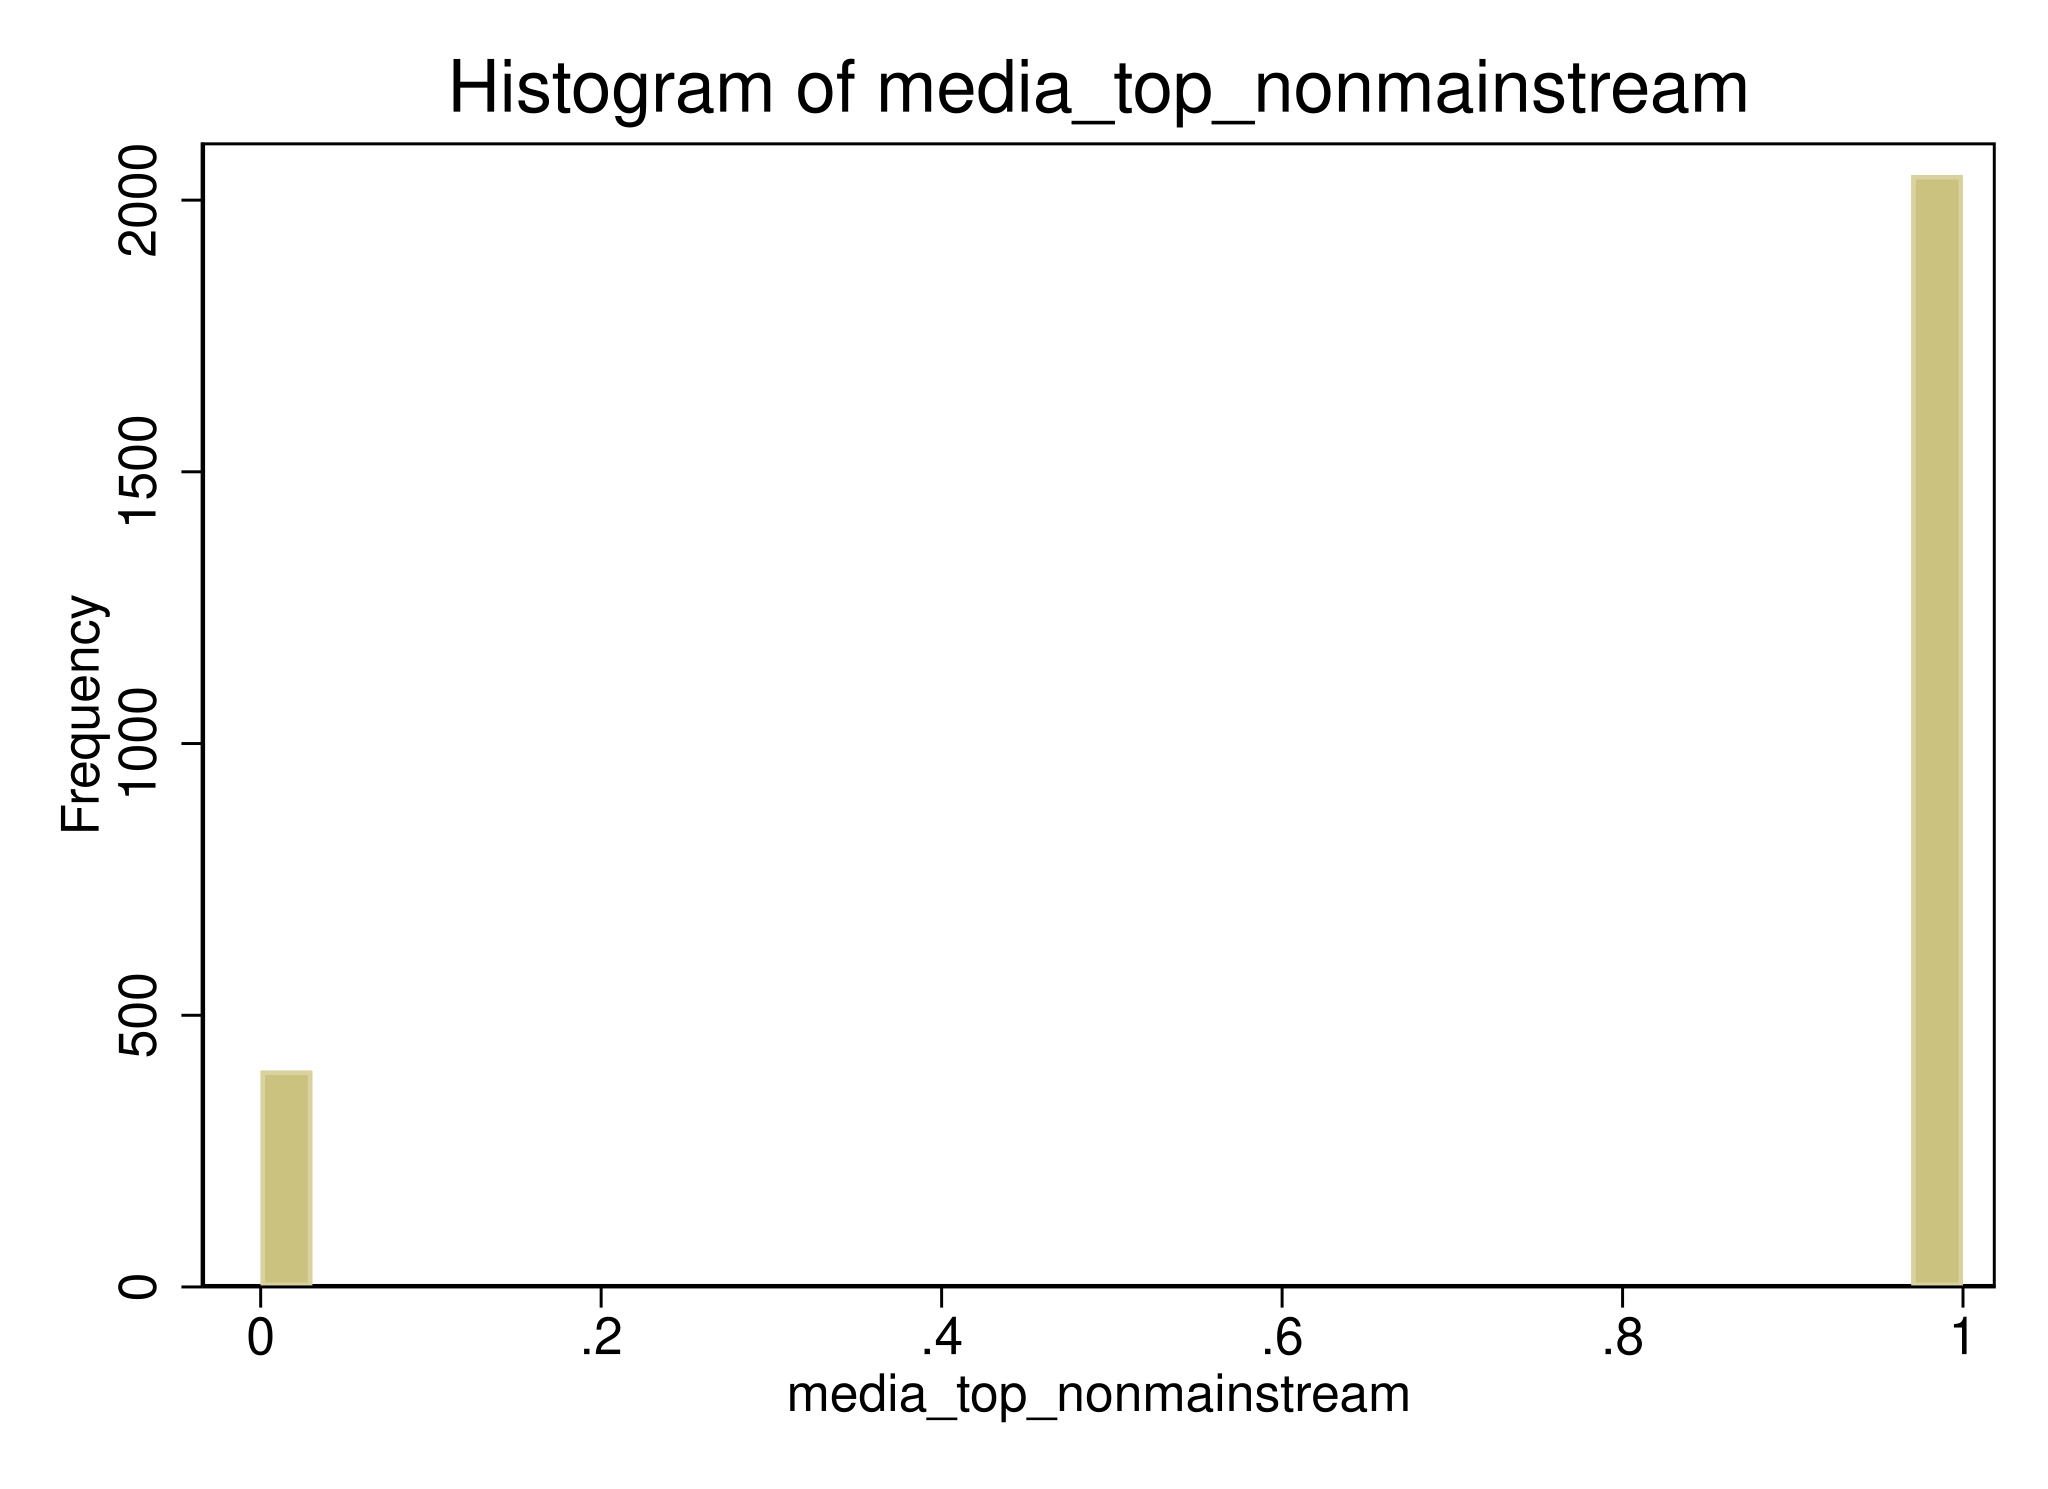

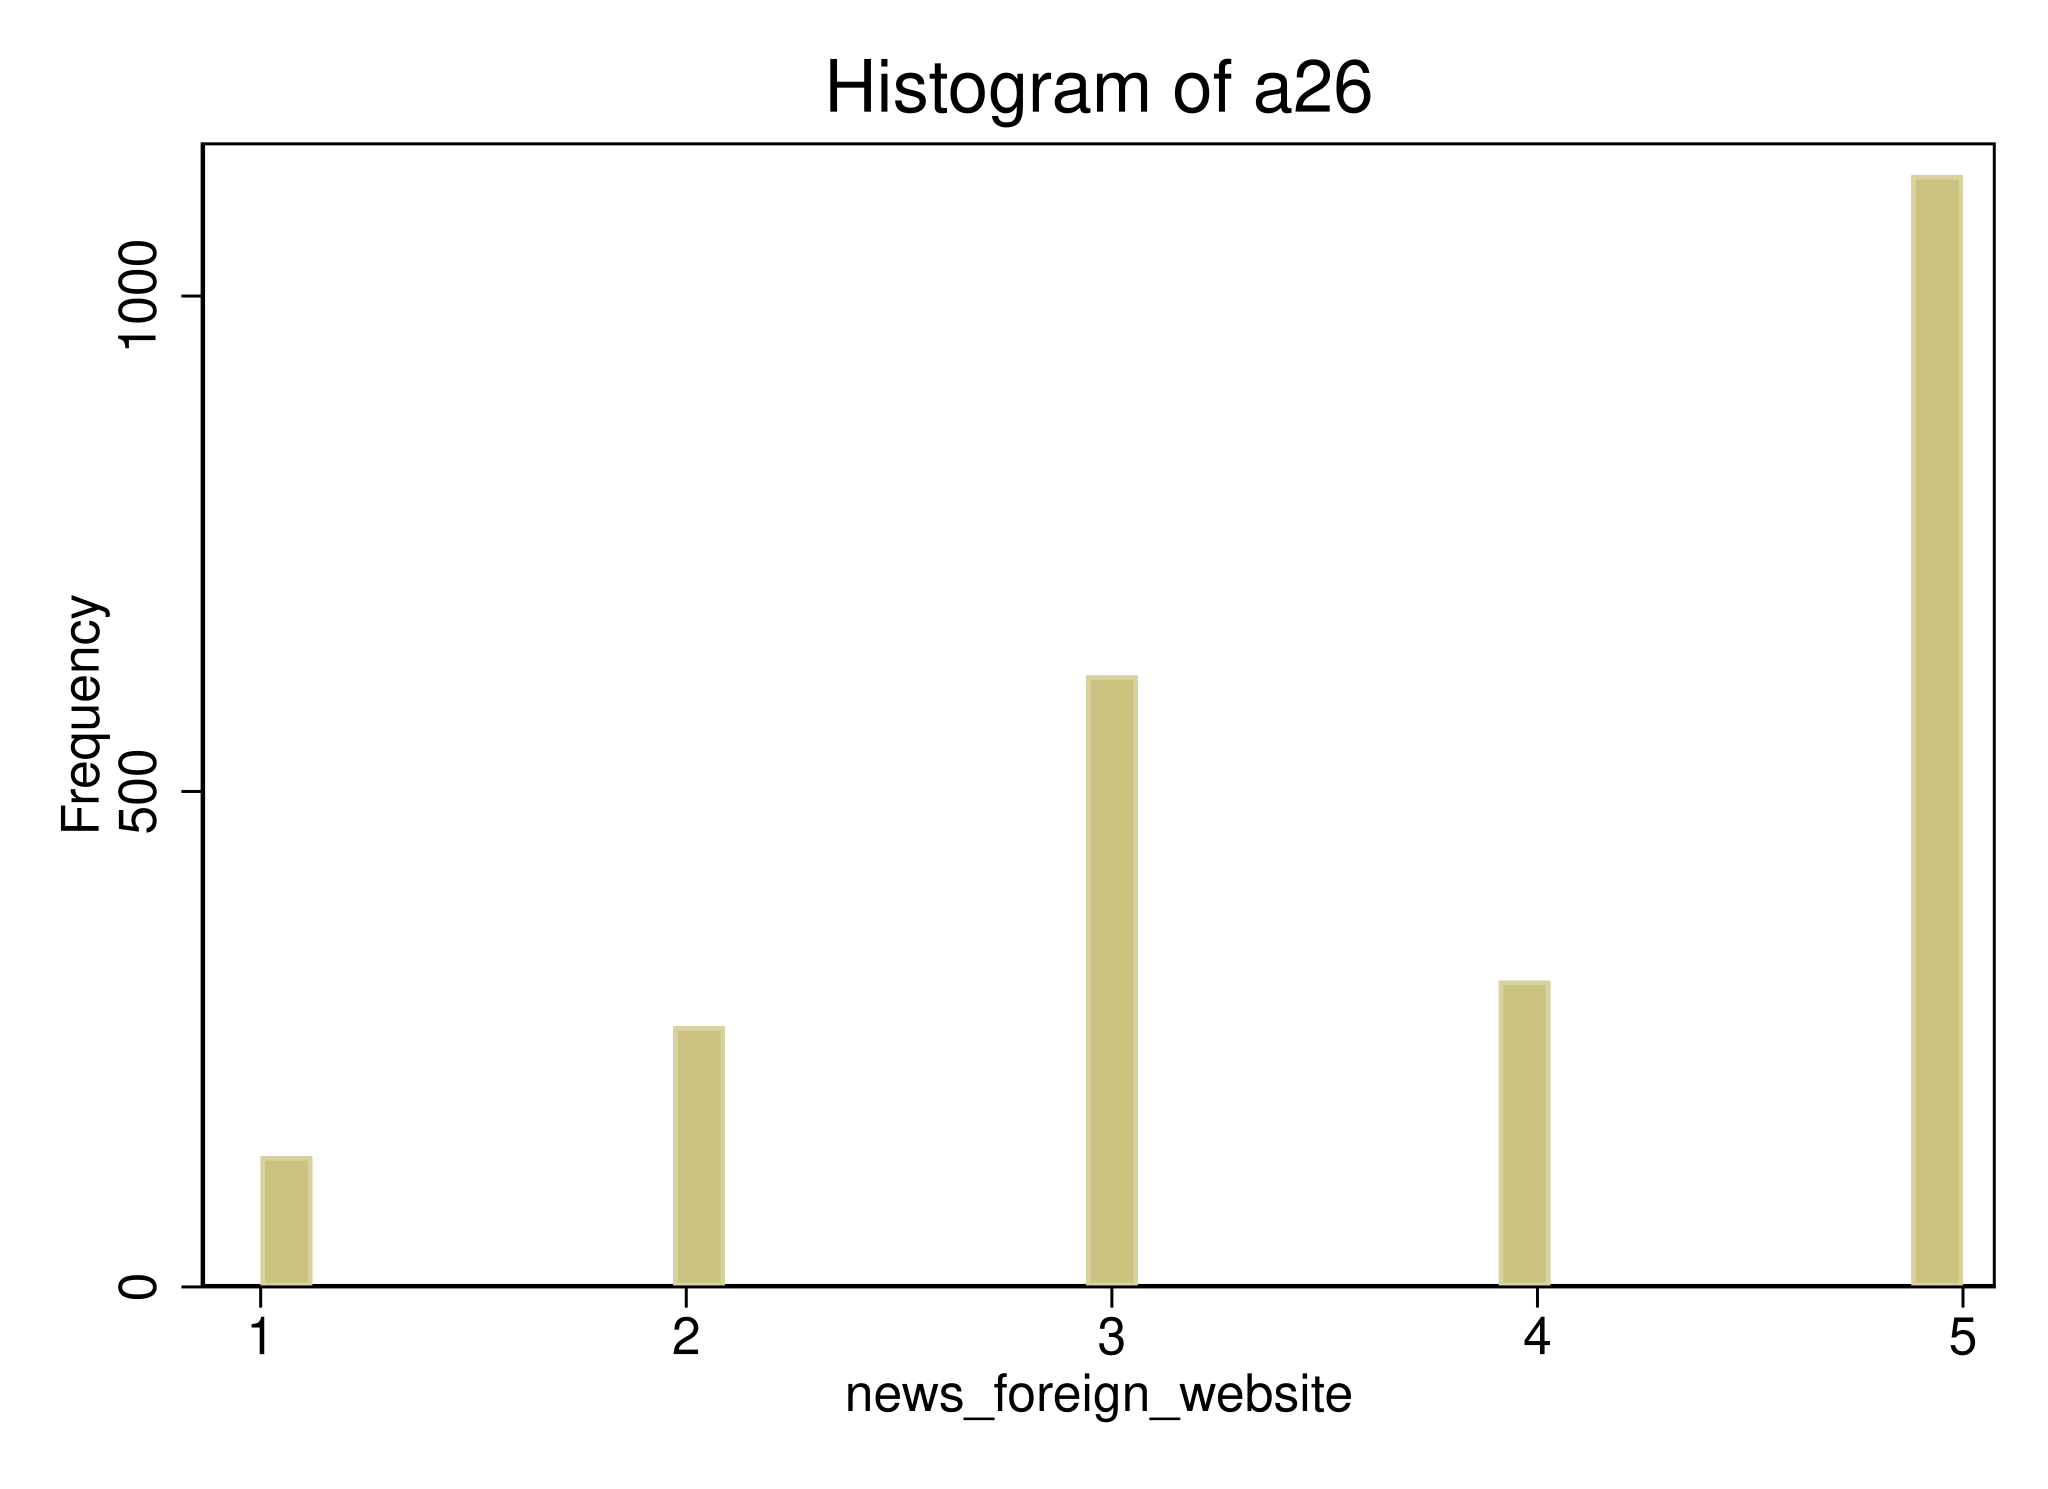

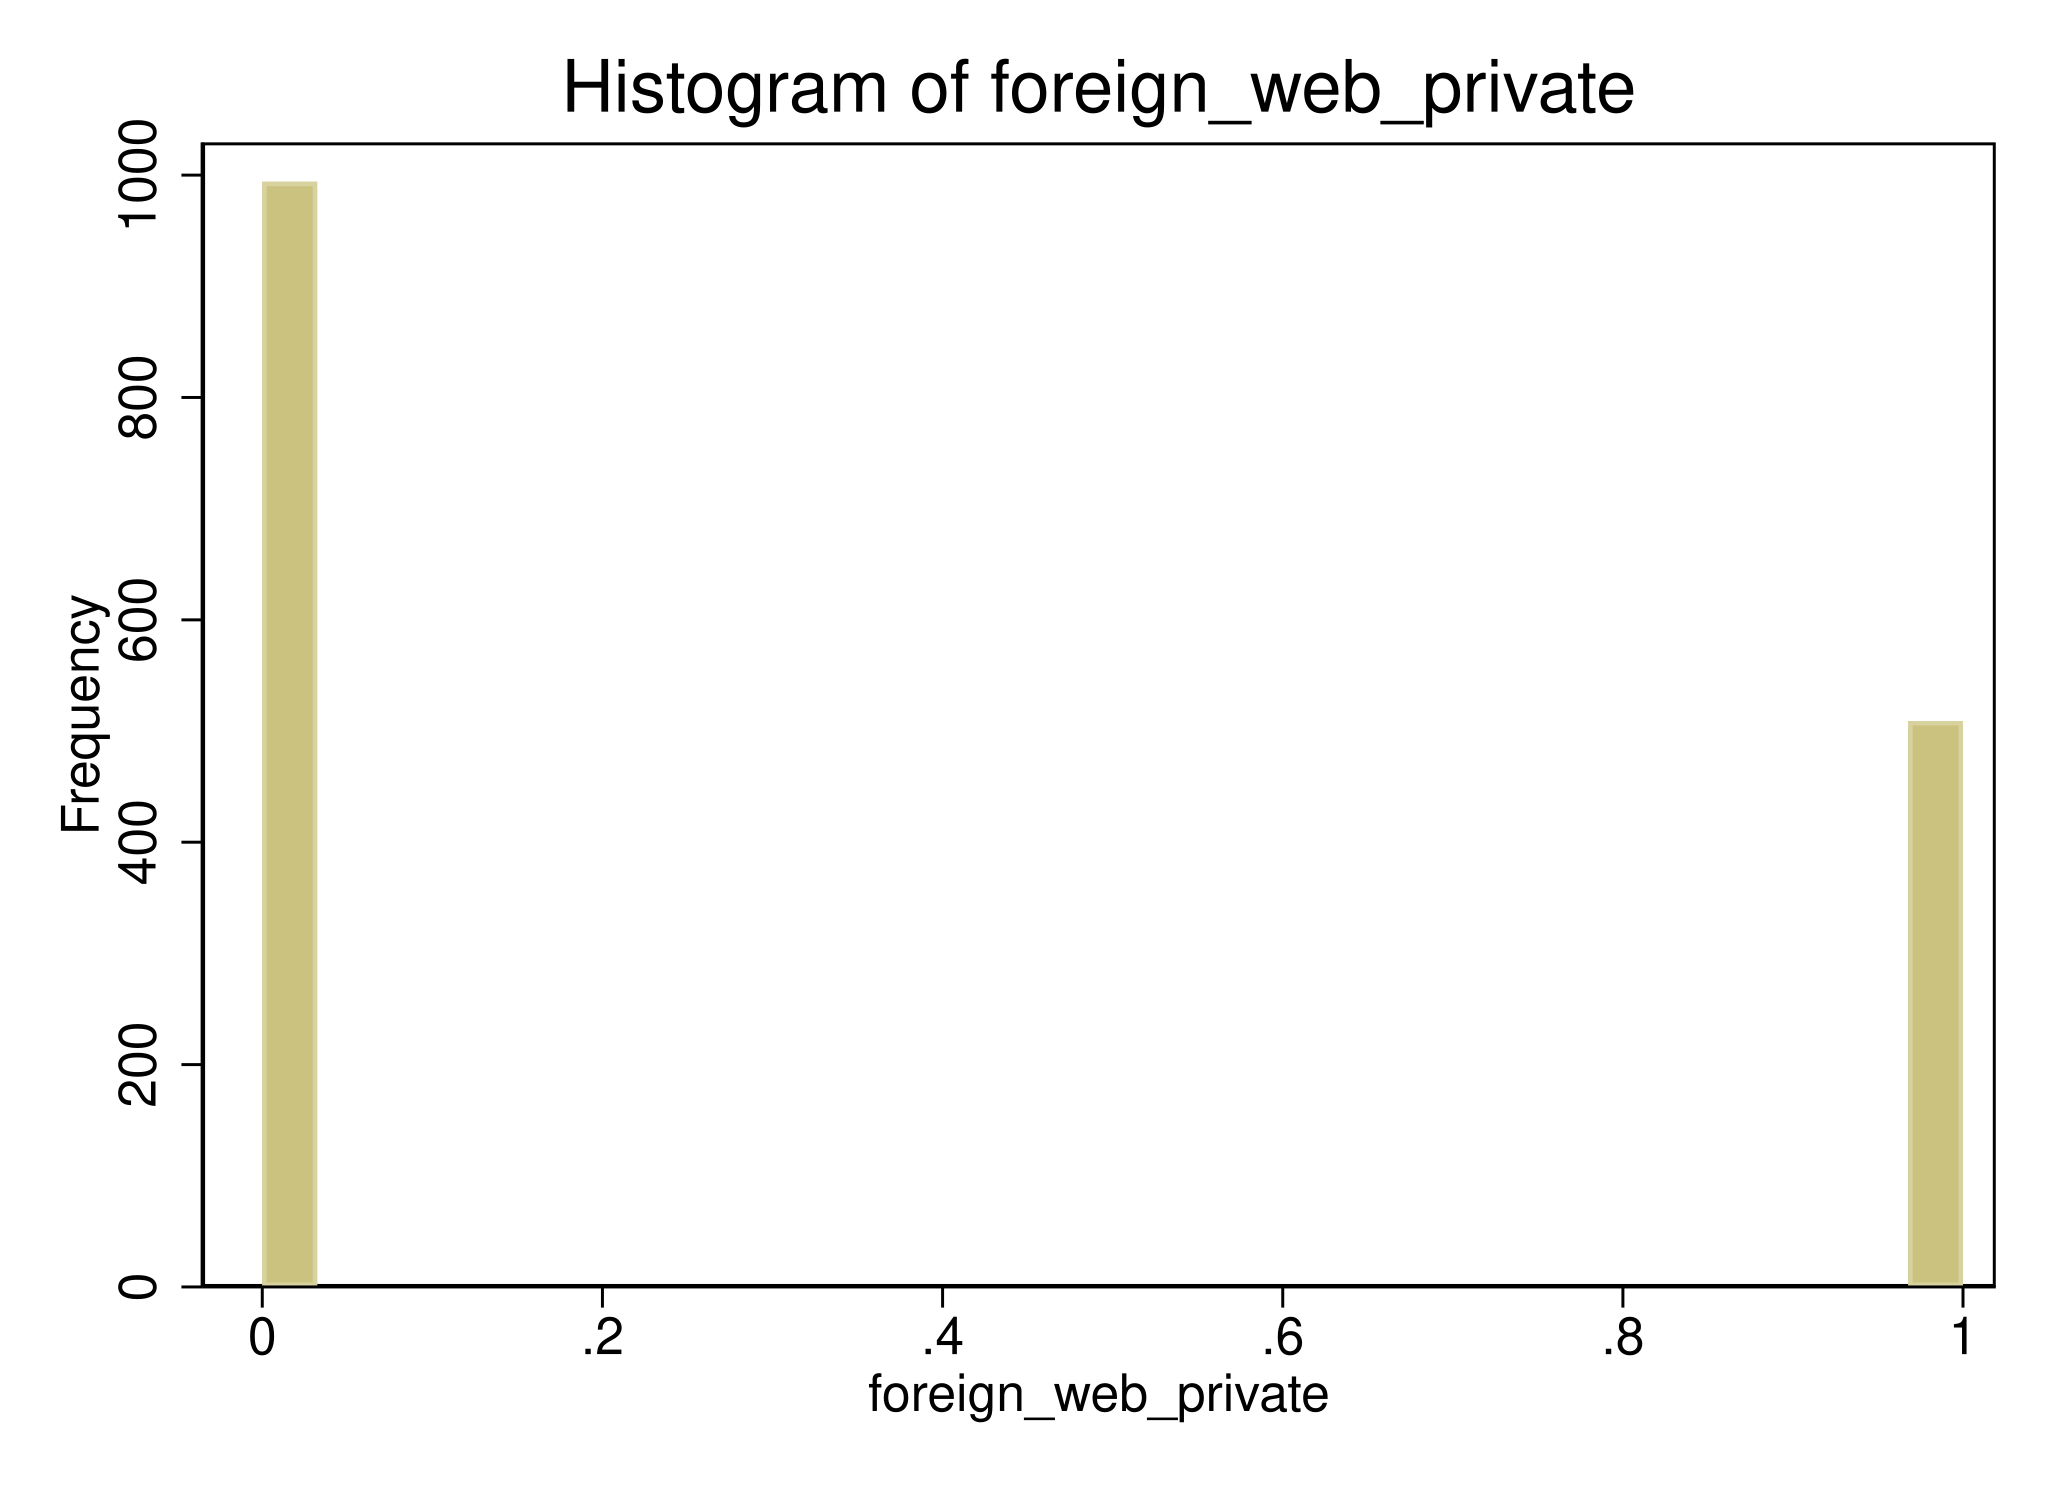

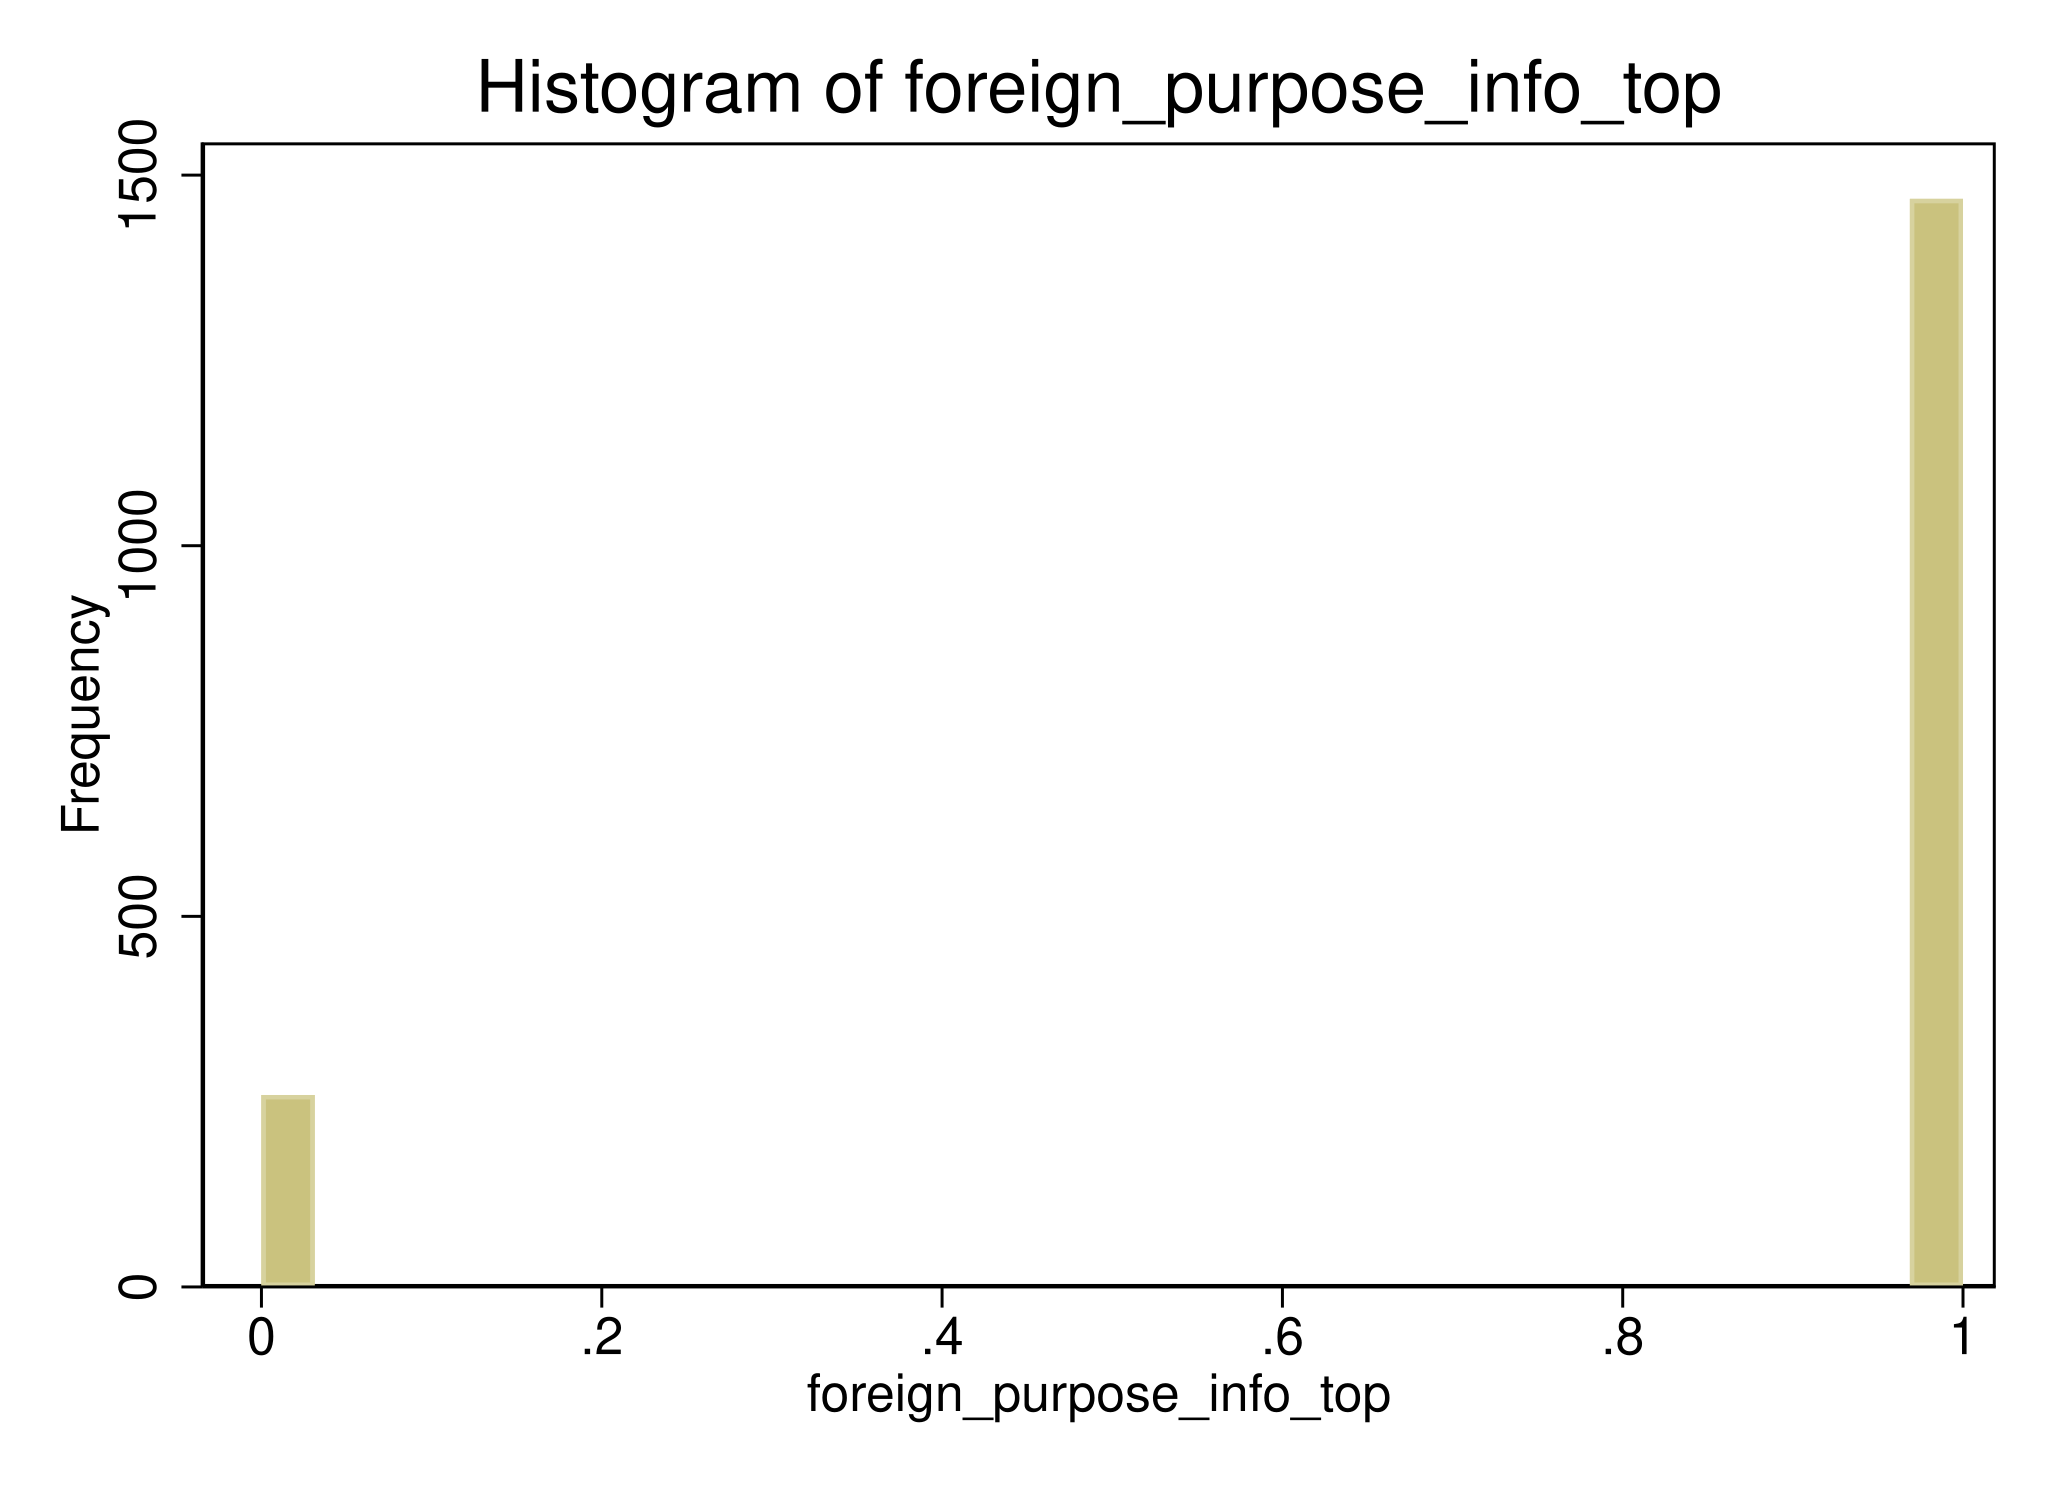

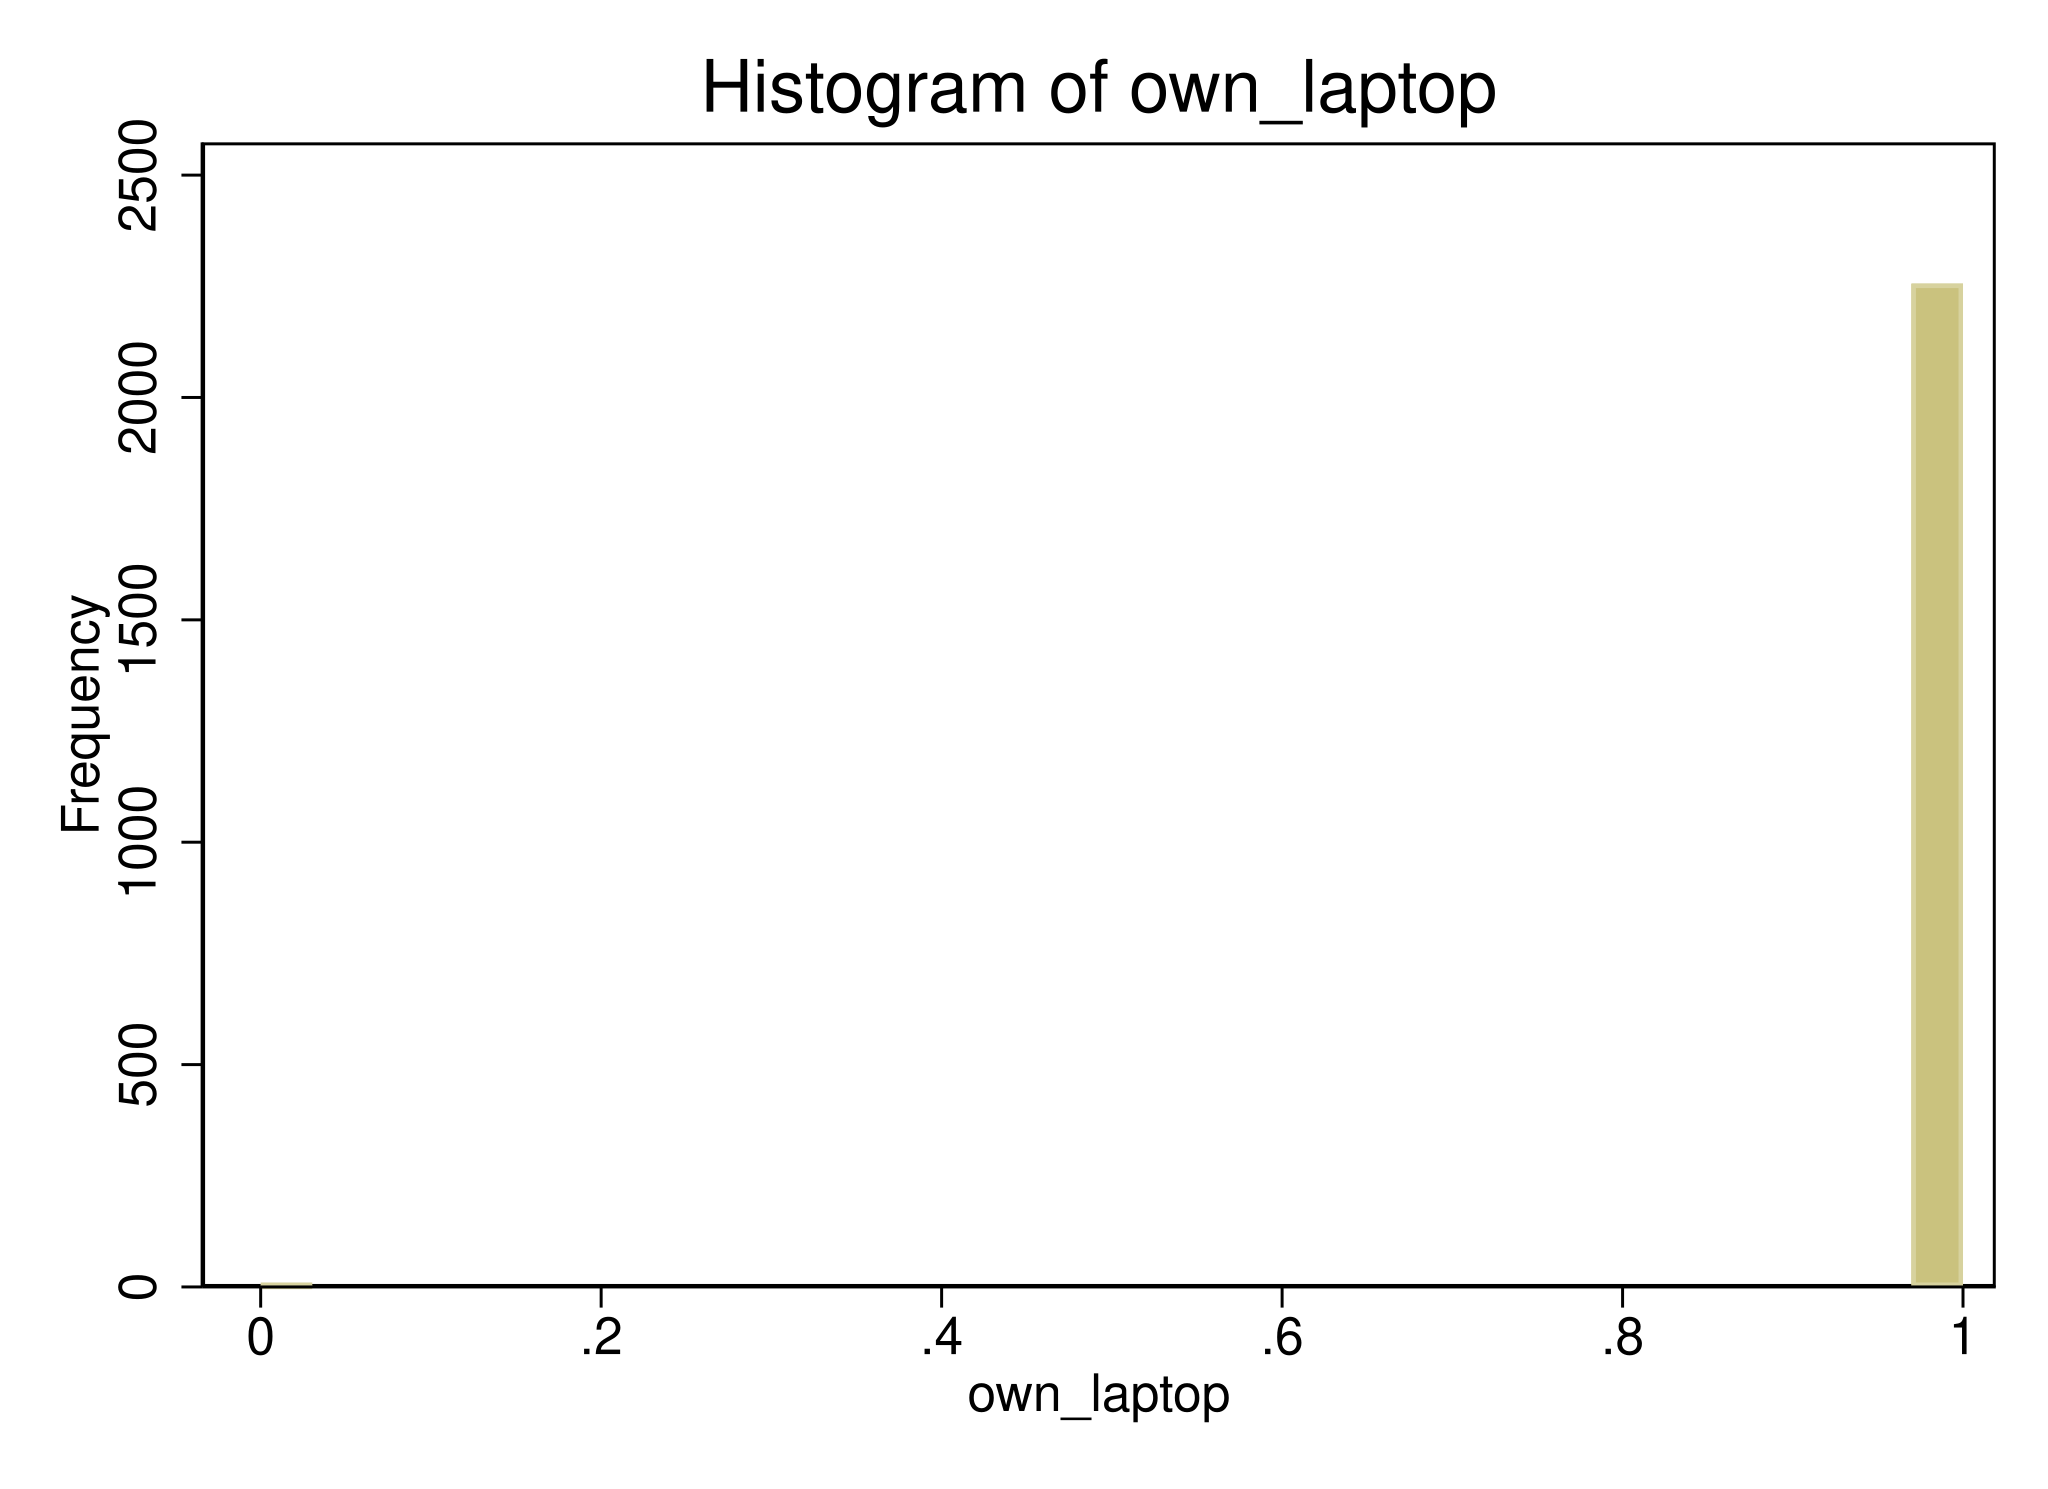

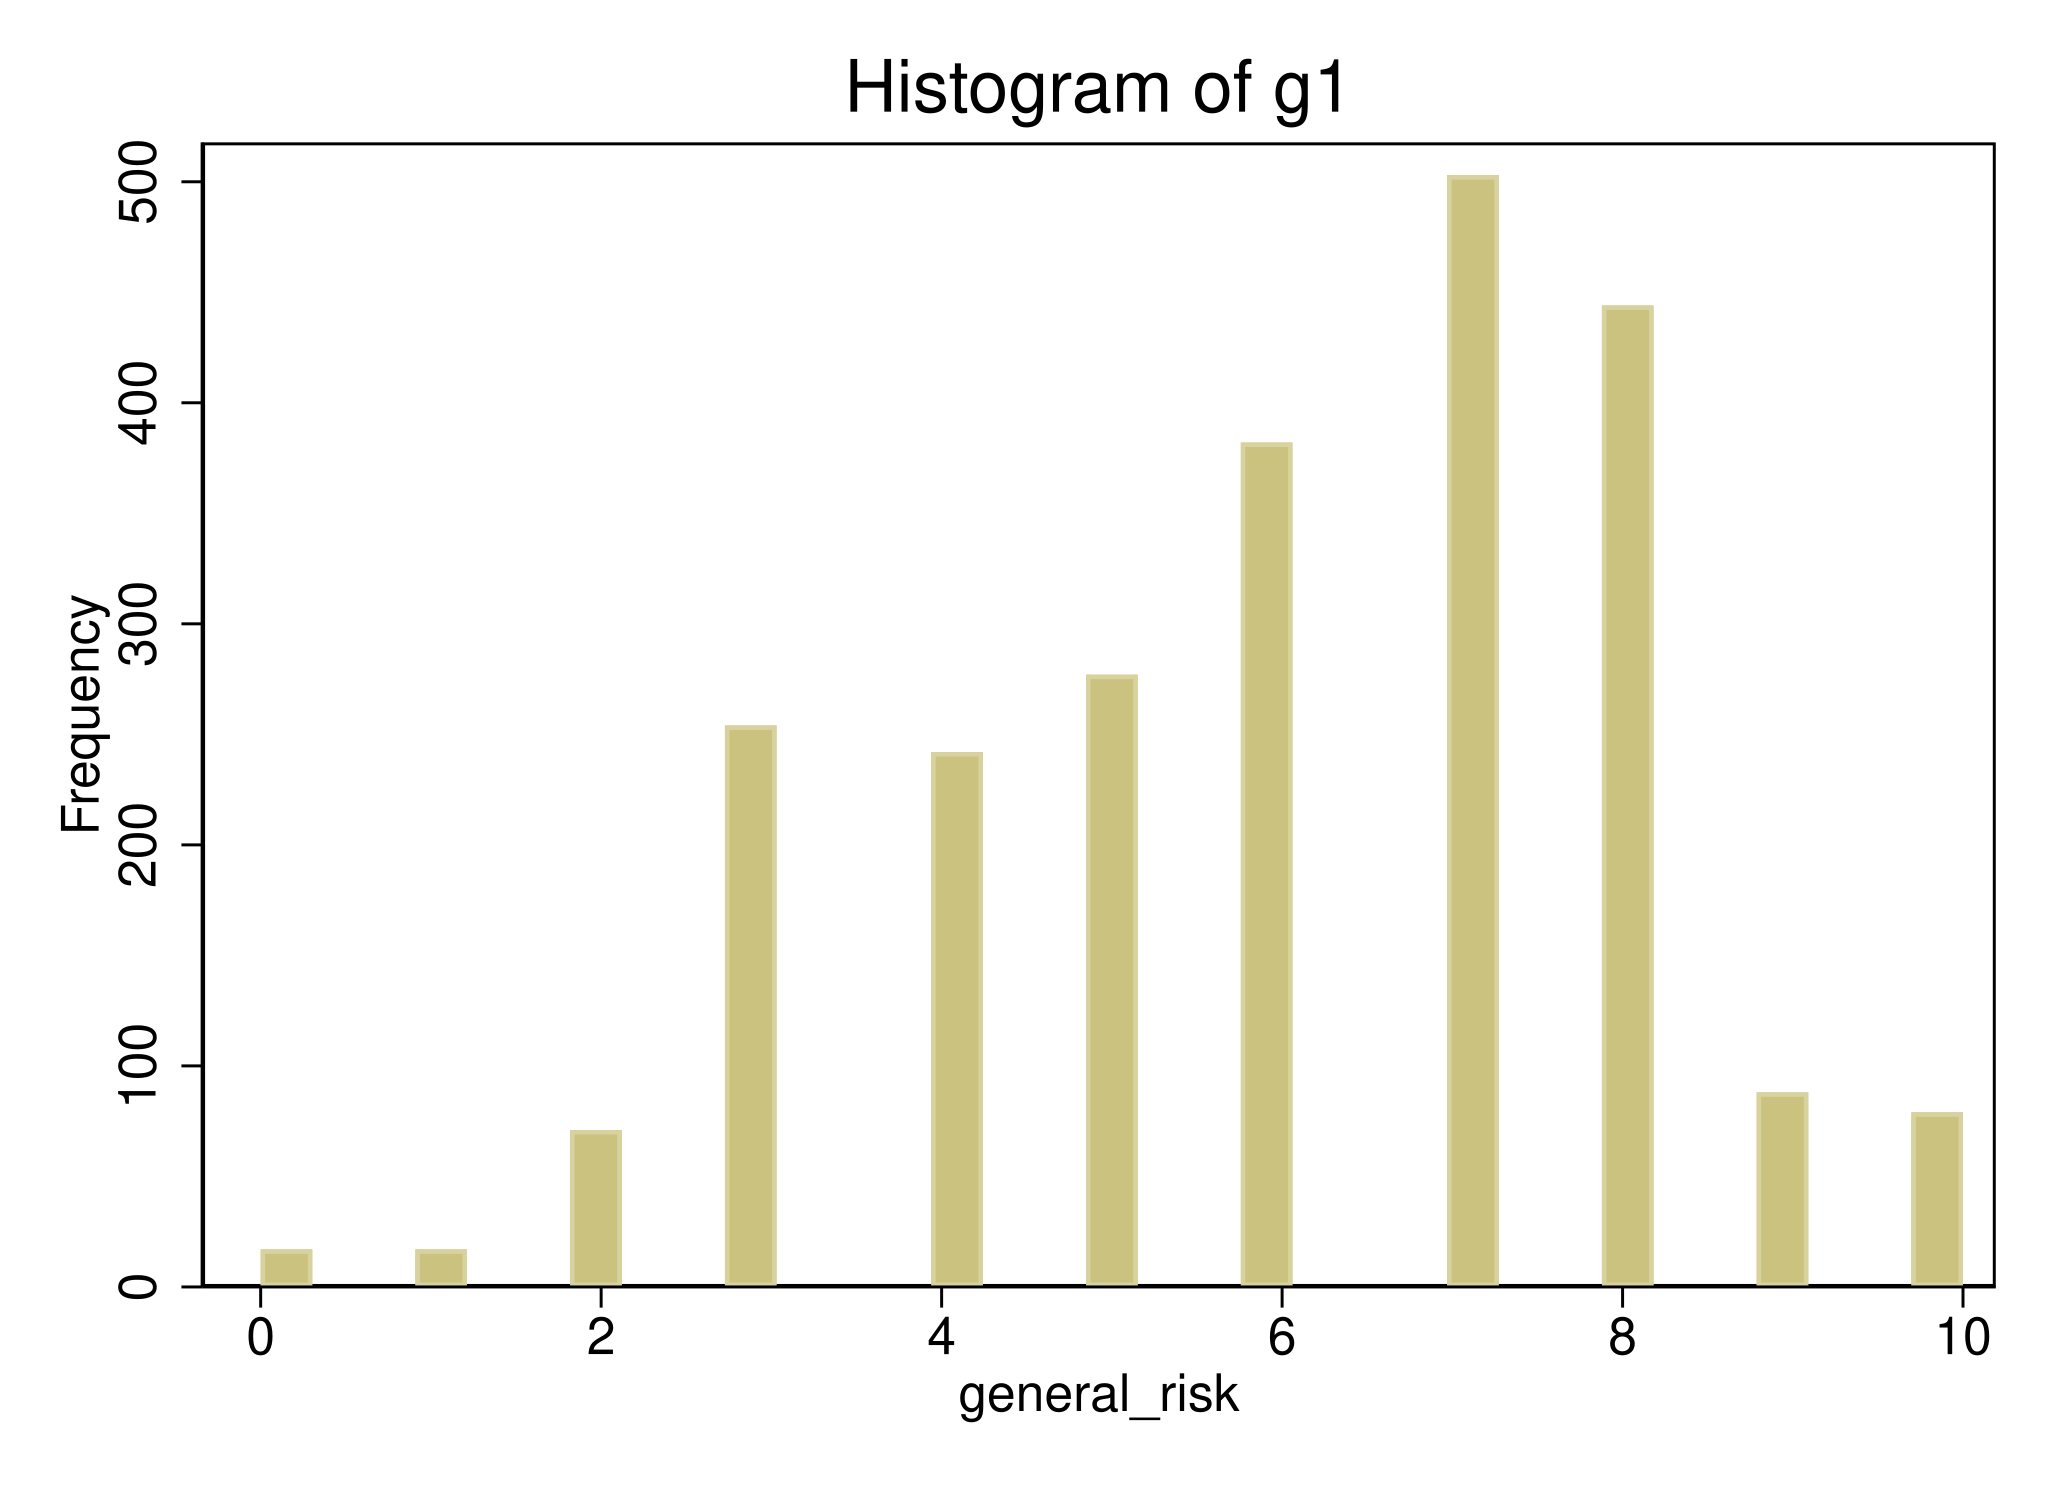

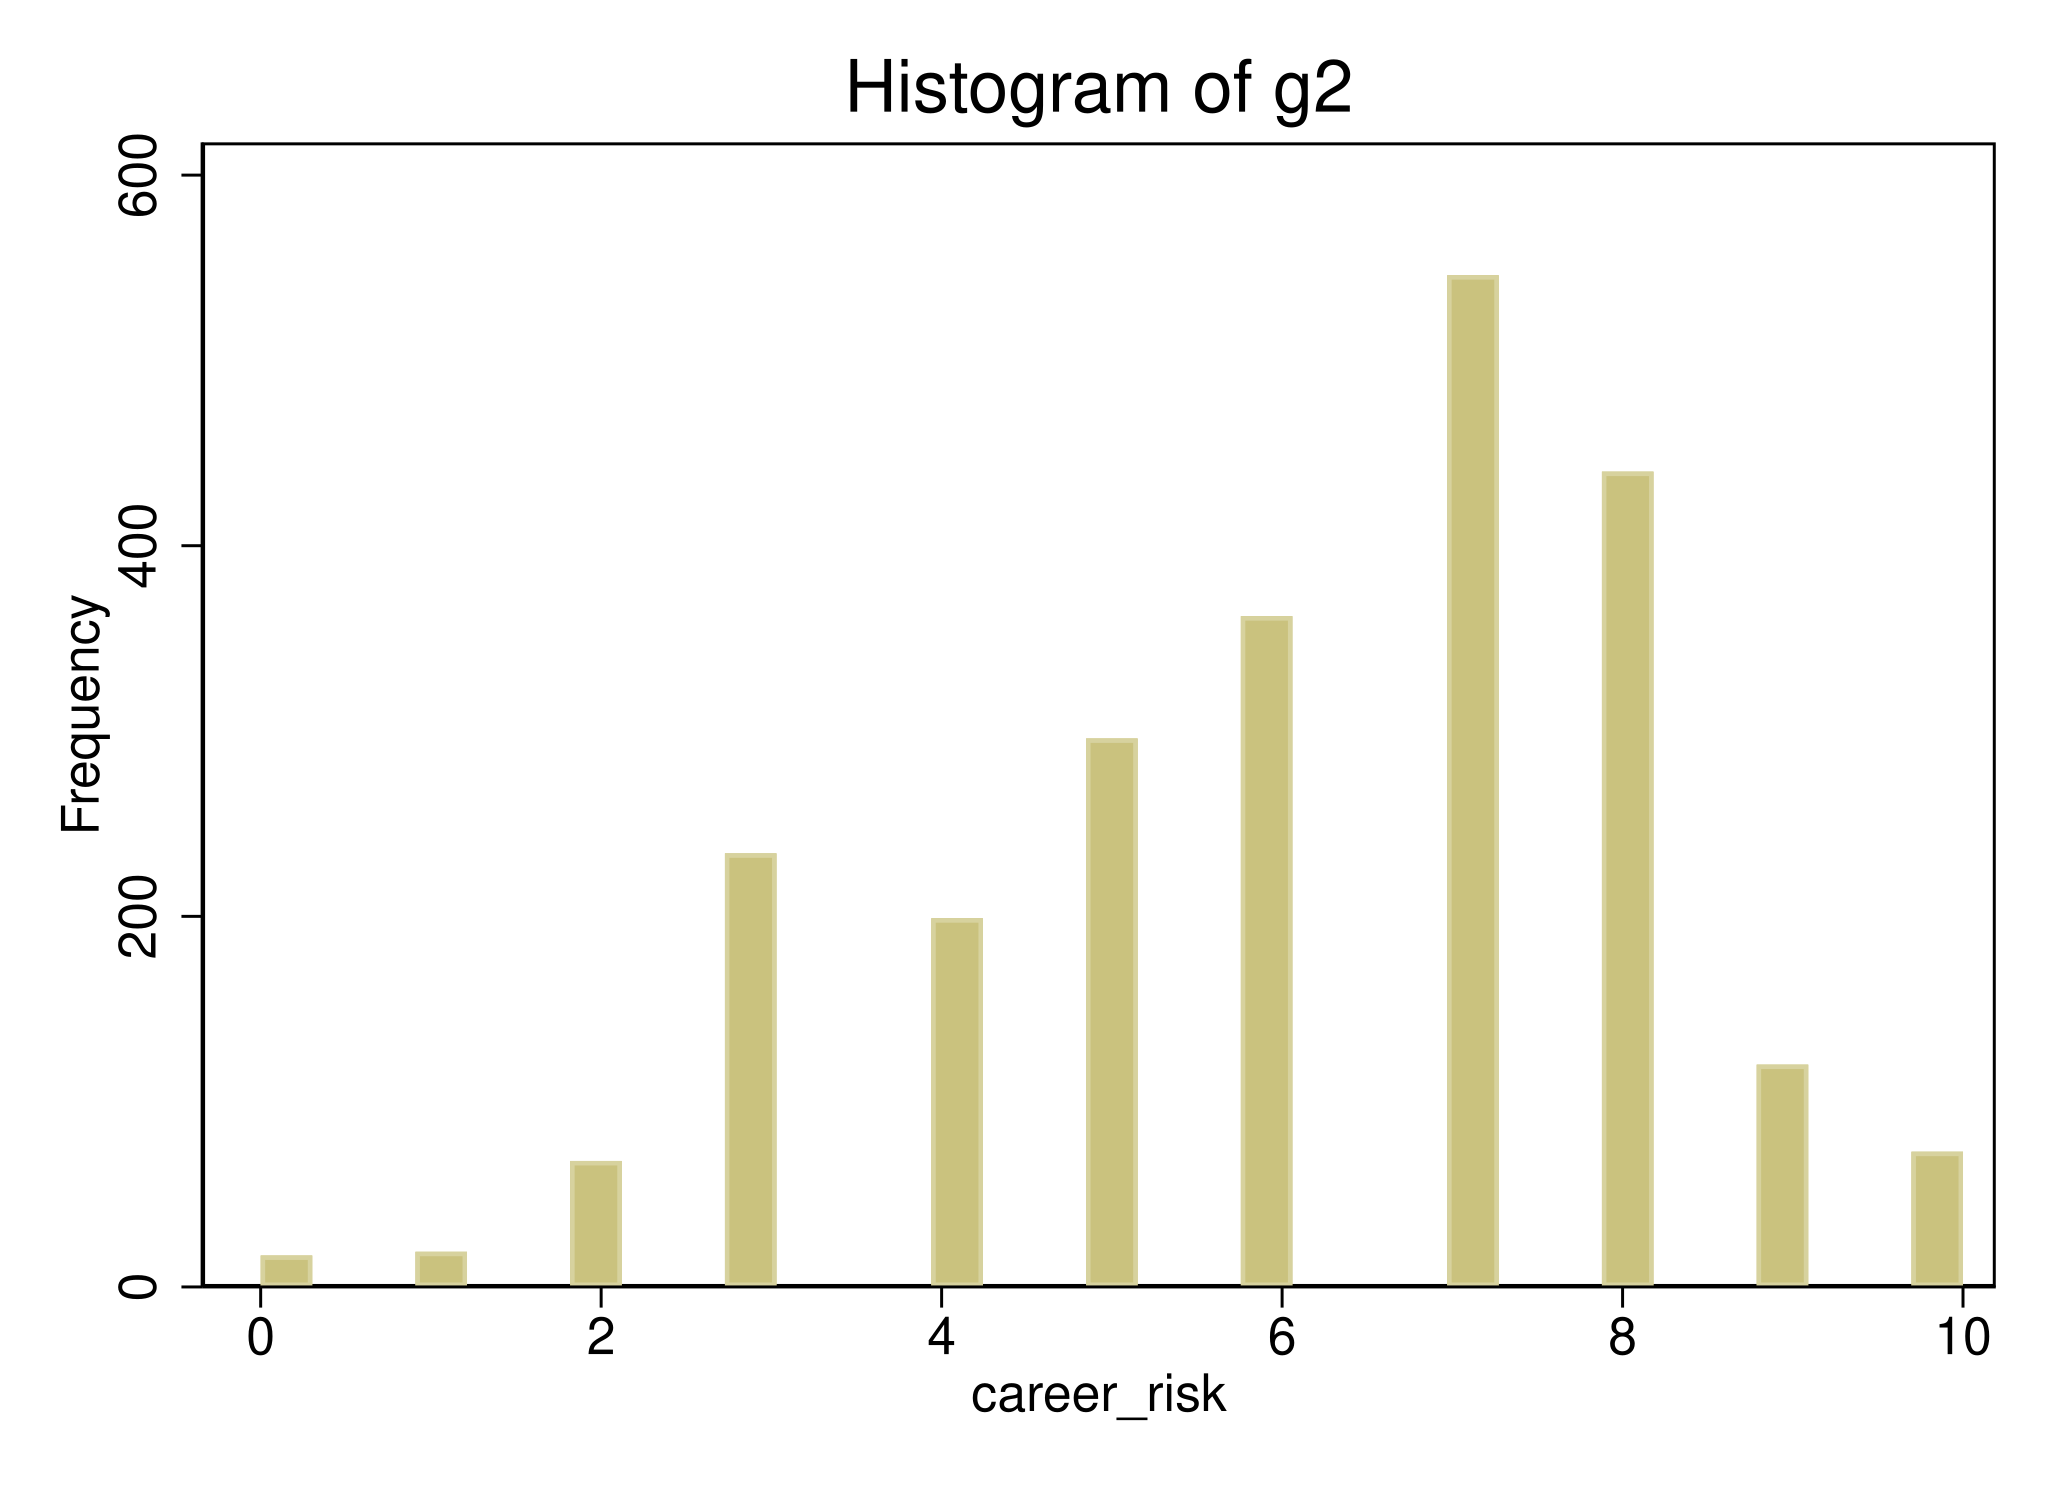

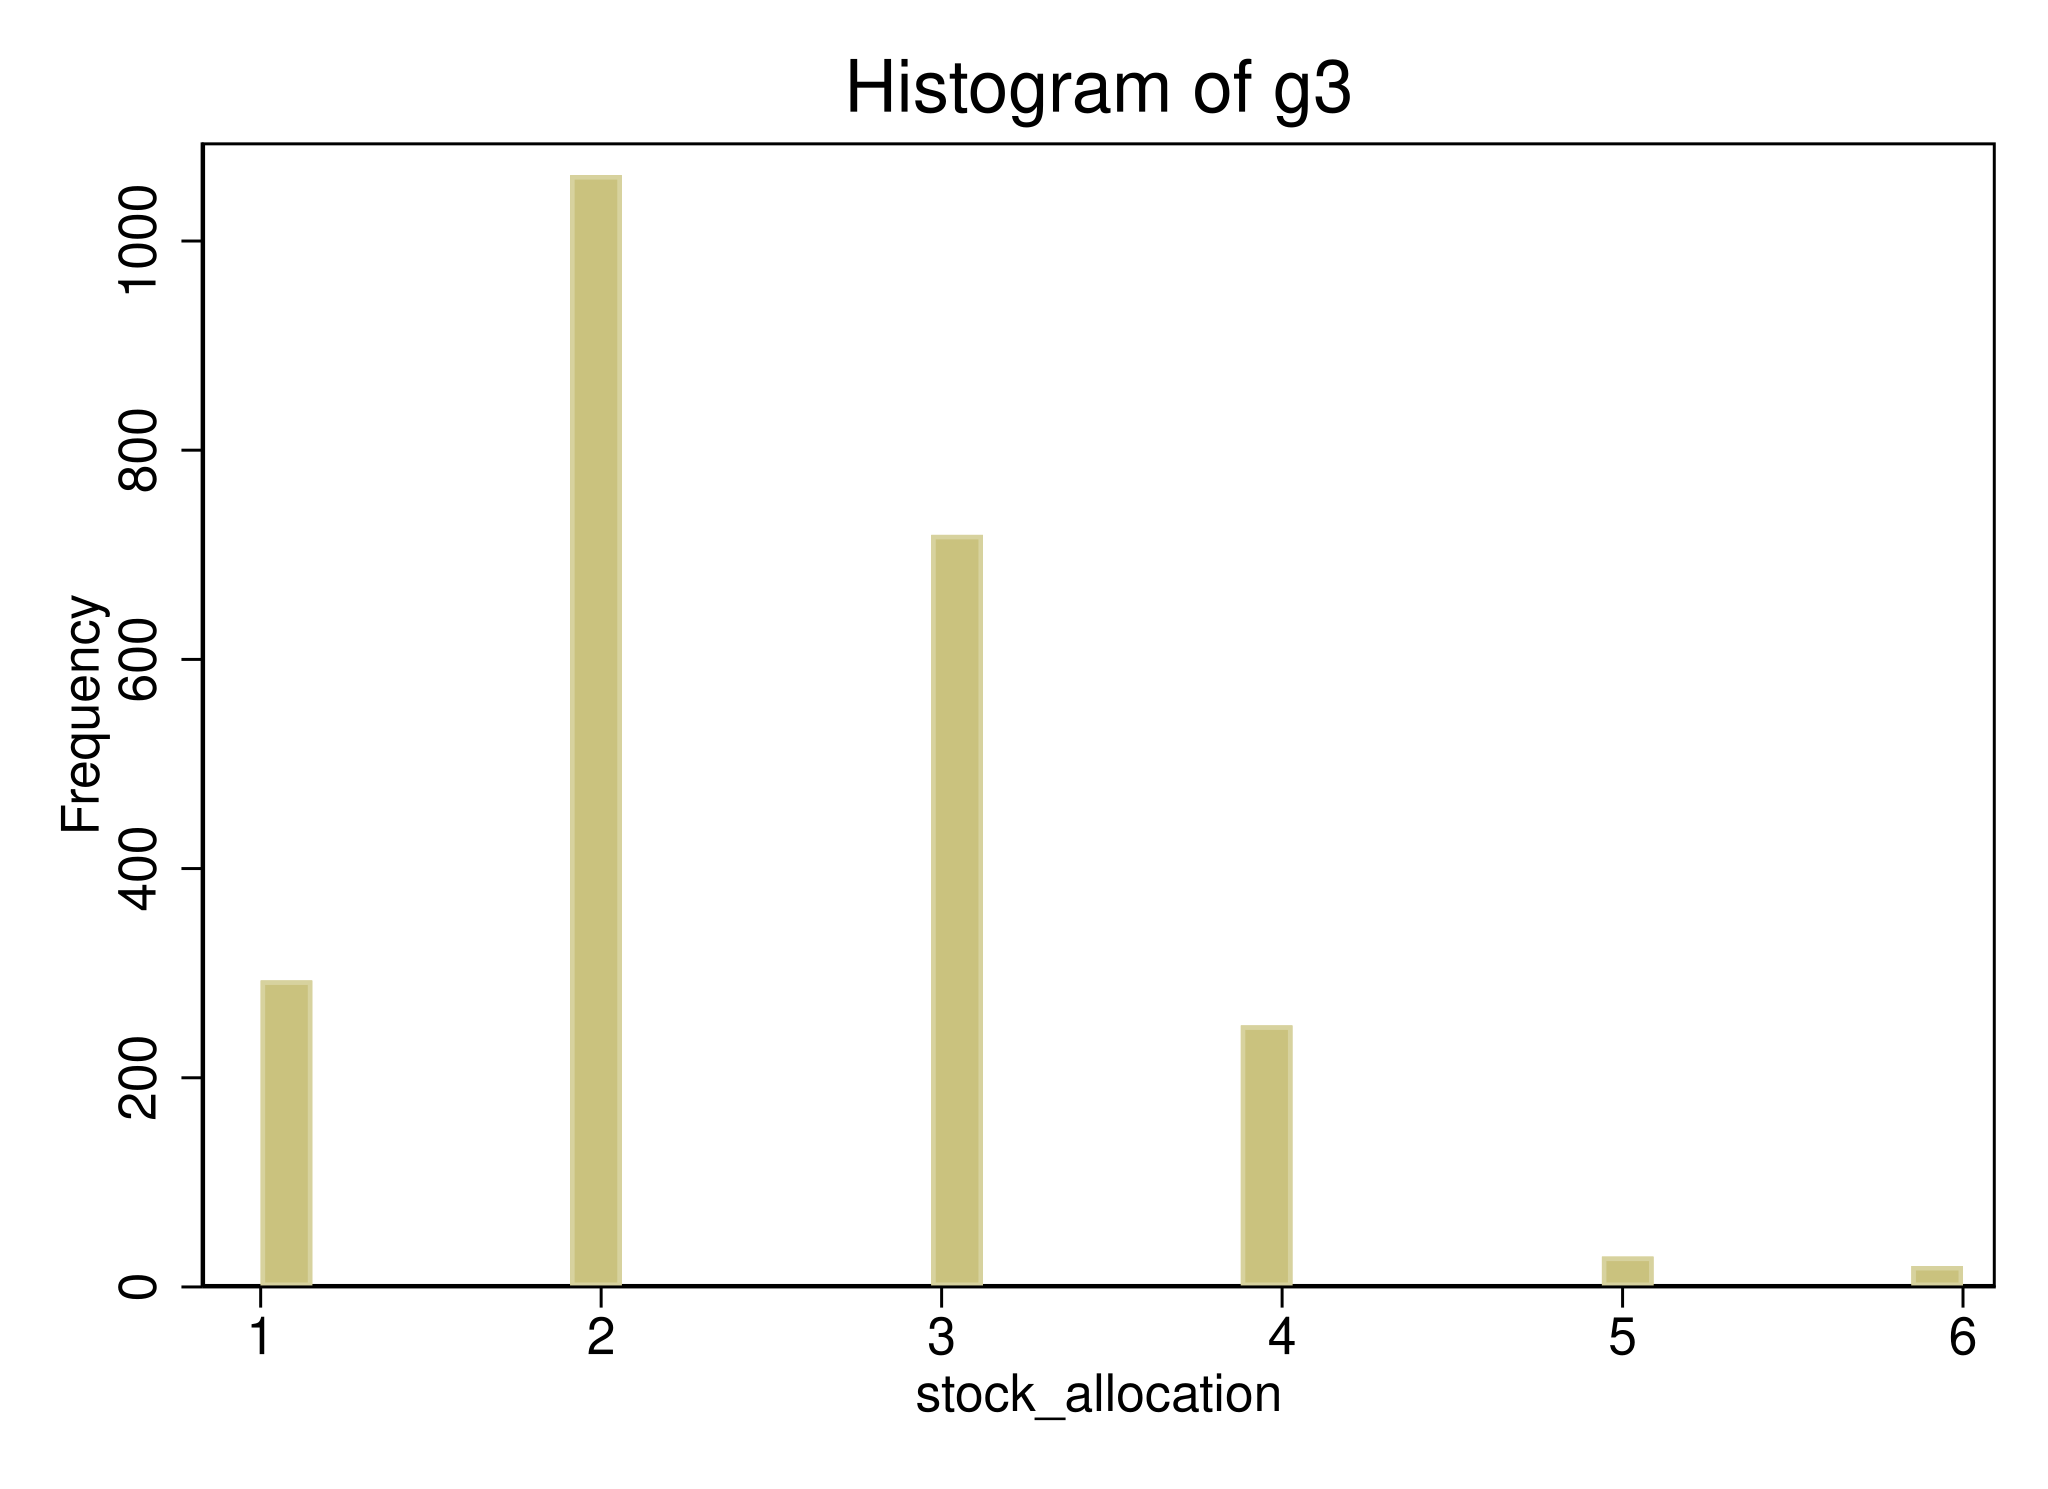

In [28]:
%%stata
quiet{
    // 设置图形格式
    set scheme s1color
    
    // 1. 媒体相关变量的直方图
    foreach var in `varset_media' {
        histogram `var', frequency title("Histogram of `var'") name(hist_`var', replace)
        graph export "hist_`var'.png", replace
    }
    
    // 2. 风险偏好变量的直方图
    foreach var in `varset_riskpreference' {
        histogram `var', frequency title("Histogram of `var'") name(hist_`var', replace)
        graph export "hist_`var'.png", replace
    }
}

## Figure 2


. quiet{

. 


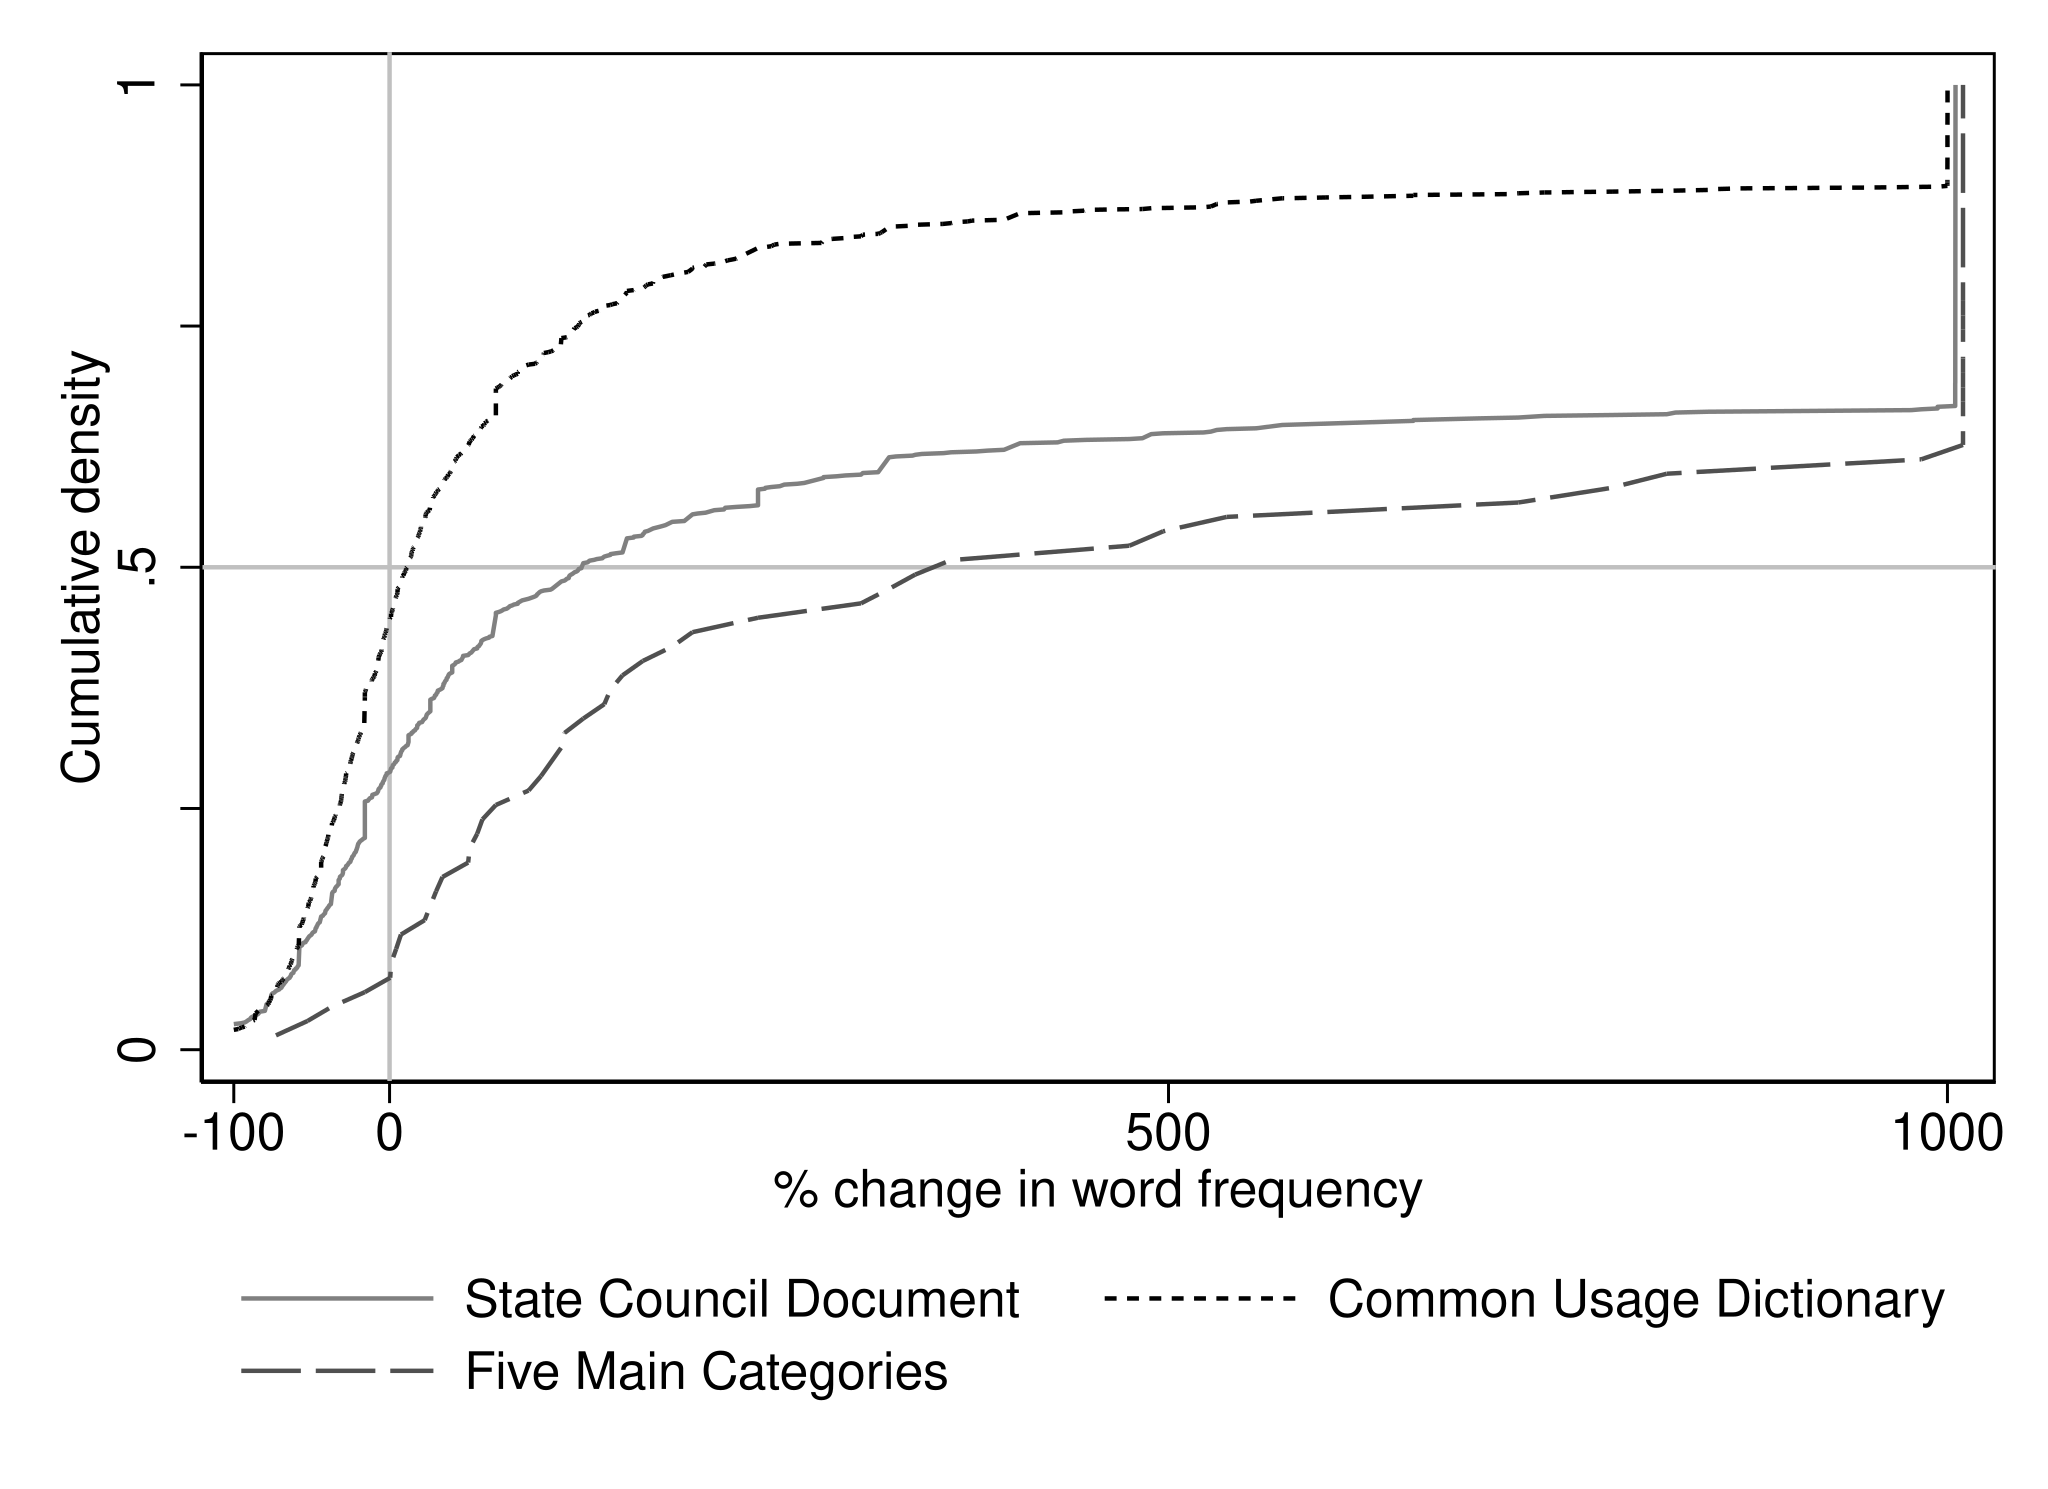

In [11]:
%%stata
quiet{
    preserve
    
    use "`directory_path'/curriculum_ideology_jpe_wordcount.dta", clear
    
    gen change_govtdoc = no_c_intensive 		if Govtdoc == 1
    gen change_dictionary = no_c_intensive 		if Dictionary == 1
    gen change_hypothesis = no_c_intensive 		if hypothesis == 1
    
    egen rank_govtdoc_above10 = rank(change_govtdoc) if (change_govtdoc > 10 & change_govtdoc != .)
    egen rank_dictionary_above10 = rank(change_dictionary) if (change_dictionary > 10 & change_dictionary != .)
    egen rank_hypothesis_above10 = rank(change_hypothesis) if (change_hypothesis > 10 & change_hypothesis != .)
    
    replace change_dictionary = 10 + rank_dictionary_above10/100000 if (change_dictionary > 10 & change_dictionary != .)
    replace change_govtdoc = 10.05 + rank_govtdoc_above10/100000 if (change_govtdoc > 10 & change_govtdoc != .)
    replace change_hypothesis = 10.1 + rank_hypothesis_above10/100000 if (change_hypothesis > 10 & change_hypothesis != .)
    
    replace change_dictionary = change_dictionary * 100
    replace change_govtdoc = change_govtdoc * 100
    replace change_hypothesis = change_hypothesis * 100
    
    cumul change_govtdoc, gen(c_change_govtdoc) equal
    cumul change_dictionary, gen(c_change_dictionary) equal
    cumul change_hypothesis, gen(c_change_hypothesis) equal
    
    twoway line c_change_govtdoc change_govtdoc, lp(solid) lc(gs8) sort || ///
           line c_change_dictionary change_dictionary, lp(shortdash) lc(black) sort || ///
           line c_change_hypothesis change_hypothesis, lp(longdash) lc(gs5) sort ||, ///
           xtitle("% change in word frequency") ///
           ytitle("Cumulative density") ///
           legend(label(1 "State Council Document") label(2 "Common Usage Dictionary") label(3 "Five Main Categories")  region(lstyle(none))) ///
           scheme(s1mono) xlabel(-100 0 500 1000) ylabel(0(0.5)1) ytick(0.25 0.75) ///
           xline(0, lc(gs12)) yline(0.5, lc(gs12))
           *graphregion(fcolor(white) ilcolor(white) lcolor(white))
            
    graph export "figure_2.pdf", replace
    
    restore
}

## Figure 3


. 
. *** Figure 3
. 
. quietly {

. 


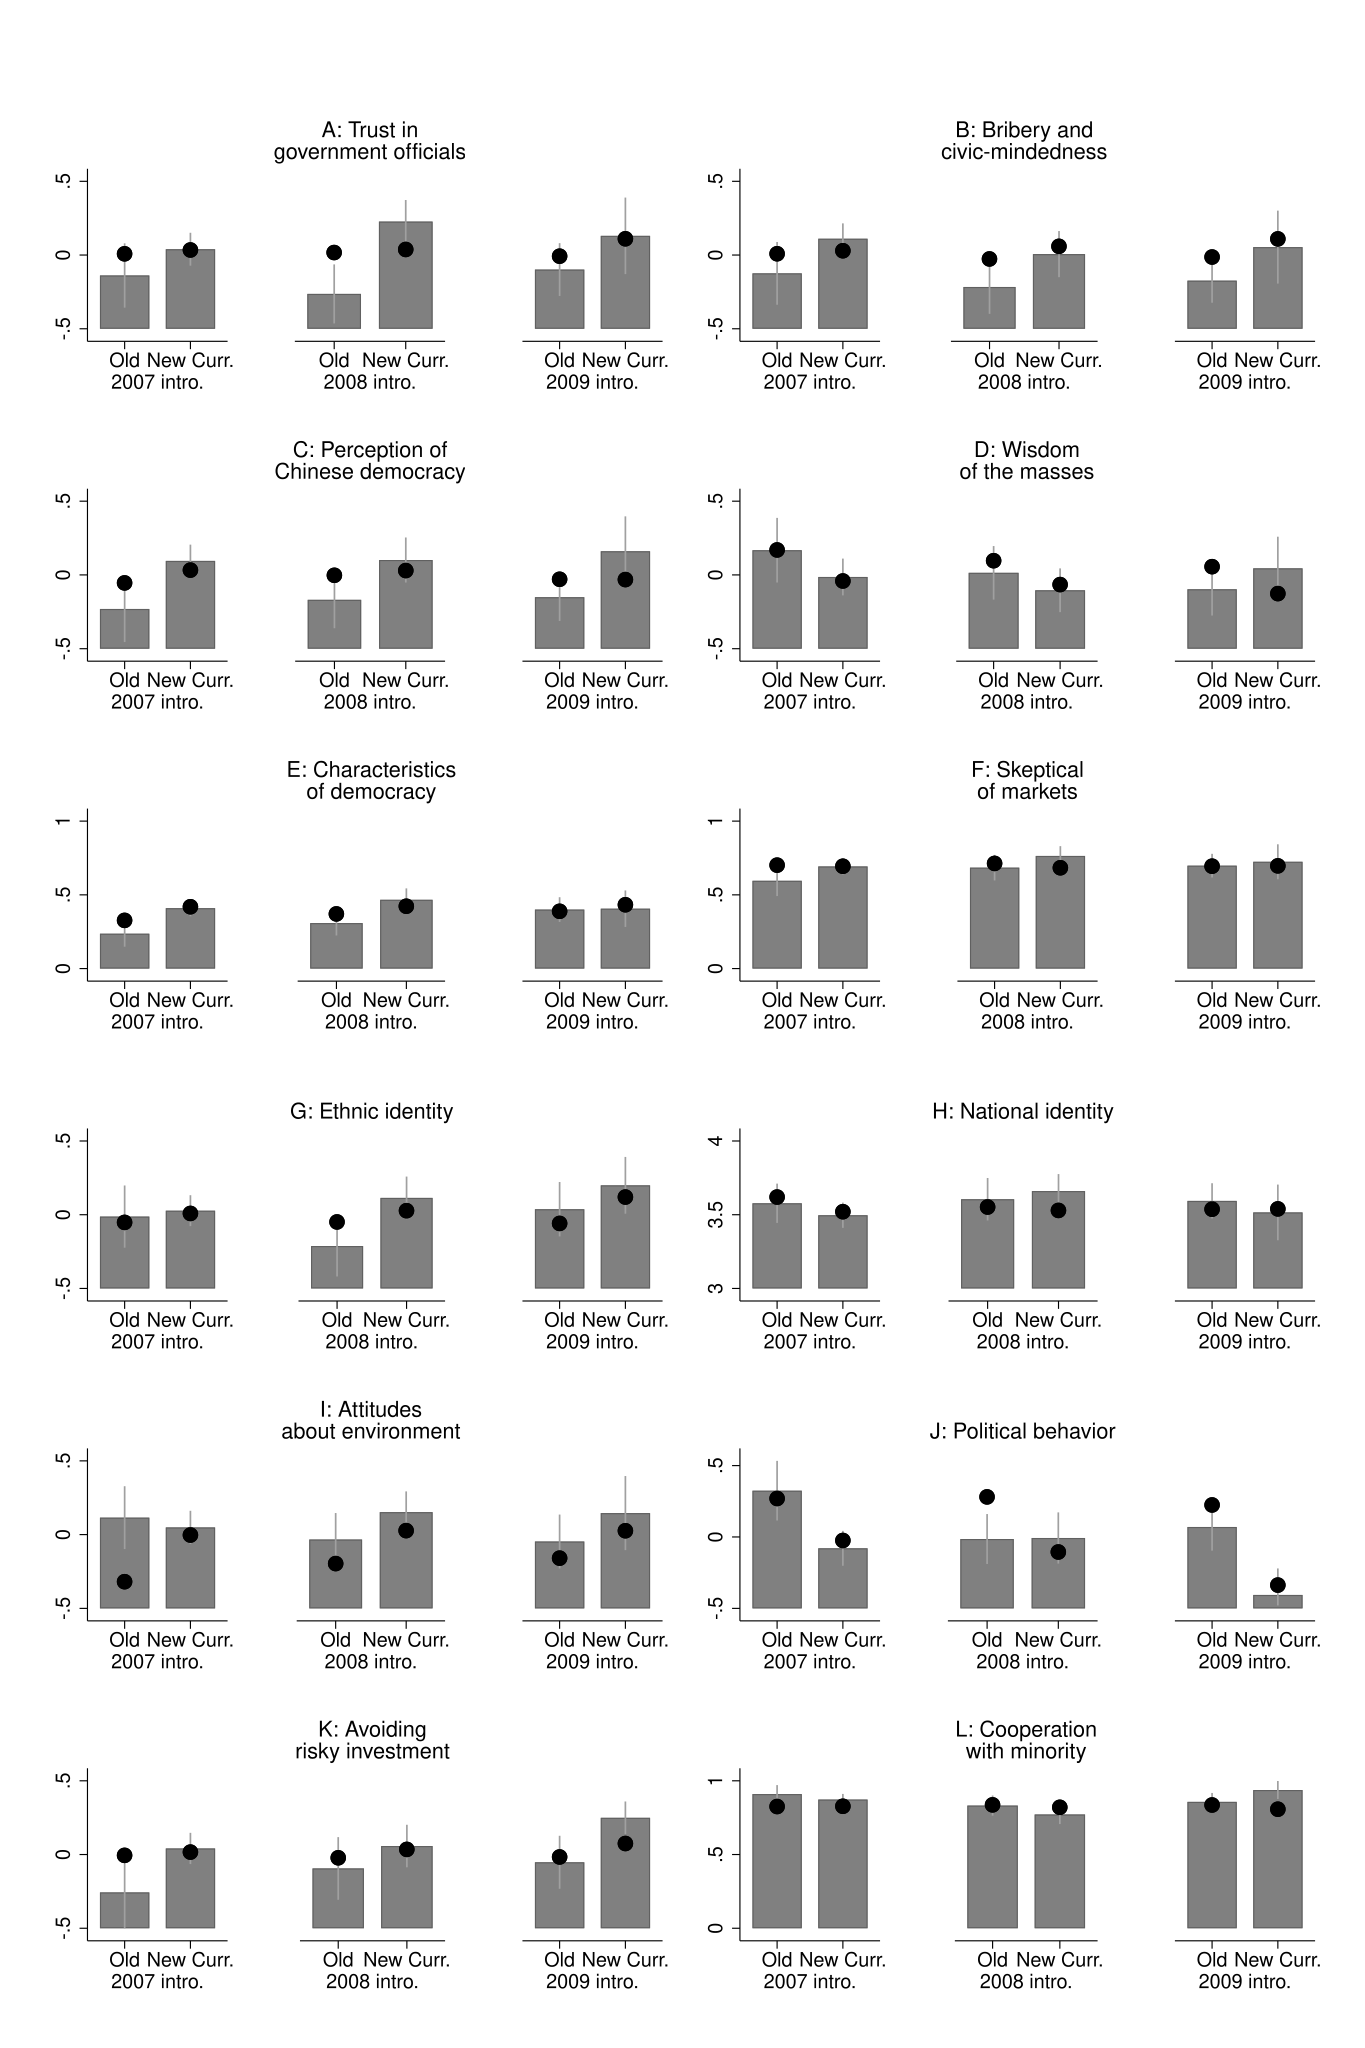

In [12]:
%%stata

*** Figure 3

quietly {
    preserve
	
	gen introstatus=.
	replace introstatus=0 if introyear==2007 &  curryear==-1
	replace introstatus=1 if introyear==2007 & (curryear==0 | curryear==1 | curryear==2)
	replace introstatus=0 if introyear==2008 & (curryear==-1 | curryear==-2)
	replace introstatus=1 if introyear==2008 & (curryear==0 | curryear==1)
	replace introstatus=0 if introyear==2009 & (curryear==-1 | curryear==-2 | curryear==-3)
	replace introstatus=1 if introyear==2009 &  curryear==0
	
	gen nochanger = 0
	replace nochanger = 1 if (province == "Anhui" | province == "Chongqing" | province == "Fujian" ///
							| province == "Gansu" | province == "Guangdong" | province == "Guangxi" ///
							| province == "Guizhou" | province == "Hainan" | province == "Jiangsu" ///
							| province == "Liaoning" | province == "Ningxia" | province == "Qinghai" ///
							| province == "Shandong" | province == "Sichuan" | province == "Tianjin" ///
							| province == "Tibet" | province == "Zhejiang") 
	
	
* 	means for nochanger provinces	
	foreach x of varlist `varset_all12' {
		gen `x'_nc = .		
		foreach y of numlist 2007(1)2009 {
			egen `x'_nc_`y'_0t = mean(`x') if nochanger == 1 & cohort < `y'
			egen `x'_nc_`y'_1t = mean(`x') if nochanger == 1 & cohort >= `y'
			egen `x'_nc_`y'_0 = mean(`x'_nc_`y'_0t) if cohort < `y'
			egen `x'_nc_`y'_1 = mean(`x'_nc_`y'_1t) if cohort >= `y'
			replace `x'_nc = `x'_nc_`y'_0 if introstatus == 0 & introyear == `y'
			replace `x'_nc = `x'_nc_`y'_1 if introstatus == 1 & introyear == `y'
			drop `x'_nc_`y'_*
			}
		}
	
							
	collapse (mean) `varset_all12' ///
		az_trust_govt_nc az_quality_govern_nc az_democracy_attitude_nc az_wisdom_masses_nc k214_top_nc k1_marketno_nc az_minority_nc o1_nc az_environment_nc az_poli_behavior_nc az_invest_risky_nc q9_nc ///
		(semean) se_1=az_trust_govt se_2=az_quality_govern se_3=az_democracy_attitude ///
		se_4=az_wisdom_masses se_5=k214_top se_6=k1_marketno ///
		se_7=az_minority se_8=o1 se_9=az_environment ///
		se_10=az_poli_behavior se_11=az_invest_risky se_12=q9 ///
		(count) n_1=az_trust_govt n_2=az_quality_govern n_3=az_democracy_attitude ///
		n_4=az_wisdom_masses n_5=k214_top n_6=k1_marketno ///
		n_7=az_minority n_8=o1 n_9=az_environment ///
		n_10=az_poli_behavior n_11=az_invest_risky n_12=q9 ///
		, by(introstatus introyear)
	
	foreach n of numlist 1(1)12 {
		local m: word `n' of `varset_all12'
		gen ub_`n'=`m'+invttail(n_`n',0.025)*se_`n'
		gen lb_`n'=`m'-invttail(n_`n',0.025)*se_`n'
	}
	
	
*	variable 1: az_trust_govt

	local v=1
	local y=2007
		twoway (bar az_trust_govt introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_trust_govt_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///			
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)		
	local y=2009
		twoway (bar az_trust_govt introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_trust_govt_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)

	local y=2008
		twoway (bar az_trust_govt introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_trust_govt_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle("A: Trust in"  "government officials") nodraw saving(`v'_`y', replace)

*	variable 2: az_quality_govern

	local v=2
	local y=2007
		twoway (bar az_quality_govern introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_quality_govern_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar az_quality_govern introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_quality_govern_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar az_quality_govern introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_quality_govern_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle("B: Bribery and" "civic-mindedness") nodraw saving(`v'_`y', replace)
	
*	variable 3: az_democracy_attitude

	local v=3
	local y=2007
		twoway (bar az_democracy_attitude introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_democracy_attitude_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar az_democracy_attitude introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_democracy_attitude_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar az_democracy_attitude introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_democracy_attitude_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle("C: Perception of" "Chinese democracy") nodraw saving(`v'_`y', replace)

*	variable 4: az_wisdom_masses

	local v=4
	replace lb_4=-0.5 if lb_4<-0.5 /*graphical fix*/
	
	local y=2007
		twoway (bar az_wisdom_masses introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_wisdom_masses_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar az_wisdom_masses introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_wisdom_masses_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar az_wisdom_masses introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_wisdom_masses_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle("D: Wisdom" "of the masses") nodraw saving(`v'_`y', replace)

*	variable 5: k214_top

	local v=5
	local y=2007
		twoway (bar k214_top introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter k214_top_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(0(0.5)1) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar k214_top introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter k214_top_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(0 1)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar k214_top introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter k214_top_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(0 1)) ///
			legend(off) subtitle("E: Characteristics" "of democracy") nodraw saving(`v'_`y', replace)

*	variable 6: k1_marketno

	local v=6
	local y=2007
		twoway (bar k1_marketno introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter k1_marketno_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none))  ylabel(0(0.5)1) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar k1_marketno introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter k1_marketno_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(0 1)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar k1_marketno introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter k1_marketno_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(0 1)) ///
			legend(off) subtitle("F: Skeptical" "of markets") nodraw saving(`v'_`y', replace)

*	variable 7: az_minority

	local v=7
	replace lb_7=-0.5 if lb_7<-0.5 /*graphical fix*/

	local y=2007
		twoway (bar az_minority introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_minority_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar az_minority introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_minority_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar az_minority introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_minority_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " "G: Ethnic identity") nodraw saving(`v'_`y', replace)

*	variable 8: o1

	local v=8
	local y=2007
		twoway (bar o1 introstatus if introyear==`y' ///
			, barw(0.75) base(3)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter o1_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(3(0.5)4) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar o1 introstatus if introyear==`y' ///
			, barw(0.75) base(3)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter o1_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(3 4)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar o1 introstatus if introyear==`y' ///
			, barw(0.75) base(3)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter o1_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(3 4)) ///
			legend(off) subtitle(" " "H: National identity") nodraw saving(`v'_`y', replace)
	
*	variable 9: az_environment

	local v=9
	replace ub_9=0.5 if ub_9>0.5 /*graphical fix*/

	local y=2007
		twoway (bar az_environment introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_environment_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar az_environment introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_environment_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar az_environment introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_environment_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle("I: Attitudes" "about environment") nodraw saving(`v'_`y', replace)

*	variable 10: az_poli_behavior

	local v=10
	replace lb_10=-0.48 if lb_10<-0.5 /*graphical fix*/
	
	local y=2007
		twoway (bar az_poli_behavior introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_poli_behavior_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar az_poli_behavior introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_poli_behavior_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar az_poli_behavior introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_poli_behavior_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " "J: Political behavior") nodraw saving(`v'_`y', replace)

*	variable 11: az_invest_risky

	local v=11
	replace lb_11=-0.5 if lb_11<-0.5 /*graphical fix*/
	
	local y=2007
		twoway (bar az_invest_risky introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_invest_risky_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ylabel(-0.5(0.5)0.5) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
		twoway (bar az_invest_risky introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_invest_risky_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar az_invest_risky introstatus if introyear==`y' ///
			, barw(0.75) base(-0.5)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter az_invest_risky_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(-0.5 0.5)) ///
			legend(off) subtitle("K: Avoiding" "risky investment") nodraw saving(`v'_`y', replace)

*	variable 12: q9

	local v=12
	local y=2007
		twoway (bar q9 introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter q9_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none))  ylabel(0(0.5)1) ytitle("")  ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2009
	twoway (bar q9 introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter q9_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(0 1)) ///
			legend(off) subtitle(" " " ") nodraw saving(`v'_`y', replace)
	local y=2008
		twoway (bar q9 introstatus if introyear==`y' ///
			, barw(0.75) base(0)) ///
			(rspike ub_`v' lb_`v' introstatus if introyear==`y' ) ///
			(scatter q9_nc introstatus if introyear==`y', m(O) mc(black) msiz(large)) ///						
			, scheme(s1mono) xtitle("  `y' intro.") xlabel(0 "Old" 1 "New Curr.") ///
			plotregion(lstyle(none)) ytitle("") yscale(off fill range(0 1)) ///
			legend(off) subtitle("L: Cooperation" "with minority") nodraw saving(`v'_`y', replace)

*	combine panels
	
	graph combine 1_2007.gph 1_2008.gph 1_2009.gph ///
		2_2007.gph 2_2008.gph 2_2009.gph ///
		3_2007.gph 3_2008.gph 3_2009.gph ///
		4_2007.gph 4_2008.gph 4_2009.gph ///
		5_2007.gph 5_2008.gph 5_2009.gph ///
		6_2007.gph 6_2008.gph 6_2009.gph ///
		7_2007.gph 7_2008.gph 7_2009.gph ///
		8_2007.gph 8_2008.gph 8_2009.gph ///
		9_2007.gph 9_2008.gph 9_2009.gph ///
		10_2007.gph 10_2008.gph 10_2009.gph ///
		11_2007.gph 11_2008.gph 11_2009.gph ///
		12_2007.gph 12_2008.gph 12_2009.gph ///
		, scheme(s1mono) subtitle(" ") cols(6) ysize(9) xsize(6) iscale(*1.25)
		graph export "figure_3.pdf", replace

		
	foreach y of numlist 2007(1)2009 {
		erase 1_`y'.gph
		erase 2_`y'.gph
		erase 3_`y'.gph
		erase 4_`y'.gph
		erase 5_`y'.gph
		erase 6_`y'.gph
		erase 7_`y'.gph
		erase 8_`y'.gph
		erase 9_`y'.gph
		erase 10_`y'.gph
		erase 11_`y'.gph
		erase 12_`y'.gph
	}

	restore
}

## Figure 4


. quiet{

. 


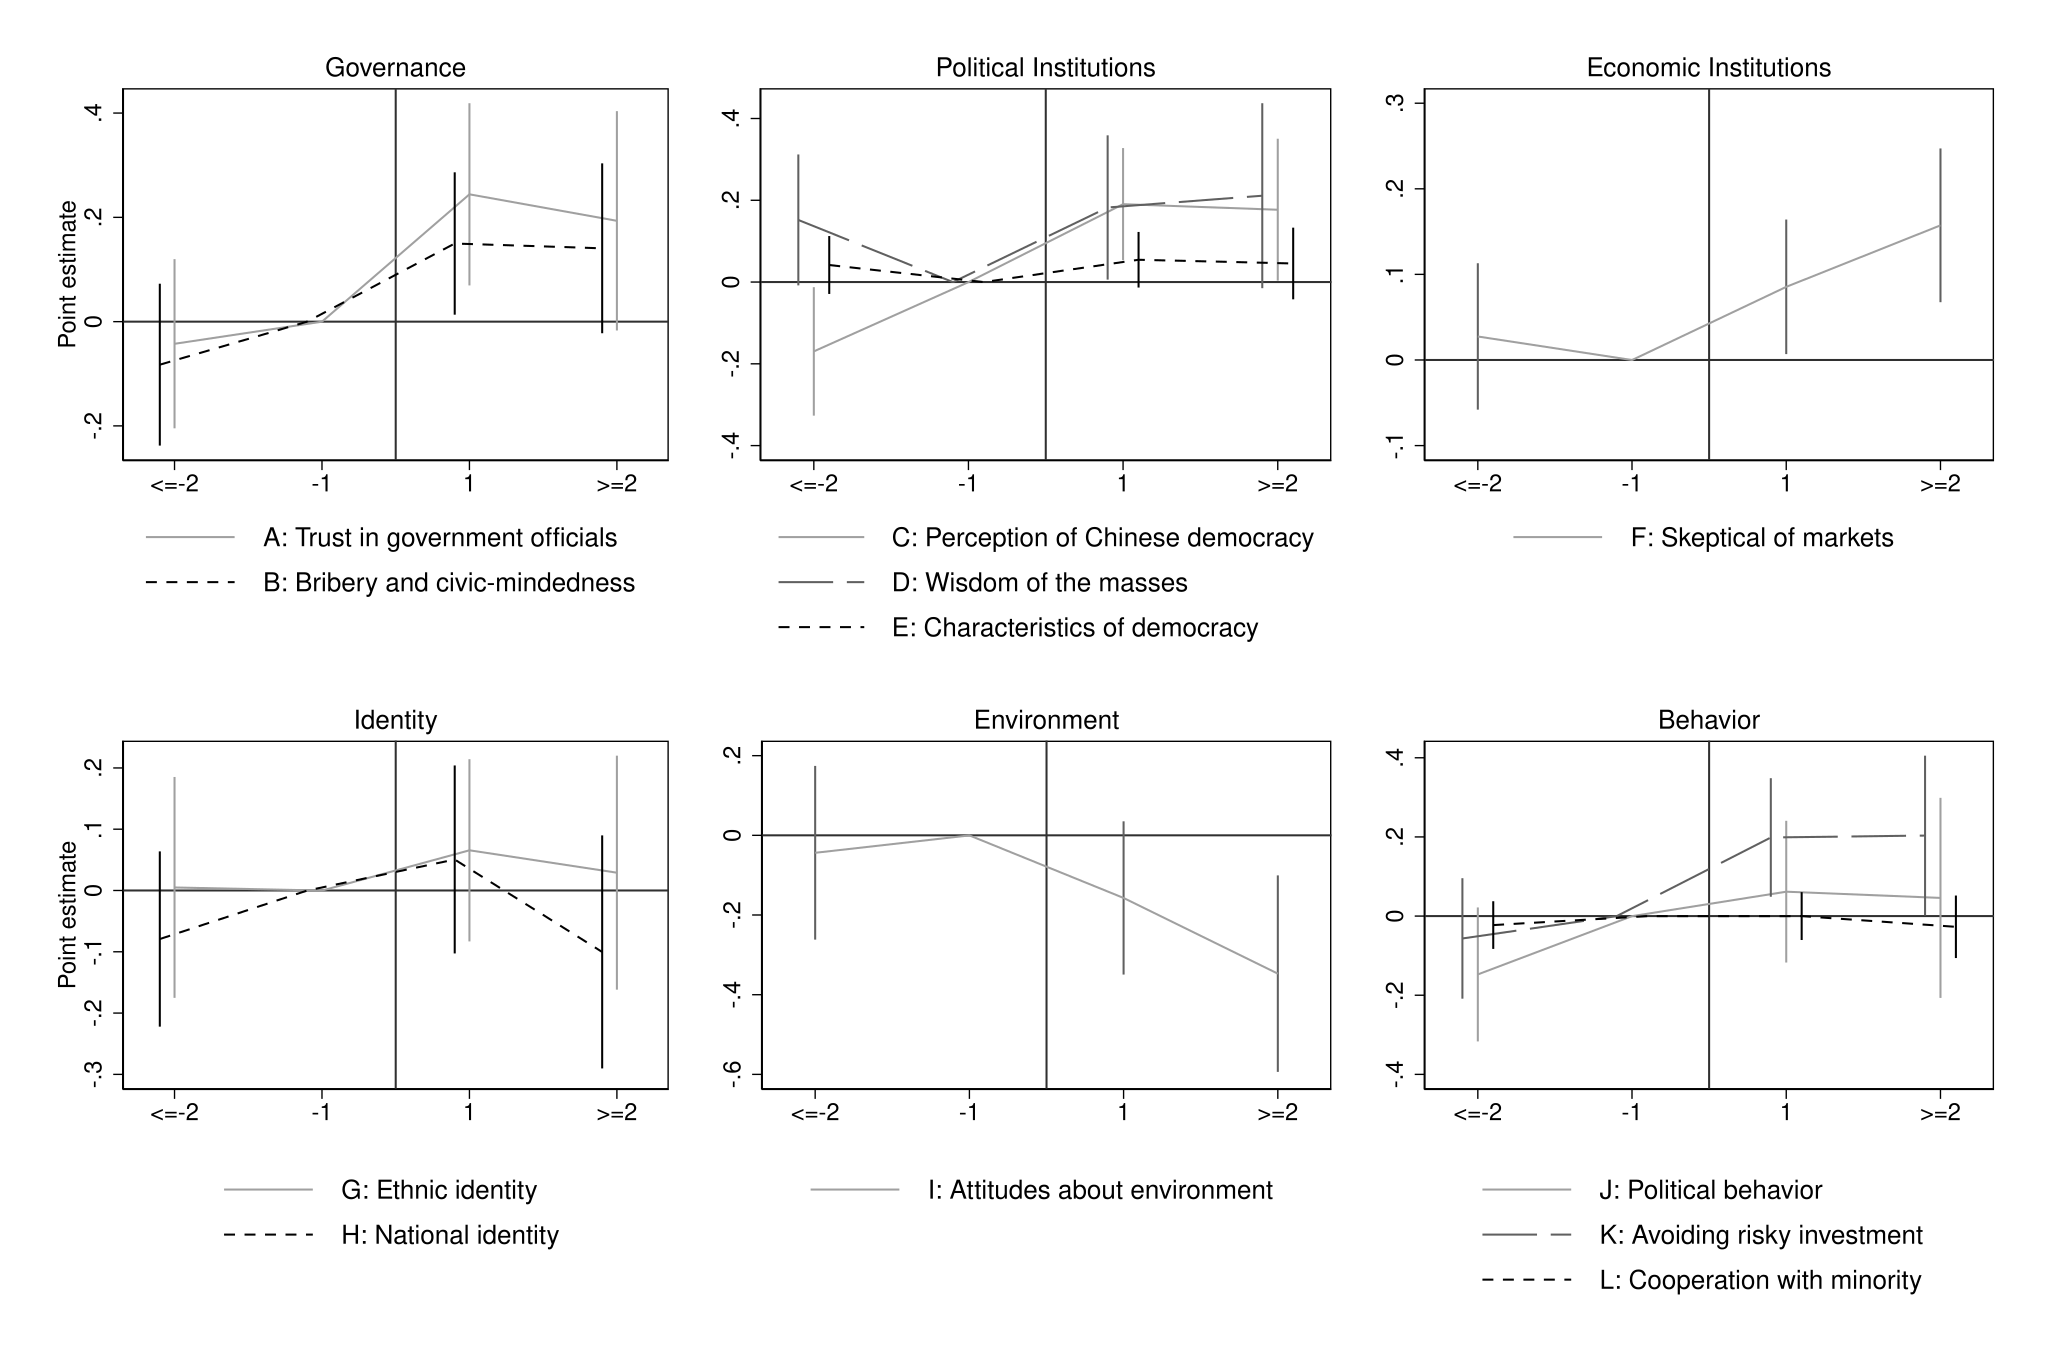

In [13]:
%%stata
quiet{
* 	panel 1: political trust

	#delimit ;
	cap drop beta ;	cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
	gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
	#delimit cr
	
	qui xi: reg az_trust_govt curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 2
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace curriculumy=-2 in 2

	replace beta=0 in 3
	replace   ub=0 in 3
	replace   lb=0 in 3
	replace curriculumy=-1 in 3
	
	replace beta=_b[curry0] in 4
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 4
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 4
	replace curriculumy=0 in 4

	replace beta=_b[curry1plus] in 5
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace curriculumy=1 in 5

	replace variable="az_trust_govt" in 2/5

	qui xi: reg az_quality_govern curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 6
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace curriculumy=-2.1 in 6

	replace beta=0 in 7
	replace   ub=0 in 7
	replace   lb=0 in 7
	replace curriculumy=-1.1 in 7
	
	replace beta=_b[curry0] in 8
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 8
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 8
	replace curriculumy=-0.1 in 8

	replace beta=_b[curry1plus] in 9
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace curriculumy=0.9 in 9

	replace variable="az_quality_govern" in 6/9
		
	cap label drop curriculumy
	label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
	label values curriculumy curriculumy

	twoway (rspike ub lb curriculumy if variable=="az_trust_govt", lc(gs10)) ///
		(line beta curriculumy if variable=="az_trust_govt", lp(solid) lc(gs10)) ///
		(rspike ub lb curriculumy if variable=="az_quality_govern", lc(black)) ///
		(line beta curriculumy if variable=="az_quality_govern", lp(shortdash) lc(black)), ///
		scheme(s1mono) subtitle("Governance") nodraw saving(trust_govt, replace) ///
		xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
		ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
		legend(order(2 4 - " ") cols(1) ///
		label(2 "A: Trust in government officials") label(4 "B: Bribery and civic-mindedness") ///
		size(medium) region(lstyle(none)))


* 	panel 2: political institutions
	
	#delimit ;
	cap drop beta ;	cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
	gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
	#delimit cr
	
	qui xi: reg az_democracy_attitude curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 2
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace curriculumy=-2 in 2

	replace beta=0 in 3
	replace   ub=0 in 3
	replace   lb=0 in 3
	replace curriculumy=-1 in 3
	
	replace beta=_b[curry0] in 4
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 4
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 4
	replace curriculumy=0 in 4

	replace beta=_b[curry1plus] in 5
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace curriculumy=1 in 5

	replace variable="az_democracy_attitude" in 2/5

	qui xi: reg az_wisdom_masses curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 6
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace curriculumy=-2.1 in 6

	replace beta=0 in 7
	replace   ub=0 in 7
	replace   lb=0 in 7
	replace curriculumy=-1.1 in 7
	
	replace beta=_b[curry0] in 8
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 8
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 8
	replace curriculumy=-0.1 in 8

	replace beta=_b[curry1plus] in 9
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace curriculumy=0.9 in 9

	replace variable="az_wisdom_masses" in 6/9
		
	qui xi: reg k214_top curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 10
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 10
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 10
	replace curriculumy=-1.9 in 10

	replace beta=0 in 11
	replace   ub=0 in 11
	replace   lb=0 in 11
	replace curriculumy=-0.9 in 11
	
	replace beta=_b[curry0] in 12
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 12
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 12
	replace curriculumy=0.1 in 12

	replace beta=_b[curry1plus] in 13
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 13
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 13
	replace curriculumy=1.1 in 13

	replace variable="k214_top" in 10/13
	
	cap label drop curriculumy
	label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
	label values curriculumy curriculumy

	twoway (rspike ub lb curriculumy if variable=="az_democracy_attitude", lc(gs10)) ///
		(line beta curriculumy if variable=="az_democracy_attitude", lp(solid) lc(gs10)) ///
		(rspike ub lb curriculumy if variable=="az_wisdom_masses", lc(gs6)) ///
		(line beta curriculumy if variable=="az_wisdom_masses", lp(longdash) lc(gs6)) ///
		(rspike ub lb curriculumy if variable=="k214_top", lc(black)) ///
		(line beta curriculumy if variable=="k214_top", lp(shortdash) lc(black)), ///
		scheme(s1mono) subtitle("Political Institutions") nodraw saving(poli_inst, replace) ///
		xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
		yline(0) ysize(4) xsize(6) ///
		legend(order(2 4 6) cols(1) ///
		label(2 "C: Perception of Chinese democracy") label(4 "D: Wisdom of the masses") ///
		label(6 "E: Characteristics of democracy") size(medium) region(lstyle(none)))

* 	panel 3: markets
	
	#delimit ;
	cap drop beta ;	cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
	gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
	#delimit cr
	
	qui xi: reg k1_marketno curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 2
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace curriculumy=-2 in 2

	replace beta=0 in 3
	replace   ub=0 in 3
	replace   lb=0 in 3
	replace curriculumy=-1 in 3
	
	replace beta=_b[curry0] in 4
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 4
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 4
	replace curriculumy=0 in 4

	replace beta=_b[curry1plus] in 5
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace curriculumy=1 in 5

	replace variable="k1_marketno" in 2/5
	
	cap label drop curriculumy
	label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
	label values curriculumy curriculumy

	twoway (rspike ub lb curriculumy if variable=="k1_marketno") ///
		(line beta curriculumy if variable=="k1_marketno"), ///
		scheme(s1mono) subtitle("Economic Institutions") nodraw saving(mkt, replace) ///
		xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
		yline(0) ysize(4) xsize(6) ///
		legend(order(2 - " " - " ") cols(1) ///
		label(2 "F: Skeptical of markets") ///
		size(medium) region(lstyle(none)))

*	panel 4: national identity

	#delimit ;
	cap drop beta ;	cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
	gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
	#delimit cr
	
	qui xi: reg az_minority curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 2
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace curriculumy=-2 in 2

	replace beta=0 in 3
	replace   ub=0 in 3
	replace   lb=0 in 3
	replace curriculumy=-1 in 3
	
	replace beta=_b[curry0] in 4
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 4
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 4
	replace curriculumy=0 in 4

	replace beta=_b[curry1plus] in 5
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace curriculumy=1 in 5

	replace variable="az_minority" in 2/5

	qui xi: reg o1 curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 6
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace curriculumy=-2.1 in 6

	replace beta=0 in 7
	replace   ub=0 in 7
	replace   lb=0 in 7
	replace curriculumy=-1.1 in 7
	
	replace beta=_b[curry0] in 8
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 8
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 8
	replace curriculumy=-0.1 in 8

	replace beta=_b[curry1plus] in 9
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace curriculumy=0.9 in 9

	replace variable="o1" in 6/9
		
	cap label drop curriculumy
	label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
	label values curriculumy curriculumy

	twoway (rspike ub lb curriculumy if variable=="az_minority", lc(gs10)) ///
		(line beta curriculumy if variable=="az_minority", lp(solid) lc(gs10)) ///
		(rspike ub lb curriculumy if variable=="o1", lc(black)) ///
		(line beta curriculumy if variable=="o1", lp(shortdash) lc(black)), ///
		scheme(s1mono) subtitle("Identity") nodraw saving(nat_identity, replace) ///
		xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
		ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
		legend(order(2 4 - " ") cols(1) ///
		label(2 "G: Ethnic identity") label(4 "H: National identity") ///
		size(medium) region(lstyle(none)))
		
* 	panel 5: environment
	
	#delimit ;
	cap drop beta ;	cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
	gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
	#delimit cr
	
	qui xi: reg az_environment curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 2
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace curriculumy=-2 in 2

	replace beta=0 in 3
	replace   ub=0 in 3
	replace   lb=0 in 3
	replace curriculumy=-1 in 3
	
	replace beta=_b[curry0] in 4
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 4
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 4
	replace curriculumy=0 in 4

	replace beta=_b[curry1plus] in 5
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace curriculumy=1 in 5

	replace variable="az_environment" in 2/5
	
	cap label drop curriculumy
	label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
	label values curriculumy curriculumy

	twoway (rspike ub lb curriculumy if variable=="az_environment") ///
		(line beta curriculumy if variable=="az_environment"), ///
		scheme(s1mono) subtitle("Environment") nodraw saving(envi, replace) ///
		xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
		yline(0) ysize(4) xsize(6) ///
		legend(order(2 - " " - " ") cols(1) ///
		label(2 "I: Attitudes about environment") ///
		size(medium) region(lstyle(none)))

* 	panel 6: behavio(u)r
	
	#delimit ;
	cap drop beta ;	cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
	gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
	#delimit cr
	
	qui xi: reg az_poli_behavior curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 2
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 2
	replace curriculumy=-2 in 2

	replace beta=0 in 3
	replace   ub=0 in 3
	replace   lb=0 in 3
	replace curriculumy=-1 in 3
	
	replace beta=_b[curry0] in 4
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 4
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 4
	replace curriculumy=0 in 4

	replace beta=_b[curry1plus] in 5
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 5
	replace curriculumy=1 in 5

	replace variable="az_poli_behavior" in 2/5

	qui xi: reg az_invest_risky curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 6
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 6
	replace curriculumy=-2.1 in 6

	replace beta=0 in 7
	replace   ub=0 in 7
	replace   lb=0 in 7
	replace curriculumy=-1.1 in 7
	
	replace beta=_b[curry0] in 8
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 8
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 8
	replace curriculumy=-0.1 in 8

	replace beta=_b[curry1plus] in 9
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 9
	replace curriculumy=0.9 in 9

	replace variable="az_invest_risky" in 6/9
		
	qui xi: reg q9 curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
		
	replace beta=_b[curryn2minus] in 10
	replace   ub=_b[curryn2minus]+invttail(e(df_r),0.025)*_se[curryn2minus] in 10
	replace   lb=_b[curryn2minus]-invttail(e(df_r),0.025)*_se[curryn2minus] in 10
	replace curriculumy=-1.9 in 10

	replace beta=0 in 11
	replace   ub=0 in 11
	replace   lb=0 in 11
	replace curriculumy=-0.9 in 11
	
	replace beta=_b[curry0] in 12
	replace   ub=_b[curry0]+invttail(e(df_r),0.025)*_se[curry0] in 12
	replace   lb=_b[curry0]-invttail(e(df_r),0.025)*_se[curry0] in 12
	replace curriculumy=0.1 in 12

	replace beta=_b[curry1plus] in 13
	replace   ub=_b[curry1plus]+invttail(e(df_r),0.025)*_se[curry1plus] in 13
	replace   lb=_b[curry1plus]-invttail(e(df_r),0.025)*_se[curry1plus] in 13
	replace curriculumy=1.1 in 13

	replace variable="q9" in 10/13
	
	cap label drop curriculumy
	label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
	label values curriculumy curriculumy

	twoway (rspike ub lb curriculumy if variable=="az_poli_behavior", lc(gs10)) ///
		(line beta curriculumy if variable=="az_poli_behavior", lp(solid) lc(gs10)) ///
		(rspike ub lb curriculumy if variable=="az_invest_risky", lc(gs6)) ///
		(line beta curriculumy if variable=="az_invest_risky", lp(longdash) lc(gs6)) ///
		(rspike ub lb curriculumy if variable=="q9", lc(black)) ///
		(line beta curriculumy if variable=="q9", lp(shortdash) lc(black)), ///
		scheme(s1mono) subtitle("Behavior") nodraw saving(behavior, replace) ///
		xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
		yline(0) ysize(4) xsize(6) ///
		legend(order(2 4 6) cols(1) ///
		label(2 "J: Political behavior") label(4 "K: Avoiding risky investment") label(6 "L: Cooperation with minority") ///
		size(medium) region(lstyle(none)))

*	combine panels
				
	graph combine trust_govt.gph poli_inst.gph mkt.gph nat_identity.gph envi.gph behavior.gph, ///
		scheme(s1color) /*subtitle("Effects by time relative to curriculum change")*/  ///
		ysize(6) xsize(9)  iscale(*.75)
	graph export "figure_4.pdf", replace 

	erase trust_govt.gph 
	erase poli_inst.gph 
	erase mkt.gph 
	erase nat_identity.gph 
	erase envi.gph
	erase behavior.gph
}

## Discussion

### Pre-Trends Analysis

If we take confidence interval into consideration, then there is no significant pre-trend in the figure 4.

This is a TOP 5 paper, so obviously **there is no pre-trends**.

On the other hand, if we ignore confidence interval, and only focus on trend, then:

Clear pre-trends are visible in several outcomes, particularly in:

- Trust in government officials (A): Shows a noticeable upward trend before treatment (t-2 to t-1)

- Bribery and civic-mindedness (B): Also displays pre-treatment movement

- Perception of Chinese democracy (C): Appears to have some pre-existing trends

- Ethnic identity (G): Shows potential pre-treatment differences

No Significant Pre-Trends:

- Characteristics of democracy (E): Parallel trends appear better maintained

- Attitudes about environment (I): Pre-treatment periods show relative stability

- Political behavior (J): Fairly stable before treatment

### Impact on DiD Validity

1. **Violation of Parallel Trends Assumption**
   
The presence of pre-trends in multiple outcomes seriously challenges the key identifying assumption of DiD - that treatment and control groups would have followed parallel paths in the absence of treatment.

2. **Direction of Bias**
   
For outcomes with upward pre-trends (A, B), the DiD estimates are likely overstated

The treatment effects may reflect continuation of pre-existing trends rather than causal impacts of the curriculum reform

3. **Credibility Concerns**
   
The systematic pre-trends across multiple governance-related outcomes suggest potential selection bias

Treated and control groups may have been on different trajectories before the reform, making causal attribution problematic

# Replication with Recent DiD Estimators

## Figure 4 by Stacked DID

### drop

In [14]:
%%stata
cap drop year_numeric
cap drop first_treat
cap drop first_treat_province
cap drop province_num
cap drop reform_year
cap drop never_treated
cap drop event_id

cap drop treat
cap drop rel_time
cap drop pre2
cap drop current
cap drop post1


. cap drop year_numeric

. cap drop first_treat

. cap drop first_treat_province

. cap drop province_num

. cap drop reform_year

. cap drop never_treated

. cap drop event_id

. 
. cap drop treat

. cap drop rel_time

. cap drop pre2

. cap drop current

. cap drop post1

. 


### compare

In [15]:
%%stata
quiet{

    // Stacked DID 实现 - 避免数据问题
    
    // 步骤1: 创建数值型年份变量
    gen year_numeric = real(year)
    di "已创建数值型年份变量 year_numeric"
    
    // 步骤2: 将省份变量转换为数值型
    encode province, gen(province_num)
    di "已创建数值型省份变量 province_num"
    
    // 步骤3: 创建处理时间变量
    gen reform_year = .
    replace reform_year = year_numeric if curry0 == 1
    bysort province_num: egen first_treat = min(reform_year)
    
    // 识别从未改革的省份作为控制组
    levelsof first_treat if !missing(first_treat), local(reform_years)
    gen never_treated = missing(first_treat)
    levelsof province_num if never_treated == 1, local(control_provinces)
    
    // 识别改革年份（排除从第一期就被处理的）
    // levelsof first_treat if !missing(first_treat) & first_treat > min(year_numeric), local(reform_years)
    
    di "改革年份: `reform_years'"
    di "控制组省份数量: `: word count `control_provinces''"
    
    // 步骤4: 保存原始数据
    tempfile original_data
    save "`original_data'"
    
    // 步骤5: 初始化堆叠数据集
    clear
    tempfile stacked_data
    save "`stacked_data'", emptyok replace
    
    // 步骤6: 为每个改革事件创建堆叠数据集
    foreach g of local reform_years {
        use "`original_data'", clear
        
        di "处理改革年份: `g'"
        
        // 定义事件窗口：改革前后各2年
        local start_year = `g' - 2
        local end_year = `g' + 1
        
        // 选择样本：处理组 + 从未改革的控制组
        keep if (first_treat == `g') | (never_treated == 1)
        keep if inrange(year_numeric, `start_year', `end_year')
        
        di "  样本数量: " _N
        
        // 创建事件标识符和处理变量
        gen event_id = `g'
        gen treat = (first_treat == `g')
        
        // 创建相对时间变量
        gen rel_time = year_numeric - `g'
        
        // 创建事件研究虚拟变量（与原论文一致）
        gen pre2 = (rel_time <= -2) * treat  // 对应curryn2minus
        gen current = (rel_time == 0) * treat    // 对应curry0
        gen post1 = (rel_time >= 1) * treat      // 对应curry1plus
        
        // 添加到堆叠数据集
        append using "`stacked_data'"
        save "`stacked_data'", replace
    }
    
    // 步骤7: 使用堆叠数据进行分析
    use "`stacked_data'", clear
    
    di "堆叠数据集创建完成，包含 " _N " 个观察值"
    
    // 检查数据结构
    tab event_id treat
    
    // 步骤8: 运行Stacked DID回归
    reghdfe az_trust_govt pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    // 步骤9: 提取系数和标准误
    local beta_pre2 = _b[pre2]
    local se_pre2 = _se[pre2]
    local beta_current = _b[current]
    local se_current = _se[current]
    local beta_post1 = _b[post1]
    local se_post1 = _se[post1]
    
    // 步骤10: 创建存储变量
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    // 步骤11: 存储Stacked DID结果
    replace beta = `beta_pre2' in 2
    replace ub = `beta_pre2' + 1.96 * `se_pre2' in 2
    replace lb = `beta_pre2' - 1.96 * `se_pre2' in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3  
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = `beta_current' in 4
    replace ub = `beta_current' + 1.96 * `se_current' in 4
    replace lb = `beta_current' - 1.96 * `se_current' in 4
    replace curriculumy = 0 in 4
    
    replace beta = `beta_post1' in 5
    replace ub = `beta_post1' + 1.96 * `se_post1' in 5
    replace lb = `beta_post1' - 1.96 * `se_post1' in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_trust_govt" in 2/5
    
    // 步骤12: 显示Stacked DID结果
    di "=== Stacked DID 结果 ==="
    di "改革前 (<=-2年): " %6.3f `beta_pre2' " (标准误: " %6.3f `se_pre2' ")"
    di "改革当年: " %6.3f `beta_current' " (标准误: " %6.3f `se_current' ")"  
    di "改革后 (>=1年): " %6.3f `beta_post1' " (标准误: " %6.3f `se_post1' ")"
    
    // 步骤13: 对第二个变量运行Stacked DID
    use "`stacked_data'", clear
    reghdfe az_quality_govern pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    local beta_pre2_2 = _b[pre2]
    local se_pre2_2 = _se[pre2]
    local beta_current_2 = _b[current]
    local se_current_2 = _se[current]
    local beta_post1_2 = _b[post1]
    local se_post1_2 = _se[post1]
    
    // 存储第二个变量的结果
    replace beta = `beta_pre2_2' in 6
    replace ub = `beta_pre2_2' + 1.96 * `se_pre2_2' in 6
    replace lb = `beta_pre2_2' - 1.96 * `se_pre2_2' in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = `beta_current_2' in 8
    replace ub = `beta_current_2' + 1.96 * `se_current_2' in 8
    replace lb = `beta_current_2' - 1.96 * `se_current_2' in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = `beta_post1_2' in 9
    replace ub = `beta_post1_2' + 1.96 * `se_post1_2' in 9
    replace lb = `beta_post1_2' - 1.96 * `se_post1_2' in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_quality_govern" in 6/9
    
    // 步骤14: 与传统方法对比
    use "`original_data'", clear
    di "=== 与传统TWFE对比 ==="
    qui xi: reg az_trust_govt curryn2minus curry0 curry1plus i.cohort i.province, r cluster(proXcoh)
    di "传统 - 改革前: " %6.3f _b[curryn2minus] " (标准误: " %6.3f _se[curryn2minus] ")"
    di "传统 - 改革当年: " %6.3f _b[curry0] " (标准误: " %6.3f _se[curry0] ")"  
    di "传统 - 改革后: " %6.3f _b[curry1plus] " (标准误: " %6.3f _se[curry1plus] ")"
    
    // 步骤15: 创建图形
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_trust_govt", lc(gs10)) ///
        (line beta curriculumy if variable=="az_trust_govt", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_quality_govern", lc(black)) ///
        (line beta curriculumy if variable=="az_quality_govern", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Governance - Stacked DID") nodraw saving(trust_govt_stacked, replace) ///
        xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 - " ") cols(1) ///
        label(2 "A: Trust in government officials") label(4 "B: Bribery and civic-mindedness") ///
        size(medium) region(lstyle(none)))
    
    graph export "stacked_did_panel1.pdf", replace
    di "Stacked DID图形已导出为 stacked_did_panel1.pdf"

}


. quiet{

. 


### stacked did

In [16]:
%%stata
cap drop year_numeric
cap drop first_treat
cap drop first_treat_province
cap drop province_num
cap drop reform_year
cap drop never_treated
cap drop event_id

cap drop treat
cap drop rel_time
cap drop pre2
cap drop current
cap drop post1


. cap drop year_numeric

. cap drop first_treat

. cap drop first_treat_province

. cap drop province_num

. cap drop reform_year

. cap drop never_treated

. cap drop event_id

. 
. cap drop treat

. cap drop rel_time

. cap drop pre2

. cap drop current

. cap drop post1

. 



. quiet{

. 


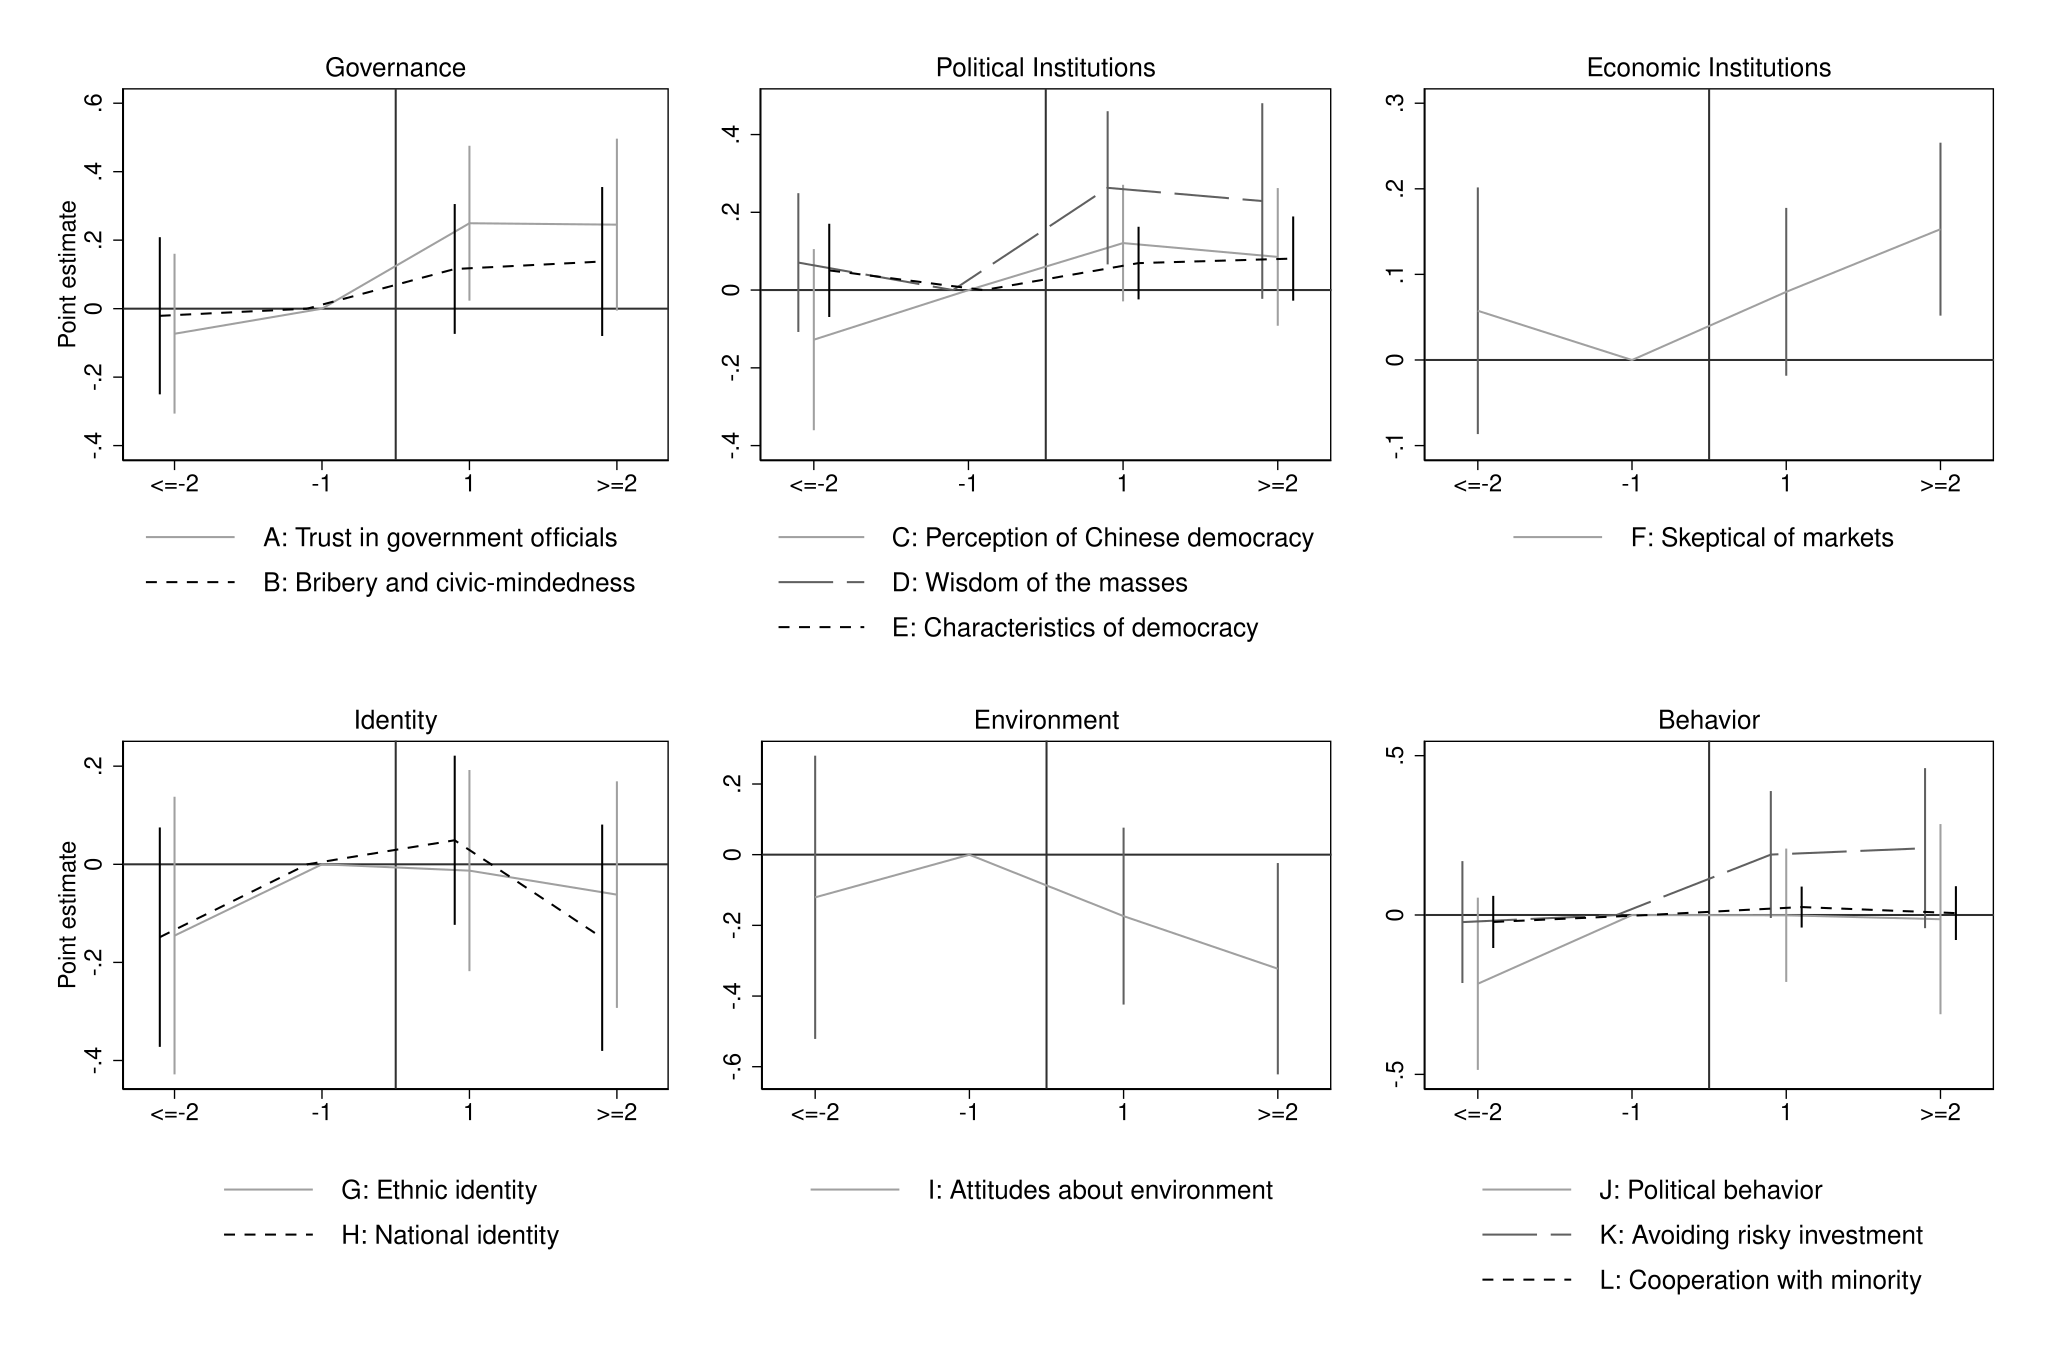

In [17]:
%%stata
quiet{
    // Stacked DID 实现 
    
    // 步骤1-6: 创建堆叠数据集（与第二段代码相同）
    gen year_numeric = real(year)
    di "已创建数值型年份变量 year_numeric"
    
    encode province, gen(province_num)
    di "已创建数值型省份变量 province_num"
    
    gen reform_year = .
    replace reform_year = year_numeric if curry0 == 1
    bysort province_num: egen first_treat = min(reform_year)
    
    levelsof first_treat if !missing(first_treat), local(reform_years)
    gen never_treated = missing(first_treat)
    levelsof province_num if never_treated == 1, local(control_provinces)
    
    di "改革年份: `reform_years'"
    di "控制组省份数量: `: word count `control_provinces''"
    
    tempfile original_data
    save "`original_data'"
    
    clear
    tempfile stacked_data
    save "`stacked_data'", emptyok replace
    
    foreach g of local reform_years {
        use "`original_data'", clear
        
        di "处理改革年份: `g'"
        
        local start_year = `g' - 2
        local end_year = `g' + 1
        
        keep if (first_treat == `g') | (never_treated == 1)
        keep if inrange(year_numeric, `start_year', `end_year')
        
        di "  样本数量: " _N
        
        gen event_id = `g'
        gen treat = (first_treat == `g')
        gen rel_time = year_numeric - `g'
        gen pre2 = (rel_time <= -2) * treat
        gen current = (rel_time == 0) * treat
        gen post1 = (rel_time >= 1) * treat
        
        append using "`stacked_data'"
        save "`stacked_data'", replace
    }
    
    // 步骤8: 为所有六个panel运行Stacked DID回归并绘图
    
    // Panel 1: Governance
    use "`stacked_data'", clear
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    // az_trust_govt
    reghdfe az_trust_govt pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 2
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 2
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3  
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = _b[current] in 4
    replace ub = _b[current] + 1.96 * _se[current] in 4
    replace lb = _b[current] - 1.96 * _se[current] in 4
    replace curriculumy = 0 in 4
    
    replace beta = _b[post1] in 5
    replace ub = _b[post1] + 1.96 * _se[post1] in 5
    replace lb = _b[post1] - 1.96 * _se[post1] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_trust_govt" in 2/5
    
    // az_quality_govern
    reghdfe az_quality_govern pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 6
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 6
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = _b[current] in 8
    replace ub = _b[current] + 1.96 * _se[current] in 8
    replace lb = _b[current] - 1.96 * _se[current] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = _b[post1] in 9
    replace ub = _b[post1] + 1.96 * _se[post1] in 9
    replace lb = _b[post1] - 1.96 * _se[post1] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_quality_govern" in 6/9
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_trust_govt", lc(gs10)) ///
        (line beta curriculumy if variable=="az_trust_govt", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_quality_govern", lc(black)) ///
        (line beta curriculumy if variable=="az_quality_govern", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Governance") nodraw saving(trust_govt_stacked, replace) ///
        xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 - " ") cols(1) ///
        label(2 "A: Trust in government officials") label(4 "B: Bribery and civic-mindedness") ///
        size(medium) region(lstyle(none)))
    
    // Panel 2: Political Institutions
    use "`stacked_data'", clear
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    // az_democracy_attitude
    reghdfe az_democracy_attitude pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 2
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 2
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = _b[current] in 4
    replace ub = _b[current] + 1.96 * _se[current] in 4
    replace lb = _b[current] - 1.96 * _se[current] in 4
    replace curriculumy = 0 in 4
    
    replace beta = _b[post1] in 5
    replace ub = _b[post1] + 1.96 * _se[post1] in 5
    replace lb = _b[post1] - 1.96 * _se[post1] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_democracy_attitude" in 2/5
    
    // az_wisdom_masses
    reghdfe az_wisdom_masses pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 6
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 6
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = _b[current] in 8
    replace ub = _b[current] + 1.96 * _se[current] in 8
    replace lb = _b[current] - 1.96 * _se[current] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = _b[post1] in 9
    replace ub = _b[post1] + 1.96 * _se[post1] in 9
    replace lb = _b[post1] - 1.96 * _se[post1] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_wisdom_masses" in 6/9
    
    // k214_top
    reghdfe k214_top pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 10
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 10
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 10
    replace curriculumy = -1.9 in 10
    
    replace beta = 0 in 11
    replace ub = 0 in 11
    replace lb = 0 in 11
    replace curriculumy = -0.9 in 11
    
    replace beta = _b[current] in 12
    replace ub = _b[current] + 1.96 * _se[current] in 12
    replace lb = _b[current] - 1.96 * _se[current] in 12
    replace curriculumy = 0.1 in 12
    
    replace beta = _b[post1] in 13
    replace ub = _b[post1] + 1.96 * _se[post1] in 13
    replace lb = _b[post1] - 1.96 * _se[post1] in 13
    replace curriculumy = 1.1 in 13
    
    replace variable = "k214_top" in 10/13
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_democracy_attitude", lc(gs10)) ///
        (line beta curriculumy if variable=="az_democracy_attitude", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_wisdom_masses", lc(gs6)) ///
        (line beta curriculumy if variable=="az_wisdom_masses", lp(longdash) lc(gs6)) ///
        (rspike ub lb curriculumy if variable=="k214_top", lc(black)) ///
        (line beta curriculumy if variable=="k214_top", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Political Institutions") nodraw saving(poli_inst_stacked, replace) ///
        xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 6) cols(1) ///
        label(2 "C: Perception of Chinese democracy") label(4 "D: Wisdom of the masses") ///
        label(6 "E: Characteristics of democracy") size(medium) region(lstyle(none)))
    
    // Panel 3: Economic Institutions
    use "`stacked_data'", clear
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    // k1_marketno
    reghdfe k1_marketno pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 2
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 2
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = _b[current] in 4
    replace ub = _b[current] + 1.96 * _se[current] in 4
    replace lb = _b[current] - 1.96 * _se[current] in 4
    replace curriculumy = 0 in 4
    
    replace beta = _b[post1] in 5
    replace ub = _b[post1] + 1.96 * _se[post1] in 5
    replace lb = _b[post1] - 1.96 * _se[post1] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "k1_marketno" in 2/5
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="k1_marketno") ///
        (line beta curriculumy if variable=="k1_marketno"), ///
        scheme(s1mono) subtitle("Economic Institutions") nodraw saving(mkt_stacked, replace) ///
        xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 - " " - " ") cols(1) ///
        label(2 "F: Skeptical of markets") ///
        size(medium) region(lstyle(none)))
    
    // Panel 4: Identity
    use "`stacked_data'", clear
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    // az_minority
    reghdfe az_minority pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 2
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 2
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = _b[current] in 4
    replace ub = _b[current] + 1.96 * _se[current] in 4
    replace lb = _b[current] - 1.96 * _se[current] in 4
    replace curriculumy = 0 in 4
    
    replace beta = _b[post1] in 5
    replace ub = _b[post1] + 1.96 * _se[post1] in 5
    replace lb = _b[post1] - 1.96 * _se[post1] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_minority" in 2/5
    
    // o1
    reghdfe o1 pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 6
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 6
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = _b[current] in 8
    replace ub = _b[current] + 1.96 * _se[current] in 8
    replace lb = _b[current] - 1.96 * _se[current] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = _b[post1] in 9
    replace ub = _b[post1] + 1.96 * _se[post1] in 9
    replace lb = _b[post1] - 1.96 * _se[post1] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "o1" in 6/9
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_minority", lc(gs10)) ///
        (line beta curriculumy if variable=="az_minority", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="o1", lc(black)) ///
        (line beta curriculumy if variable=="o1", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Identity") nodraw saving(nat_identity_stacked, replace) ///
        xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 - " ") cols(1) ///
        label(2 "G: Ethnic identity") label(4 "H: National identity") ///
        size(medium) region(lstyle(none)))
    
    // Panel 5: Environment
    use "`stacked_data'", clear
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    // az_environment
    reghdfe az_environment pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 2
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 2
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = _b[current] in 4
    replace ub = _b[current] + 1.96 * _se[current] in 4
    replace lb = _b[current] - 1.96 * _se[current] in 4
    replace curriculumy = 0 in 4
    
    replace beta = _b[post1] in 5
    replace ub = _b[post1] + 1.96 * _se[post1] in 5
    replace lb = _b[post1] - 1.96 * _se[post1] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_environment" in 2/5
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_environment") ///
        (line beta curriculumy if variable=="az_environment"), ///
        scheme(s1mono) subtitle("Environment") nodraw saving(envi_stacked, replace) ///
        xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 - " " - " ") cols(1) ///
        label(2 "I: Attitudes about environment") ///
        size(medium) region(lstyle(none)))
    
    // Panel 6: Behavior
    use "`stacked_data'", clear
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    // az_poli_behavior
    reghdfe az_poli_behavior pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 2
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 2
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = _b[current] in 4
    replace ub = _b[current] + 1.96 * _se[current] in 4
    replace lb = _b[current] - 1.96 * _se[current] in 4
    replace curriculumy = 0 in 4
    
    replace beta = _b[post1] in 5
    replace ub = _b[post1] + 1.96 * _se[post1] in 5
    replace lb = _b[post1] - 1.96 * _se[post1] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_poli_behavior" in 2/5
    
    // az_invest_risky
    reghdfe az_invest_risky pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 6
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 6
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = _b[current] in 8
    replace ub = _b[current] + 1.96 * _se[current] in 8
    replace lb = _b[current] - 1.96 * _se[current] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = _b[post1] in 9
    replace ub = _b[post1] + 1.96 * _se[post1] in 9
    replace lb = _b[post1] - 1.96 * _se[post1] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_invest_risky" in 6/9
    
    // q9
    reghdfe q9 pre2 current post1, absorb(event_id##year_numeric event_id##province_num) vce(cluster province_num)
    
    replace beta = _b[pre2] in 10
    replace ub = _b[pre2] + 1.96 * _se[pre2] in 10
    replace lb = _b[pre2] - 1.96 * _se[pre2] in 10
    replace curriculumy = -1.9 in 10
    
    replace beta = 0 in 11
    replace ub = 0 in 11
    replace lb = 0 in 11
    replace curriculumy = -0.9 in 11
    
    replace beta = _b[current] in 12
    replace ub = _b[current] + 1.96 * _se[current] in 12
    replace lb = _b[current] - 1.96 * _se[current] in 12
    replace curriculumy = 0.1 in 12
    
    replace beta = _b[post1] in 13
    replace ub = _b[post1] + 1.96 * _se[post1] in 13
    replace lb = _b[post1] - 1.96 * _se[post1] in 13
    replace curriculumy = 1.1 in 13
    
    replace variable = "q9" in 10/13
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2" 
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_poli_behavior", lc(gs10)) ///
        (line beta curriculumy if variable=="az_poli_behavior", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_invest_risky", lc(gs6)) ///
        (line beta curriculumy if variable=="az_invest_risky", lp(longdash) lc(gs6)) ///
        (rspike ub lb curriculumy if variable=="q9", lc(black)) ///
        (line beta curriculumy if variable=="q9", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Behavior") nodraw saving(behavior_stacked, replace) ///
        xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 6) cols(1) ///
        label(2 "J: Political behavior") label(4 "K: Avoiding risky investment") label(6 "L: Cooperation with minority") ///
        size(medium) region(lstyle(none)))
    
    // 组合所有panel
    graph combine trust_govt_stacked.gph poli_inst_stacked.gph mkt_stacked.gph ///
                  nat_identity_stacked.gph envi_stacked.gph behavior_stacked.gph, ///
        scheme(s1color) ysize(6) xsize(9) iscale(*.75)
    graph export "figure_4_stacked_did.pdf", replace
    
    // 清理临时文件
    erase trust_govt_stacked.gph 
    erase poli_inst_stacked.gph 
    erase mkt_stacked.gph 
    erase nat_identity_stacked.gph 
    erase envi_stacked.gph
    erase behavior_stacked.gph
    
    di "Stacked DID六个panel图形已导出为 figure_4_stacked_did.pdf"
}

## Figure 4 by Sun-Abraham

### install

In [18]:
%%stata

// cap ssc install event_plot
// cap ssc install reghdfe
// cap ssc install avar
// cap ssc install eventstudyinteract


. 
. // cap ssc install event_plot
. // cap ssc install reghdfe
. // cap ssc install avar
. // cap ssc install eventstudyinteract
. 


In [19]:
%%stata

which eventstudyinteract
which event_plot
which reghdfe
which avar


. 
. which eventstudyinteract
C:\Users\ading\ado\plus\e\eventstudyinteract.ado
*! version 0.1  24jan2022  Liyang Sun, lsun20@mit.edu

. which event_plot
C:\Users\ading\ado\plus\e\event_plot.ado
*! event_plot: Plot coefficients from a staggered adoption event study analysis
*! Version: June 1, 2021
*! Author: Kirill Borusyak
*! Please check the latest version at https://github.com/borusyak/did_imputatio
> n/
*! Citation: Borusyak, Jaravel, and Spiess, "Revisiting Event Study Designs: Ro
> bust and Efficient Estimation" (2021)

. which reghdfe
C:\Users\ading\ado\plus\r\reghdfe.ado
*! version 6.12.3 08aug2023

. which avar
C:\Users\ading\ado\plus\a\avar.ado
*! avar 1.0.07  28July2015
*! authors cfb/mes
*! shell based on ranktest by fk/mes
*! see end of file for version comments

. 


### drop

In [20]:
%%stata

cap drop year_numeric
cap drop first_treat
cap drop first_treat_province
cap drop province_num
cap drop reform_year
cap drop never_treated
cap drop event_id

cap drop treat
cap drop rel_time
cap drop pre2
cap drop current
cap drop post1

cap drop relative_time
cap drop L2event L3event L4event L5event L6event L7event L8event L9event L10event
cap drop F1event F2event F3event F4event F5event F6event F7event F8event F9event F10event
#delimit ; 
cap drop L1; cap drop L2; cap drop L3; cap drop L4; cap drop L5; cap drop T0; cap drop F1; cap drop F2; cap drop F3plus; cap drop base_period;
cap drop first_treat_cohort; cap drop evt_time; cap drop proXcoh; cap drop ever_treated;
#delimit cr



. 
. cap drop year_numeric

. cap drop first_treat

. cap drop first_treat_province

. cap drop province_num

. cap drop reform_year

. cap drop never_treated

. cap drop event_id

. 
. cap drop treat

. cap drop rel_time

. cap drop pre2

. cap drop current

. cap drop post1

. 
. cap drop relative_time

. cap drop L2event L3event L4event L5event L6event L7event L8event L9event L10e
> vent

. cap drop F1event F2event F3event F4event F5event F6event F7event F8event F9ev
> ent F10event

. #delimit ; 
delimiter now ;
. cap drop L1;

.  cap drop L2;

.  cap drop L3;

.  cap drop L4;

.  cap drop L5;

.  cap drop T0;

.  cap drop F1;

.  cap drop F2;

.  cap drop F3plus;

.  cap drop base_period;

. cap drop first_treat_cohort;

.  cap drop evt_time;

.  cap drop proXcoh;

.  cap drop ever_treated;

. #delimit cr
delimiter now cr
. 


### Sun-Araham

#### panel 1


.     quiet{
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command
Unknown #command

. 


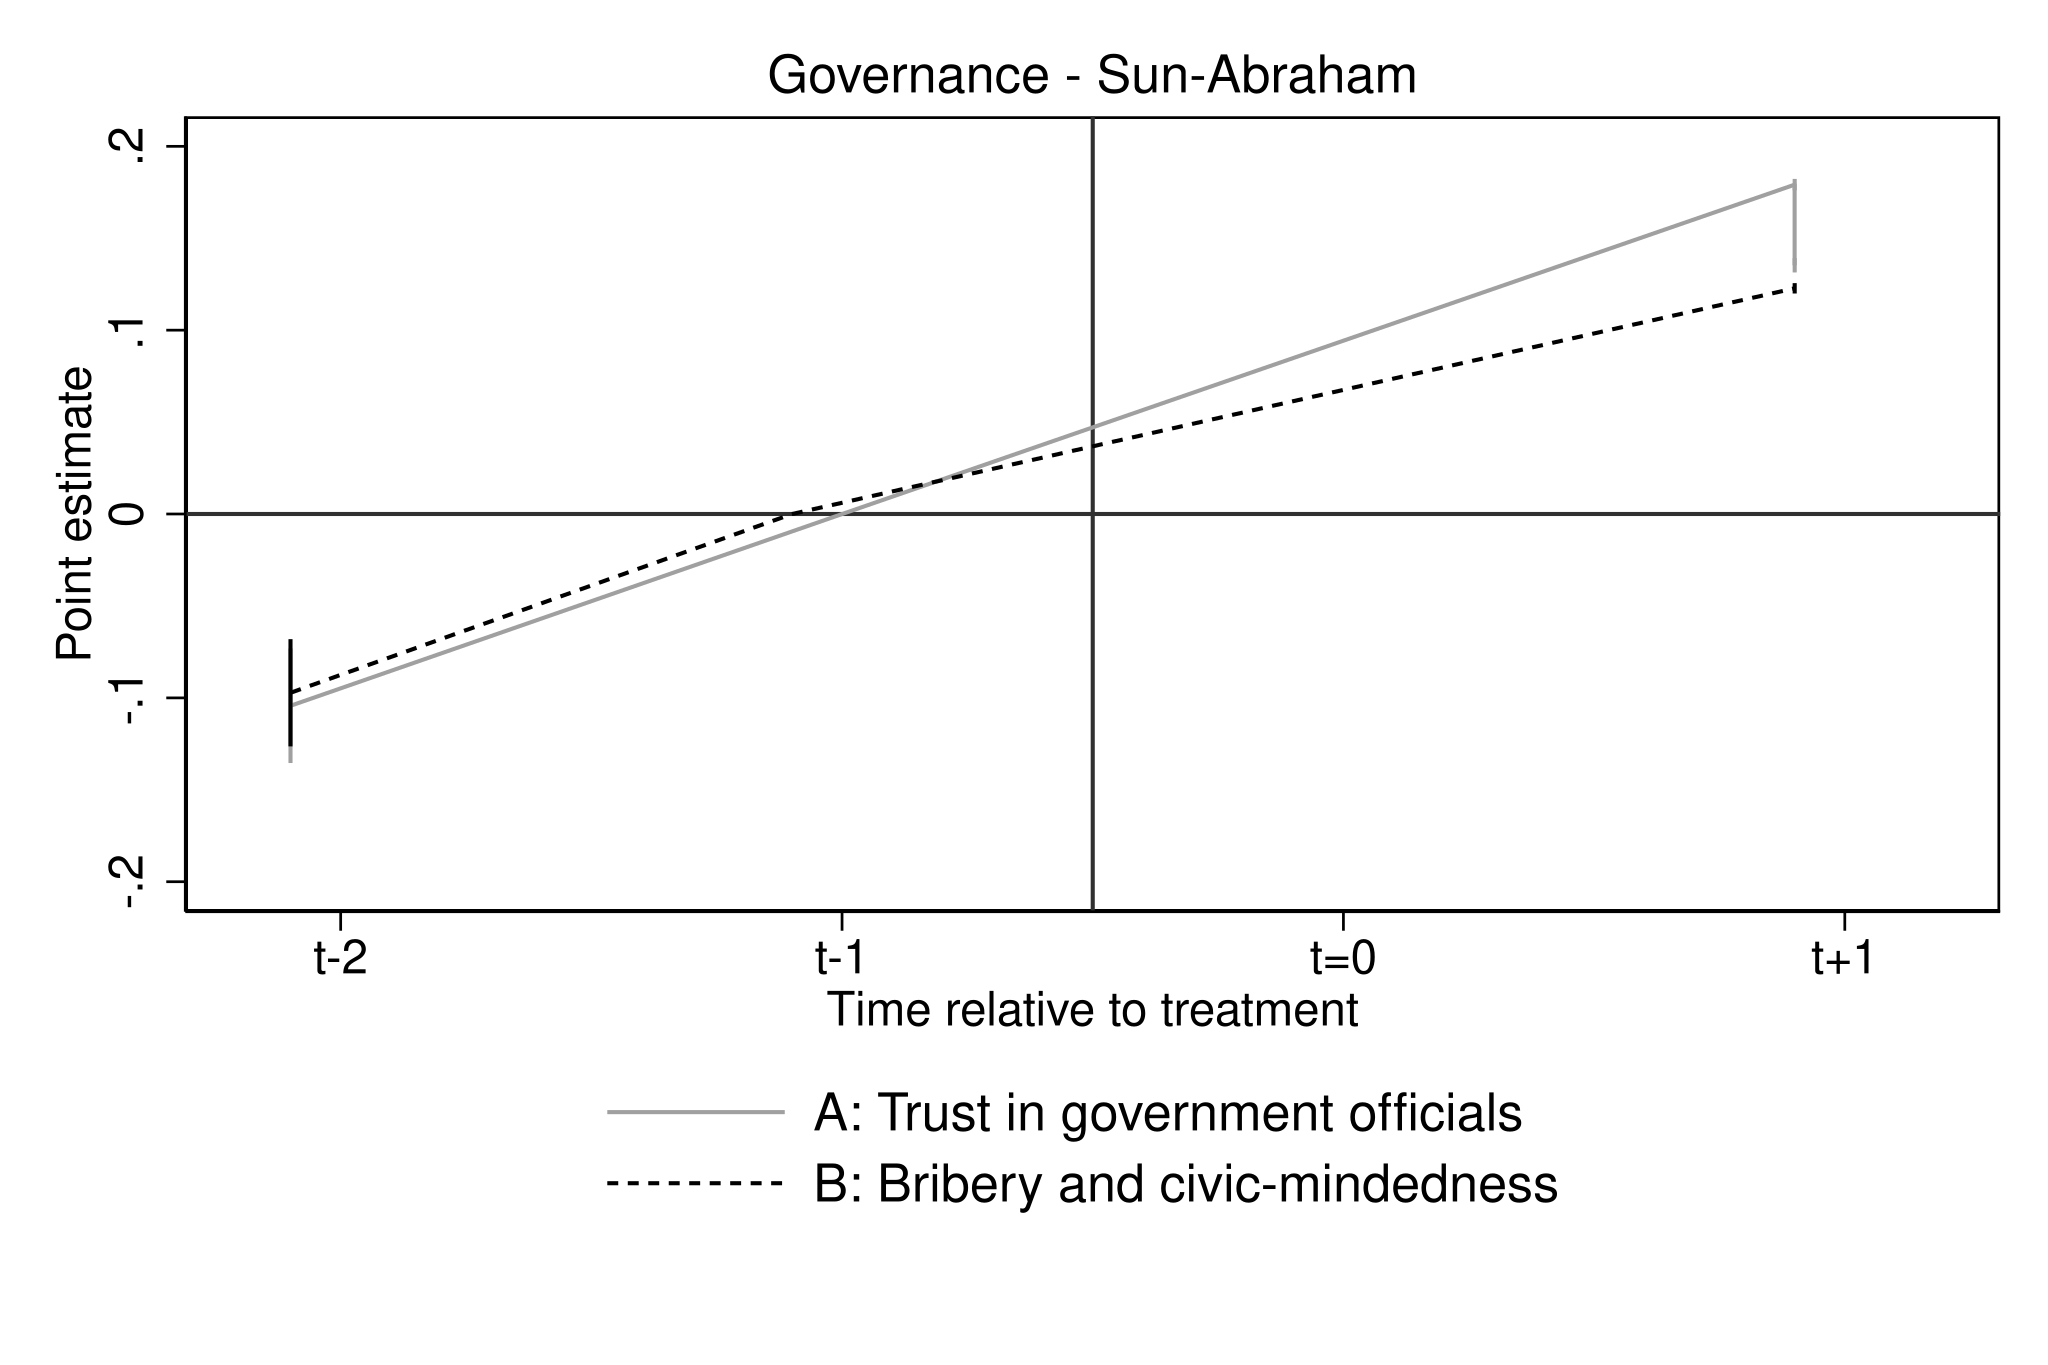

In [21]:
%%stata
    quiet{
    gen year_numeric = real(year)
    di "已创建数值型年份变量 year_numeric"
    
    encode province, gen(province_num)
    di "已创建数值型省份变量 province_num"
    
    egen proXcoh = group(province_num cohort)
    
    * 创建处理状态变量
    gen reform_year = .
    replace reform_year = year_numeric if curry0 == 1
    bysort province_num: egen first_treat = min(reform_year)
    
    gen treated = (cohort >= first_treat) if !missing(first_treat)
    gen ever_treated = !missing(first_treat)
    gen never_treated = missing(first_treat)
    
    
    * 创建相对时间变量
    gen rel_time = cohort - first_treat
    
    * 创建相对时间虚拟变量（Sun-Abraham方法）
    * 定义时间范围，根据您的数据调整
    gen L2plus = (rel_time <= -2)
    * t = 0 的指示变量
    gen T0 = (rel_time == 0)
    * t >= 1 的指示变量
    gen F1plus = (rel_time >= 1)
    * 设置基准期（t = -1），不需要将其包含在回归中
    gen base_period = (rel_time == -1) // 仅作标记，不进入回归
    
    
    
    
    * 面板1: 政治信任 - Sun-Abraham方法
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    * az_trust_govt - 使用Sun-Abraham方法
    eventstudyinteract az_trust_govt L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    # replace beta = _b[L2plus] in 2
    # replace ub = _b[L2plus] + 1.96 * _se[L2plus] in 2
    # replace lb = _b[L2plus] - 1.96 * _se[L2plus] in 2
    # replace curriculumy = -2 in 2
    
    replace beta = e(b_iw)[1, 1] in 2
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 2
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 2
    replace curriculumy = -2.1 in 2
    
    replace beta = 0 in 3  
    * 基准期设为0
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    # replace beta = _b[T0] in 4
    # replace ub = _b[T0] + 1.96 * _se[T0] in 4
    # replace lb = _b[T0] - 1.96 * _se[T0] in 4
    # replace curriculumy = 0 in 4
    
    # replace beta = _b[F1plus] in 5
    # replace ub = _b[F1plus] + 1.96 * _se[F1plus] in 5
    # replace lb = _b[F1plus] - 1.96 * _se[F1plus] in 5
    # replace curriculumy = 1 in 5
    
    replace beta = e(b_iw)[1, 2] in 4
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 4
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 4
    replace curriculumy = 0.9 in 4
    
    replace beta = e(b_iw)[1, 3] in 5
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 5
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 5
    replace curriculumy = 0.9 in 5
    
    replace variable = "az_trust_govt" in 2/5
    
    * az_quality_govern           
    eventstudyinteract az_quality_govern L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
            
    # replace beta = _b[L2plus] in 6
    # replace ub = _b[L2plus] + 1.96 * _se[L2plus] in 6
    # replace lb = _b[L2plus] - 1.96 * _se[L2plus] in 6
    # replace curriculumy = -2.1 in 6
    
    replace beta = e(b_iw)[1, 1] in 6
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 6
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7  
    * 基准期设为0
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = e(b_iw)[1, 2] in 9
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 9
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 9
    replace curriculumy = 0.9 in 9
    
    replace beta = e(b_iw)[1, 3] in 9
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 9
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_quality_govern" in 6/9
        
    * 创建标签
    cap label drop curriculumy
    label define curriculumy -2 "t-2" -1 "t-1" 0 "t=0" 1 "t+1" 
    label values curriculumy curriculumy
    
    * 绘图
    twoway (rspike ub lb curriculumy if variable=="az_trust_govt", lc(gs10)) ///
        (line beta curriculumy if variable=="az_trust_govt", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_quality_govern", lc(black)) ///
        (line beta curriculumy if variable=="az_quality_govern", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Governance - Sun-Abraham")  saving(trust_govt, replace) ///
        xtitle("Time relative to treatment") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 - " ") cols(1) ///
        label(2 "A: Trust in government officials") label(4 "B: Bribery and civic-mindedness") ///
        size(medium) region(lstyle(none)))
}

In [22]:
%%stata
eventstudyinteract az_trust_govt L2plus T0 F1plus ///
    if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
    control_cohort(never_treated) vce(cluster proXcoh)

matrix list e(b_iw)
ereturn list


. eventstudyinteract az_trust_govt L2plus T0 F1plus ///
>     if ever_treated | never_treated, cohort(first_treat) absorb(province_num 
> cohort) ///
>     control_cohort(never_treated) vce(cluster proXcoh)
(obs=898)

IW estimates for dynamic effects                        Number of obs =  2,364
Absorbing 2 HDFE groups                                 F(8, 96)      =   4.13
                                                        Prob > F      = 0.0003
                                                        R-squared     = 0.0290
                                                        Adj R-squared = 0.0127
                                                        Root MSE      = 0.9481
                               (Std. err. adjusted for 97 clusters in proXcoh)
------------------------------------------------------------------------------
             |               Robust
az_trust_g~t | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+--------------------

In [23]:
%%stata
help eventstudyinteract


Title
-----

    eventstudyinteract --
                    implements the interaction weighted (IW) estimator and
                    constructs pointwise confidence interval for the
                    estimation of dynamic treatment effects.  To estimate the
                    dynamic effects of an absorbing treatment, researchers
                    often use two-way fixed effects (TWFE) regressions that
                    include leads and lags of the treatment (event study
                    specification).  Units are categorized into different
                    cohorts based on their initial treatment timing.  Sun and
                    Abraham (2020) proposes this estimator as an alternative
                    to the TWFE regression in the presence of treatment
                    effects heterogeneous across cohorts.  Under treatment
                    effects heterogeneity, the TWFE regression can result in
                    estimates with uninterpretable weights, w

#### all panel

In [24]:
%%stata

cap drop year_numeric
cap drop first_treat
cap drop first_treat_province
cap drop province_num
cap drop reform_year
cap drop never_treated
cap drop event_id

cap drop treat
cap drop rel_time
cap drop pre2
cap drop current
cap drop post1

cap drop relative_time
cap drop L2event L3event L4event L5event L6event L7event L8event L9event L10event
cap drop F1event F2event F3event F4event F5event F6event F7event F8event F9event F10event
#delimit ; 
cap drop L1; cap drop L2; cap drop L3; cap drop L4; cap drop L5; cap drop T0; cap drop F1; cap drop F2; cap drop F3plus; cap drop base_period;
cap drop first_treat_cohort; cap drop evt_time; cap drop proXcoh; cap drop ever_treated;
#delimit cr



. 
. cap drop year_numeric

. cap drop first_treat

. cap drop first_treat_province

. cap drop province_num

. cap drop reform_year

. cap drop never_treated

. cap drop event_id

. 
. cap drop treat

. cap drop rel_time

. cap drop pre2

. cap drop current

. cap drop post1

. 
. cap drop relative_time

. cap drop L2event L3event L4event L5event L6event L7event L8event L9event L10e
> vent

. cap drop F1event F2event F3event F4event F5event F6event F7event F8event F9ev
> ent F10event

. #delimit ; 
delimiter now ;
. cap drop L1;

.  cap drop L2;

.  cap drop L3;

.  cap drop L4;

.  cap drop L5;

.  cap drop T0;

.  cap drop F1;

.  cap drop F2;

.  cap drop F3plus;

.  cap drop base_period;

. cap drop first_treat_cohort;

.  cap drop evt_time;

.  cap drop proXcoh;

.  cap drop ever_treated;

. #delimit cr
delimiter now cr
. 



. 
. quiet{

. 


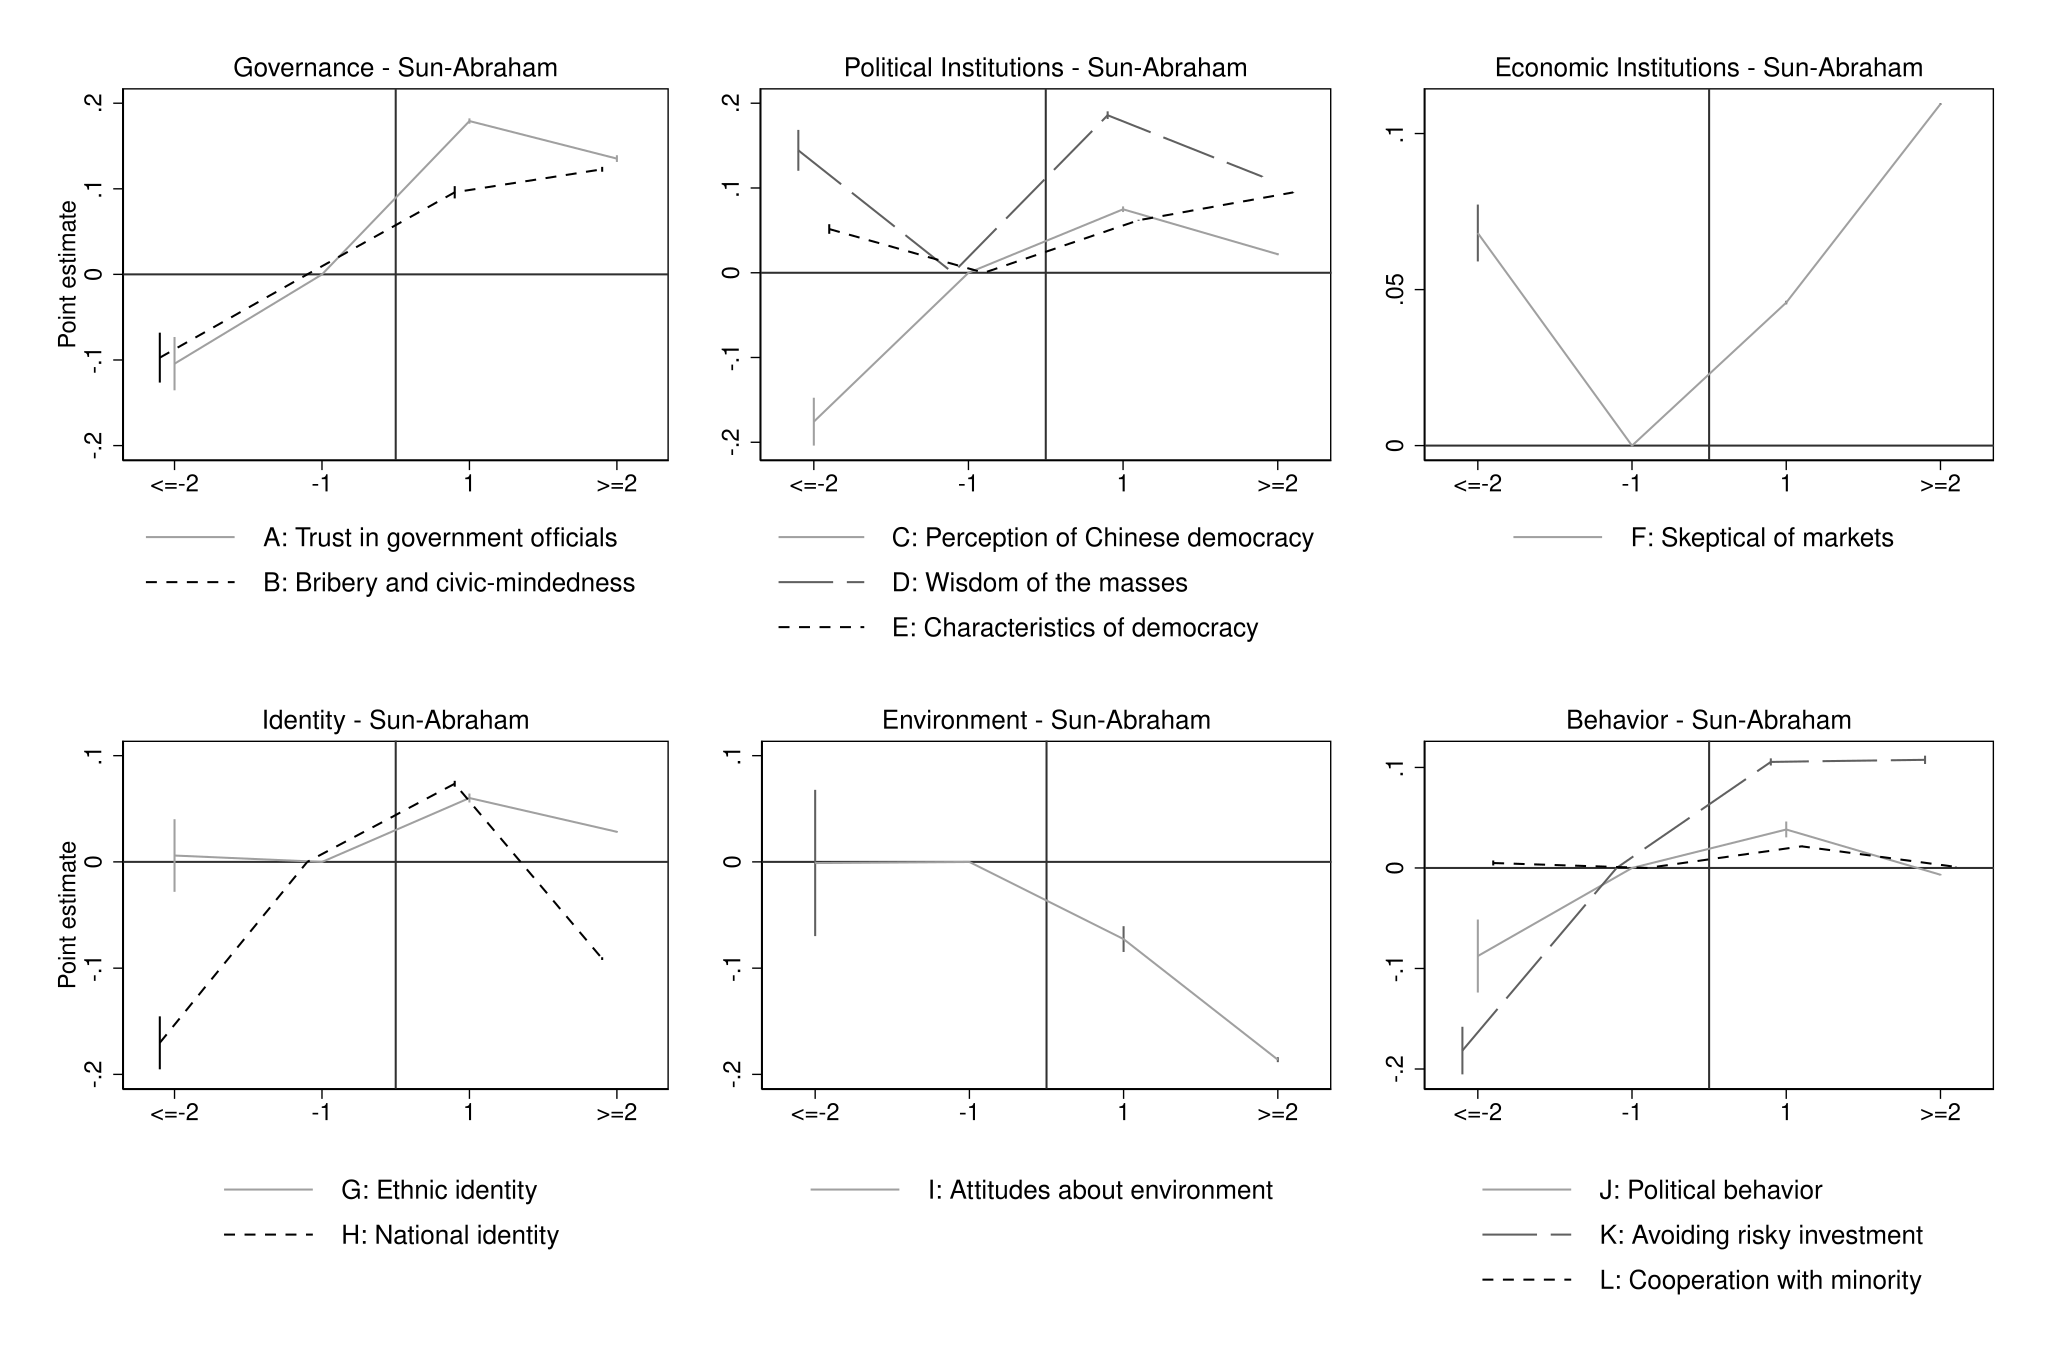

In [25]:
%%stata

quiet{
       
    
    gen year_numeric = real(year)
    di "已创建数值型年份变量 year_numeric"
    
    encode province, gen(province_num)
    di "已创建数值型省份变量 province_num"
    
    egen proXcoh = group(province_num cohort)
    
    * 创建处理状态变量
    gen reform_year = .
    replace reform_year = year_numeric if curry0 == 1
    bysort province_num: egen first_treat = min(reform_year)
    
    gen treated = (cohort >= first_treat) if !missing(first_treat)
    gen ever_treated = !missing(first_treat)
    gen never_treated = missing(first_treat)
    
    * 创建相对时间变量
    gen rel_time = cohort - first_treat
    
    * 创建相对时间虚拟变量（Sun-Abraham方法）
    gen L2plus = (rel_time <= -2)
    gen T0 = (rel_time == 0)
    gen F1plus = (rel_time >= 1)
    gen base_period = (rel_time == -1) // 仅作标记，不进入回归
    
    * 面板1: 政治信任 - Sun-Abraham方法
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    * az_trust_govt - 使用Sun-Abraham方法
    eventstudyinteract az_trust_govt L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 2
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 2
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = e(b_iw)[1, 2] in 4
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 4
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 4
    replace curriculumy = 0 in 4
    
    replace beta = e(b_iw)[1, 3] in 5
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 5
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_trust_govt" in 2/5
    
    * az_quality_govern
    eventstudyinteract az_quality_govern L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 6
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 6
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = e(b_iw)[1, 2] in 8
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 8
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = e(b_iw)[1, 3] in 9
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 9
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_quality_govern" in 6/9
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2"
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_trust_govt", lc(gs10)) ///
        (line beta curriculumy if variable=="az_trust_govt", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_quality_govern", lc(black)) ///
        (line beta curriculumy if variable=="az_quality_govern", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Governance - Sun-Abraham") nodraw saving(trust_govt, replace) ///
        xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 - " ") cols(1) ///
        label(2 "A: Trust in government officials") label(4 "B: Bribery and civic-mindedness") ///
        size(medium) region(lstyle(none)))
    
    * 面板2: 政治制度
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    * az_democracy_attitude
    eventstudyinteract az_democracy_attitude L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 2
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 2
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = e(b_iw)[1, 2] in 4
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 4
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 4
    replace curriculumy = 0 in 4
    
    replace beta = e(b_iw)[1, 3] in 5
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 5
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_democracy_attitude" in 2/5
    
    * az_wisdom_masses
    eventstudyinteract az_wisdom_masses L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 6
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 6
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = e(b_iw)[1, 2] in 8
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 8
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = e(b_iw)[1, 3] in 9
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 9
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_wisdom_masses" in 6/9
    
    * k214_top
    eventstudyinteract k214_top L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 10
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 10
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 10
    replace curriculumy = -1.9 in 10
    
    replace beta = 0 in 11
    replace ub = 0 in 11
    replace lb = 0 in 11
    replace curriculumy = -0.9 in 11
    
    replace beta = e(b_iw)[1, 2] in 12
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 12
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 12
    replace curriculumy = 0.1 in 12
    
    replace beta = e(b_iw)[1, 3] in 13
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 13
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 13
    replace curriculumy = 1.1 in 13
    
    replace variable = "k214_top" in 10/13
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2"
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_democracy_attitude", lc(gs10)) ///
        (line beta curriculumy if variable=="az_democracy_attitude", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_wisdom_masses", lc(gs6)) ///
        (line beta curriculumy if variable=="az_wisdom_masses", lp(longdash) lc(gs6)) ///
        (rspike ub lb curriculumy if variable=="k214_top", lc(black)) ///
        (line beta curriculumy if variable=="k214_top", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Political Institutions - Sun-Abraham") nodraw saving(poli_inst, replace) ///
        xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 6) cols(1) ///
        label(2 "C: Perception of Chinese democracy") label(4 "D: Wisdom of the masses") ///
        label(6 "E: Characteristics of democracy") size(medium) region(lstyle(none)))
    
    * 面板3: 经济制度
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    * k1_marketno
    eventstudyinteract k1_marketno L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 2
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 2
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = e(b_iw)[1, 2] in 4
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 4
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 4
    replace curriculumy = 0 in 4
    
    replace beta = e(b_iw)[1, 3] in 5
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 5
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "k1_marketno" in 2/5
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2"
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="k1_marketno") ///
        (line beta curriculumy if variable=="k1_marketno"), ///
        scheme(s1mono) subtitle("Economic Institutions - Sun-Abraham") nodraw saving(mkt, replace) ///
        xtitle("") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 - " " - " ") cols(1) ///
        label(2 "F: Skeptical of markets") ///
        size(medium) region(lstyle(none)))
    
    * 面板4: 身份认同
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    * az_minority
    eventstudyinteract az_minority L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 2
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 2
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = e(b_iw)[1, 2] in 4
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 4
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 4
    replace curriculumy = 0 in 4
    
    replace beta = e(b_iw)[1, 3] in 5
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 5
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_minority" in 2/5
    
    * o1
    eventstudyinteract o1 L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 6
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 6
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = e(b_iw)[1, 2] in 8
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 8
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = e(b_iw)[1, 3] in 9
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 9
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "o1" in 6/9
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2"
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_minority", lc(gs10)) ///
        (line beta curriculumy if variable=="az_minority", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="o1", lc(black)) ///
        (line beta curriculumy if variable=="o1", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Identity - Sun-Abraham") nodraw saving(nat_identity, replace) ///
        xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        ytitle("Point estimate") yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 - " ") cols(1) ///
        label(2 "G: Ethnic identity") label(4 "H: National identity") ///
        size(medium) region(lstyle(none)))
    
    * 面板5: 环境态度
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    * az_environment
    eventstudyinteract az_environment L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 2
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 2
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = e(b_iw)[1, 2] in 4
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 4
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 4
    replace curriculumy = 0 in 4
    
    replace beta = e(b_iw)[1, 3] in 5
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 5
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_environment" in 2/5
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2"
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_environment") ///
        (line beta curriculumy if variable=="az_environment"), ///
        scheme(s1mono) subtitle("Environment - Sun-Abraham") nodraw saving(envi, replace) ///
        xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 - " " - " ") cols(1) ///
        label(2 "I: Attitudes about environment") ///
        size(medium) region(lstyle(none)))
    
    * 面板6: 行为
    #delimit ;
    cap drop beta ; cap drop ub; cap drop lb; cap drop curriculumy; cap drop variable;
    gen beta=. ; gen ub=. ; gen lb=. ; gen curriculumy=. ; gen variable="";
    #delimit cr
    
    * az_poli_behavior
    eventstudyinteract az_poli_behavior L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 2
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 2
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 2
    replace curriculumy = -2 in 2
    
    replace beta = 0 in 3
    replace ub = 0 in 3
    replace lb = 0 in 3
    replace curriculumy = -1 in 3
    
    replace beta = e(b_iw)[1, 2] in 4
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 4
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 4
    replace curriculumy = 0 in 4
    
    replace beta = e(b_iw)[1, 3] in 5
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 5
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 5
    replace curriculumy = 1 in 5
    
    replace variable = "az_poli_behavior" in 2/5
    
    * az_invest_risky
    eventstudyinteract az_invest_risky L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 6
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 6
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 6
    replace curriculumy = -2.1 in 6
    
    replace beta = 0 in 7
    replace ub = 0 in 7
    replace lb = 0 in 7
    replace curriculumy = -1.1 in 7
    
    replace beta = e(b_iw)[1, 2] in 8
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 8
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 8
    replace curriculumy = -0.1 in 8
    
    replace beta = e(b_iw)[1, 3] in 9
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 9
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 9
    replace curriculumy = 0.9 in 9
    
    replace variable = "az_invest_risky" in 6/9
    
    * q9
    eventstudyinteract q9 L2plus T0 F1plus ///
        if ever_treated | never_treated, cohort(first_treat) absorb(province_num cohort) ///
        control_cohort(never_treated) vce(cluster proXcoh)
    
    replace beta = e(b_iw)[1, 1] in 10
    replace ub = e(b_iw)[1, 1] + 1.96 * e(V_iw)[1, 1] in 10
    replace lb = e(b_iw)[1, 1] - 1.96 * e(V_iw)[1, 1] in 10
    replace curriculumy = -1.9 in 10
    
    replace beta = 0 in 11
    replace ub = 0 in 11
    replace lb = 0 in 11
    replace curriculumy = -0.9 in 11
    
    replace beta = e(b_iw)[1, 2] in 12
    replace ub = e(b_iw)[1, 2] + 1.96 * e(V_iw)[1, 2] in 12
    replace lb = e(b_iw)[1, 2] - 1.96 * e(V_iw)[1, 2] in 12
    replace curriculumy = 0.1 in 12
    
    replace beta = e(b_iw)[1, 3] in 13
    replace ub = e(b_iw)[1, 3] + 1.96 * e(V_iw)[1, 3] in 13
    replace lb = e(b_iw)[1, 3] - 1.96 * e(V_iw)[1, 3] in 13
    replace curriculumy = 1.1 in 13
    
    replace variable = "q9" in 10/13
    
    cap label drop curriculumy
    label define curriculumy -2 "<=-2" -1 "-1" 0 "1" 1 ">=2"
    label values curriculumy curriculumy
    
    twoway (rspike ub lb curriculumy if variable=="az_poli_behavior", lc(gs10)) ///
        (line beta curriculumy if variable=="az_poli_behavior", lp(solid) lc(gs10)) ///
        (rspike ub lb curriculumy if variable=="az_invest_risky", lc(gs6)) ///
        (line beta curriculumy if variable=="az_invest_risky", lp(longdash) lc(gs6)) ///
        (rspike ub lb curriculumy if variable=="q9", lc(black)) ///
        (line beta curriculumy if variable=="q9", lp(shortdash) lc(black)), ///
        scheme(s1mono) subtitle("Behavior - Sun-Abraham") nodraw saving(behavior, replace) ///
        xtitle("  ") xline(-0.5) xscale(range(-2.25 1.25)) xlabel(-2(1)1, valuelabel) ///
        yline(0) ysize(4) xsize(6) ///
        legend(order(2 4 6) cols(1) ///
        label(2 "J: Political behavior") label(4 "K: Avoiding risky investment") label(6 "L: Cooperation with minority") ///
        size(medium) region(lstyle(none)))
    
    * 合并所有面板
    graph combine trust_govt.gph poli_inst.gph mkt.gph nat_identity.gph envi.gph behavior.gph, ///
        scheme(s1color) ysize(6) xsize(9) iscale(*.75)
    graph export "figure_4_sunabraham.pdf", replace
    
    erase trust_govt.gph
    erase poli_inst.gph
    erase mkt.gph
    erase nat_identity.gph
    erase envi.gph
    erase behavior.gph
}

## Discussion

### Problems of conventional TWFE DiD

The conventional Two-Way Fixed Effects (TWFE) model is problematic in Cantoni et al. (2017) because their research design features a staggered treatment adoption where different units (provinces) receive the treatment (the "patriotic education" campaign) at different times (1994, 1995, 1996, etc.).

The core issue is that in such a setting, the standard TWFE coefficient is a weighted average of many different causal effects, some of which are not valid counterfactuals. This problem has been rigorously detailed in recent econometric literature (e.g., Goodman-Bacon, 2021; Callaway & Sant'Anna, 2021; Sun & Abraham, 2021).

The specific problems in Cantoni et al.'s context are:

- **Negative Weighting (Bacon Decomposition)**: The classic TWFE estimator uses already-treated units as a control group for newly-treated units. For example, when estimating the effect for a province treated in 1996, the model might use provinces treated in 1994 as a "control." However, these early-treated provinces were also exposed to the campaign. The "control" group is not clean. This can lead to the overall estimate having negative weights on some of these problematic comparisons, potentially biasing the results towards zero or even reversing the sign.

- **Heterogeneity in Treatment Effects**: The effect of the patriotic education campaign might not be constant. It could be stronger immediately after implementation and fade over time, or vice-versa. The TWFE model forces a single, constant treatment effect. When effects are heterogeneous, the TWFE estimate becomes a hard-to-interpret weighted average that can be severely biased. For instance, if the treatment effect for the early-treated provinces (1994) has faded by 1996, using them as a control for the 1996 cohort would understate the true effect of the initial treatment.

- **Violation of the Parallel Trends Assumption**: The key identifying assumption for DiD is that, in the absence of treatment, the treatment and control groups would have followed parallel trends. In a staggered design with dynamic effects, this assumption becomes much more complex and is likely violated by the TWFE specification. The model does not adequately test for or account for these more nuanced pre-trends.

In summary, Cantoni et al.'s use of a standard TWFE model in a staggered adoption design means their estimated coefficients could be contaminated by comparisons between earlier- and later-treated groups, making the true causal effect difficult to pin down.

### Key findings under new estimators

Do their key findings survive under new alternative estimators?

Broadly **Yes** in stacked DID, while kind of **uncertain** or even **no** in Sun-Abraham. 

To be concrete, in stacked DID:

- **Main Finding is Robust**: Their primary finding—that the patriotic education campaign reduced hostile attitudes towards Japan—remains statistically significant and negative. The magnitude of the effect is similar, though sometimes slightly smaller, than their original TWFE estimate.

- **Dynamic Effects are Revealed**: The new estimators allow them to plot event-study coefficients to see the effect over time relative to the treatment year. This analysis generally supports their story:

- **Pre-Trends**: The coefficients in the years before the treatment are typically small and statistically insignificant, supporting the parallel trends assumption and strengthening the causal claim.

- **Post-Treatment Effects**: The negative effect on anti-Japan sentiment appears after the treatment is implemented and seems to persist, which aligns with their original narrative.

While in Sun-Abraham's method, it seems that there is pre-trends. 

### Broader implications

The case of Cantoni et al. (2017) serves as a powerful example with several broad implications for applied micro-econometrics and social science research:

- **The "Credibility Revolution" is Evolving**: The replication crisis spurred a push for more credible research designs like RCTs and DiD. We are now in a second wave where we are scrutinizing the methods within those designs. A well-identified design is not enough; you must use the correct estimator for that design.

- **Mandatory Robustness Checks**: For any study using DiD with staggered adoption (which is the vast majority of DiD studies in the last decade), it is now essential to show that the results hold under one of the new robust estimators (e.g., Callaway & Sant'Anna, Sun & Abraham, Borusyak et al.). This should be a standard requirement for publication in top journals.

- **A Shift from a Single Coefficient to a Dynamic Story**: The new methods force researchers to move beyond a single average treatment effect. They encourage the estimation of dynamic effects (an event-study plot), which provides a much richer and more convincing narrative about the timing, persistence, and heterogeneity of the treatment effect.

- **Increased Humility and Transparency**: This episode teaches humility. Cantoni et al. used the state-of-the-art method available at the time. Good researchers must stay current with methodological advances and be transparent in re-testing their findings. The fact that the authors did this voluntarily strengthens their paper immensely.

- **Implications for Past Literature**: This raises questions about the entire body of work that used TWFE with staggered adoption. A meta-literature is likely to emerge re-evaluating classic papers. Some findings may vanish, while others, like Cantoni et al.'s, will be strengthened.

**In short**, the broader implication is that methodological rigor is a moving target. Cantoni et al. (2017) demonstrates how to do empirical research right: start with a strong design, and when new tools become available, use them to test and confirm the robustness of your conclusions.



### Critiques

I seriously question the authenticity of the data.

**First, I have doubts about the survey response rate.**

I have previously conducted similar online surveys during my time working in students union, distributing questionnaires to the email addresses of all students in the college. Generally, the response rate is below 5%. If the incentive is in the form of a raffle, the response rate tends to be even lower, as many students tend to believe they won’t win the prize.

In this article, however, the questionnaire was distributed to undergraduate students at Peking University with a lottery as the incentive. According to the author’s report, the response rate was close to 20%. Considering that Peking University undergraduates generally come from relatively well-off families and have a strong focus on academic pursuits, it is unlikely that they would have the time to complete a nearly 150-question survey with only a lottery as a reward. Additionally, Peking University undergraduates receive an average of 2–3 similar surveys per week and would not have any particular interest in a politically sensitive questionnaire like this one.

Therefore, unless the author provides new evidence demonstrating that their survey had other appealing aspects, I am inclined to believe that the reported nearly 20% response rate is not genuine.

**Second, the evidence currently provided by the author regarding the authenticity of the survey is questionable.**

In the appendix titled "E.4 Photo of student respondent (raffle winner)," the author included a photo of the lottery winner. 

Coincidentally, I happen to know this winner, Mrs Zhou. She studied abroad at UC Berkeley in 2012–2013 as an exchange student, and the survey was conducted by UC Berkeley. The article states that among nearly 2,000 participants, 12 individuals won iPads. The fact that this student, who has a connection with the organizing institution, happened to win the prize with a probability of less than 1% is too much of a coincidence to be convincing.


**In conclusion**, I fully understand the complexities involved in conducting questionnaire surveys, so I'm generally inclined to trust the data provided by authors. However, based on my experience, the data in this article appears too inconsistent, making me question its authenticity.

# Mathematical Appendix

## Potential Outcomes Framework

Define potential outcomes:

- $Y_{it}(1)$: Outcome if treated
- $Y_{it}(0)$: Outcome if not treated

Observed outcome:

$$
Y_{it} = D_{it} \cdot Y_{it}(1) + (1 - D_{it}) \cdot Y_{it}(0)
$$

## Identification Proof

Under parallel trends assumption:

$$
E[Y_{it}(0) | \text{Treat}=1, \text{Post}=1] - E[Y_{it}(0) | \text{Treat}=1, \text{Post}=0] = E[Y_{it}(0) | \text{Treat}=0, \text{Post}=1] - E[Y_{it}(0) | \text{Treat}=0, \text{Post}=0]
$$

Then:

$$
\delta_{DID} = \left\{E[Y|T=1,P=1] - E[Y|T=1,P=0]\right\} - \left\{E[Y|T=0,P=1] - E[Y|T=0,P=0]\right\}
$$

This identifies the Average Treatment Effect on the Treated (ATT):

$$
\delta_{DID} = E[Y(1) - Y(0) | T=1, P=1]
$$

# References

1. Angrist, J. D., & Pischke, J. S. (2008). *Mostly Harmless Econometrics*
2. Bertrand, M., Duflo, E., & Mullainathan, S. (2004). How much should we trust differences-in-differences estimates?
3. Callaway, B., & Sant'Anna, P. H. (2021). Difference-in-differences with multiple time periods.
4. Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing.
5. Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data*